In [8]:
# Cell 1: 导入库
# ------------- 标准库 -------------
from pathlib import Path
# ------------- 数据分析核心库 -------------
import pandas as pd
import numpy as np
# ------------- 科学计算/统计分析库 -------------
from scipy.optimize import minimize
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
# ------------- 可视化库 -------------
import matplotlib.pyplot as plt
from pathlib import Path
# ------------- Parquet和Feather相关库 -------------
from pathlib import Path
# ------------- 程序设定 -------------
from Config import Config
try:
    import src.factor_utils as fu
except Exception as _factor_utils_import_error:
    fu = None
    print(f"src.factor_utils import skipped; notebook-local helpers will be used: {_factor_utils_import_error}")


In [9]:
data_df = pd.read_parquet("data_processed/data_df.parquet")
market_df = pd.read_parquet("data_processed/market_df.parquet")

# 因子生成与挂载

## 数据文件清洗

In [10]:
# 清洗宏观数据的函数
def clean_macro_table(df: pd.DataFrame, nation: str = "美国", indi: str = "PMI") -> pd.DataFrame:
    
    # 复制，避免改原表
    out = df.copy()

    # 1) 先筛选国家/地区
    out = out[out["国家/地区"] == nation]

    # 2) 再筛选指标名称包含 indi 的行
    out = out[out["指标名称"].astype(str).str.contains(indi, na=False)]

    keep_cols = [
        out.columns[2],   # 第3列
        out.columns[3],   # 第4列
        out.columns[4],   # 第5列
        out.columns[5],   # 第6列
        out.columns[7],   # 第8列
        out.columns[8],   # 第9列
        out.columns[9],   # 第10列
        out.columns[-1],  # 最后一列
    ]
    out = out[keep_cols].copy()

    # 4) 重命名列
    out.columns = [
        "date",      # 原第3列：日期
        "time",          # 原第4列：时间
        "nation",        # 原第5列：国家/地区
        "indicator",     # 原第6列：指标
        "prev",          # 原第8列：前值
        "forecast",      # 原第9列：预测值
        "actual",        # 原第10列：今值
        "file_ym",       # 原最后1列：文件年月
    ]

    # 7) 重置索引
    out = out.set_index("date").sort_index(ascending=True)

    # 按同一事件去重：同一天、同一时间、同一国家、同一指标，只保留最新 file_ym
    out = out.drop_duplicates(
        subset=[ "time", "nation", "indicator","prev","forecast","actual"],
        keep="last"
    )

    return out

In [11]:
# ZHAO todo factor helpers
# Non-Macro_all monthly signals are placed on the last available data_df date of each source month.
# Macro_all factors keep the original row dates from Macro_all.xlsx.

def _find_data_file(file_name):
    file_name = str(file_name)
    direct = Config.DATA_DIR / file_name
    if direct.exists():
        return direct
    candidates = sorted(Config.DATA_DIR.rglob(file_name))
    if not candidates and not file_name.lower().endswith((".xlsx", ".xls")):
        candidates = sorted(Config.DATA_DIR.rglob(file_name + ".xlsx"))
    if not candidates:
        raise FileNotFoundError(f"Cannot find data file under {Config.DATA_DIR}: {file_name}")
    if len(candidates) > 1:
        print(f"Multiple files matched {file_name}, using: {candidates[0]}")
    return candidates[0]


def _as_numeric(series, percent_hint=False):
    text = series.astype(str).str.strip()
    has_percent_sign = text.str.contains("%", regex=False, na=False).any()
    numeric = pd.to_numeric(
        text.str.replace("%", "", regex=False).str.replace(",", "", regex=False),
        errors="coerce",
    )
    if percent_hint or has_percent_sign:
        numeric = numeric / 100
    return numeric


def _read_indicator_series(file_name, value_col, sheet_name=0):
    path = _find_data_file(file_name)
    raw = pd.read_excel(path, sheet_name=sheet_name)
    date_col = raw.columns[0]
    unit_mask = raw[date_col].astype(str).str.strip().eq('单位')
    percent_hint = False
    if value_col in raw.columns and unit_mask.any():
        percent_hint = raw.loc[unit_mask, value_col].astype(str).str.contains("%", regex=False, na=False).any()
    out = raw.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out[out[date_col].notna()].copy()
    out = out.set_index(date_col).sort_index(ascending=True)
    if value_col not in out.columns:
        raise KeyError(f"{value_col} not found in {path}. Available columns: {list(out.columns)}")
    s = _as_numeric(out[value_col], percent_hint=percent_hint)
    s.name = value_col
    return s[~s.index.duplicated(keep="last")].sort_index()


def _month_aggregate(series, how="average"):
    s = series.dropna().copy().sort_index()
    grouped = s.groupby(s.index.to_period("M"))

    if how in ["average", "mean"]:
        out = grouped.mean()
    elif how == "last":
        out = grouped.last()
    elif how == "sum":
        out = grouped.sum()

    # 关键：把 index 从“月份”改成该月在原始数据里的最后一个日期
    last_dates = grouped.apply(lambda x: x.index[-1])
    out.index = last_dates.values

    return out

def _rolling_quantile_rank_year(series, year=5):
    s = series.dropna().sort_index()
    dates = s.index

    out = []
    left = 0
    first_date = dates[0]

    for right in range(len(s)):
        end_date = dates[right]
        start_date = end_date - pd.DateOffset(years=year)

        # 原始数据整体不够5年，才返回 NaN
        if first_date > start_date:
            out.append(np.nan)
            continue

        while left < right and dates[left] < start_date:
            left += 1

        window = s.iloc[left:right + 1]

        pct = window.rank(pct=True).iloc[-1]
        out.append(pct)

    return pd.Series(out, index=s.index)


def _load_macro_all():
    return pd.read_excel(_find_data_file("Macro_all.xlsx"), sheet_name=0)


def _load_china_macro_series(keyword, value_col='今值', required_contains=None, exclude_contains=None):
    macro = _load_macro_all()
    date_col = '日期' if '日期' in macro.columns else macro.columns[2]
    nation_col = '国家/地区' if '国家/地区' in macro.columns else macro.columns[4]
    indicator_col = '指标名称' if '指标名称' in macro.columns else macro.columns[5]
    mask = macro[nation_col].eq('中国')
    mask &= macro[indicator_col].astype(str).str.contains(keyword, na=False, regex=False)
    if required_contains is not None:
        required_list = [required_contains] if isinstance(required_contains, str) else list(required_contains)
        for item in required_list:
            mask &= macro[indicator_col].astype(str).str.contains(item, na=False, regex=False)
    if exclude_contains is not None:
        exclude_list = [exclude_contains] if isinstance(exclude_contains, str) else list(exclude_contains)
        for item in exclude_list:
            mask &= ~macro[indicator_col].astype(str).str.contains(item, na=False, regex=False)
    out = macro.loc[mask].copy()
    if out.empty:
        raise ValueError(f"No China macro rows matched keyword={keyword!r}")
    percent_hint = (
        out[indicator_col].astype(str).str.contains("%", regex=False, na=False).any()
        or out[value_col].astype(str).str.contains("%", regex=False, na=False).any()
    )
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out[out[date_col].notna()].copy()
    sort_cols = [x for x in [date_col, '来源文件', '来源sheet', '文件年月'] if x in out.columns]
    out = out.sort_values(sort_cols, na_position="first")
    s = pd.Series(_as_numeric(out[value_col], percent_hint=percent_hint).to_numpy(), index=out[date_col], name=keyword).sort_index()
    dup_count = int(s.index.duplicated(keep=False).sum())
    if dup_count > 0:
        print(f"Macro keyword {keyword!r} matched {dup_count} duplicate-date rows; keeping the last row per date.")
        s = s[~s.index.duplicated(keep="last")]
    return s.sort_index()


def _assign_raw_factor(raw_col, series):
    s = series.copy().sort_index()
    s.index = pd.to_datetime(s.index)
    s = s[~s.index.duplicated(keep="last")]
    data_df[raw_col] = s.reindex(data_df.index)
    print(f"{raw_col} generated:", "non_na=", int(data_df[raw_col].notna().sum()), "first=", data_df[raw_col].first_valid_index(), "last=", data_df[raw_col].last_valid_index())
    s = s.dropna()
    return data_df[raw_col]


def _rolling_sum_ratio_minus_one(series, window=12, shift=11):
    rolling_sum = series.dropna().sort_index().rolling(window=window, min_periods=window).sum().dropna()
    division = rolling_sum / rolling_sum.shift(shift) - 1
    return division.dropna()


def _YoY(monthly_series):
    s = monthly_series.dropna().sort_index()
    return (s/ s.shift(1) - 1)


def data_diff(series):
    s = series.copy().sort_index()
    return s - s.shift(1)


def _trailing_time_window(series, end_date, months=None, years=None, days=None):
    start_date = pd.Timestamp(end_date)
    if years is not None:
        start_date = start_date - pd.DateOffset(years=years)
    if months is not None:
        start_date = start_date - pd.DateOffset(months=months)
    if days is not None:
        start_date = start_date - pd.Timedelta(days=days)
    return series.loc[(series.index >= start_date) & (series.index <= end_date)]


def _time_window_apply(series, func, months=None, years=None, days=None, min_periods=1):
    s = series.dropna().sort_index()
    out = []
    for dt in s.index:
        window = _trailing_time_window(s, dt, months=months, years=years, days=days)
        if len(window) < min_periods:
            out.append(np.nan)
        else:
            out.append(func(window))
    return pd.Series(out, index=s.index, dtype="float64")


def rolling_quantile_value(series, target_quantile, months=None, years=None, days=None, min_periods=1):
    return _time_window_apply(
        series,
        lambda window: window.quantile(target_quantile),
        months=months,
        years=years,
        days=days,
        min_periods=min_periods,
    )


def calc_rolling_zscore_time(series, months=None, years=None, days=None, min_periods=1):
    s = series.dropna().sort_index()
    out = []
    for dt in s.index:
        window = _trailing_time_window(s, dt, months=months, years=years, days=days)
        if len(window) < min_periods:
            out.append(np.nan)
            continue
        rolling_mean = window.mean()
        rolling_std = window.std()
        current_value = s.loc[dt]
        if pd.isna(current_value) or pd.isna(rolling_std) or np.isclose(rolling_std, 0):
            out.append(np.nan)
        else:
            out.append((current_value - rolling_mean) / rolling_std)
    return pd.Series(out, index=s.index, dtype="float64")


def data_deviation(series, months=None, years=None, days=None, min_periods=1):
    s = series.copy().sort_index()
    rolling_mean = _time_window_apply(
        s,
        lambda window: window.mean(),
        months=months,
        years=years,
        days=days,
        min_periods=min_periods,
    )
    return s - rolling_mean.reindex(s.index)


def z_data_deviation(
    series,
    dev_months=None,
    dev_years=None,
    dev_days=None,
    z_months=None,
    z_years=None,
    z_days=None,
    dev_min_periods=1,
    z_min_periods=1,
):
    deviation = data_deviation(
        series,
        months=dev_months,
        years=dev_years,
        days=dev_days,
        min_periods=dev_min_periods,
    )
    return calc_rolling_zscore_time(
        deviation,
        months=z_months,
        years=z_years,
        days=z_days,
        min_periods=z_min_periods,
    )


def expectation(
    sub_1,
    sub_2,
    *,
    z_years=3,
    z_min_periods=18,
    up_floor=None,
    down_ceiling=None,
    upper_quantile=None,
    lower_quantile=None,
    quantile_years=3,
    quantile_min_periods=18,
):
    aligned = pd.concat([sub_1.rename("sub_1"), sub_2.rename("sub_2")], axis=1).sort_index()
    aligned = aligned.dropna(subset=["sub_1", "sub_2"])
    surprise = aligned["sub_1"] - aligned["sub_2"]

    if upper_quantile is not None:
        upper_bound = rolling_quantile_value(
            aligned["sub_1"],
            upper_quantile,
            years=quantile_years,
            min_periods=quantile_min_periods,
        )
    else:
        upper_bound = pd.Series(up_floor, index=aligned.index, dtype="float64")

    if lower_quantile is not None:
        lower_bound = rolling_quantile_value(
            aligned["sub_1"],
            lower_quantile,
            years=quantile_years,
            min_periods=quantile_min_periods,
        )
    else:
        lower_bound = pd.Series(down_ceiling, index=aligned.index, dtype="float64")

    signal = pd.Series(np.nan, index=aligned.index, dtype="float64")
    positive_mask = (aligned["sub_1"] > aligned["sub_2"]) & (aligned["sub_1"] > upper_bound)
    negative_mask = (aligned["sub_1"] < aligned["sub_2"]) & (aligned["sub_1"] < lower_bound)
    keep_mask = positive_mask | negative_mask
    signal.loc[keep_mask] = surprise.loc[keep_mask]

    return calc_rolling_zscore_time(signal, years=z_years, min_periods=z_min_periods)

#计算z-score
def calc_rolling_zscore(series, window, min_periods=None):
    """
    滚动窗口 zscore。    z_t = (x_t - rolling_mean_t) / rolling_std_t
    """
    if min_periods is None:
        min_periods = window // 2

    rolling_mean = series.rolling(window=window, min_periods=min_periods).mean()
    rolling_std = series.rolling(window=window, min_periods=min_periods).std()

    zscore = (series - rolling_mean) / rolling_std
    return zscore


def llt(series, d=30):
    if fu is not None and hasattr(fu, "calc_llt"):
        try:
            return fu.calc_llt(series, d=d)
        except Exception:
            pass

    s = series.astype(float).copy()
    llt_series = pd.Series(index=s.index, dtype="float64")
    alpha = 2 / (d + 1)
    started = False

    for i in range(2, len(s)):
        x_t = s.iloc[i]
        x_t1 = s.iloc[i - 1]
        x_t2 = s.iloc[i - 2]

        if pd.isna(x_t) or pd.isna(x_t1) or pd.isna(x_t2):
            llt_series.iloc[i] = np.nan
            continue

        if not started:
            llt_series.iloc[i - 1] = x_t1
            llt_series.iloc[i] = x_t
            started = True
            continue

        llt_t1 = llt_series.iloc[i - 1]
        llt_t2 = llt_series.iloc[i - 2]

        if pd.isna(llt_t1) or pd.isna(llt_t2):
            llt_series.iloc[i - 1] = x_t1
            llt_series.iloc[i] = x_t
            continue

        llt_series.iloc[i] = (
            (alpha - alpha ** 2 / 4) * x_t
            + (alpha ** 2 / 2) * x_t1
            - (alpha - 3 * alpha ** 2 / 4) * x_t2
            + 2 * (1 - alpha) * llt_t1
            - (1 - alpha) ** 2 * llt_t2
        )

    return llt_series

def merge_factor_to_market(data_df, market_df, raw_factor_col, factor_type="state", track_col="track_id"):
    if raw_factor_col not in data_df.columns:
        raise KeyError(f"{raw_factor_col} is not in data_df.columns")
    if not raw_factor_col.endswith("_raw"):
        raise ValueError(f"{raw_factor_col} must end with _raw")
    factor_col = raw_factor_col[:-4]
    factor_type = str(factor_type).lower()
    if factor_type not in ["state", "event"]:
        raise ValueError(f"factor_type must be 'state' or 'event', got {factor_type!r}")
    if factor_type == "state":
        data_df[factor_col] = data_df[raw_factor_col].shift(1)
        market_df[factor_col] = data_df[factor_col].reindex(market_df.index)
    else:
        if track_col not in market_df.columns:
            raise KeyError(f"event factors require {track_col} in market_df")
        market_df[factor_col] = np.nan
        raw_events = data_df.loc[data_df[raw_factor_col].notna(), raw_factor_col].sort_index()
        track_values = sorted(pd.Series(market_df[track_col]).dropna().unique())
        track_dates = {track_id: pd.DatetimeIndex(market_df.index[market_df[track_col] == track_id]).sort_values() for track_id in track_values}
        for event_date, raw_value in raw_events.items():
            event_date = pd.Timestamp(event_date)
            for track_id, candidate_dates in track_dates.items():
                future_dates = candidate_dates[candidate_dates > event_date]
                if len(future_dates) > 0:
                    market_df.loc[future_dates[0], factor_col] = raw_value
        data_df[factor_col] = market_df[factor_col].reindex(data_df.index)
    if factor_col not in Config.FEATURE_LIST:
        Config.FEATURE_LIST.append(factor_col)
    return market_df


In [12]:
# L23-L46 helper additions
def data_yoy(series):
    s = series.copy().sort_index()
    return s / s.shift(1) - 1


def _time_mean(series, *, months=None, years=None, days=None, min_periods=1):
    return _time_window_apply(
        series,
        lambda window: window.mean(),
        months=months,
        years=years,
        days=days,
        min_periods=min_periods,
    )


def z_MA_div(
    series,
    short_window,
    long_window,
    z_window,
    *,
    unit="months",
    short_min_periods=None,
    long_min_periods=None,
    z_min_periods=None,
):
    if unit == "days":
        short_min_periods = 1 if short_window == 1 else short_min_periods or max(2, int(round(short_window / 30 / 2)))
        long_min_periods = long_min_periods or max(6, int(round(long_window / 30 / 2)))
        z_min_periods = z_min_periods or max(12, int(round(z_window / 30 / 2)))

        short_ma = (
            series.copy()
            if short_window == 1
            else _time_mean(series, days=short_window, min_periods=short_min_periods)
        )
        long_ma = _time_mean(series, days=long_window, min_periods=long_min_periods)
        return calc_rolling_zscore_time(
            short_ma - long_ma,
            days=z_window,
            min_periods=z_min_periods,
        )

    short_min_periods = 1 if short_window == 1 else short_min_periods or max(2, short_window // 2)
    long_min_periods = long_min_periods or max(3, long_window // 2)
    z_min_periods = z_min_periods or max(6, z_window // 2)

    short_ma = (
        series.copy()
        if short_window == 1
        else _time_mean(series, months=short_window, min_periods=short_min_periods)
    )
    long_ma = _time_mean(series, months=long_window, min_periods=long_min_periods)
    return calc_rolling_zscore_time(
        short_ma - long_ma,
        months=z_window,
        min_periods=z_min_periods,
    )


def _latest_macro_pair(sub_1, sub_2):
    aligned = pd.concat(
        [sub_1.rename("sub_1"), sub_2.rename("sub_2")],
        axis=1,
        sort=True,
    ).sort_index()
    aligned[["sub_1", "sub_2"]] = aligned[["sub_1", "sub_2"]].ffill()
    return aligned

## ZHAO todo factor generation


### index_pb (ZHAO01)

In [42]:
sub_1 = _read_indicator_series('D_PE+PB+DI+PS+PC+调仓_growth_100104_260325.xlsx', '市净率LF').dropna()
sub_2 = _read_indicator_series('D_PE+PB+DI+PS+PC+调仓_value_100104_260325.xlsx', '市净率LF').dropna()
valuation_ratio = sub_1 / sub_2
quantile_rank = _rolling_quantile_rank_year(valuation_ratio,5)
ZHAO01_raw = ((0.1 - quantile_rank).clip(lower=0) - (quantile_rank - 0.9).clip(lower=0).dropna())*10
ZHAO01_raw = _month_aggregate(ZHAO01_raw, how="last")
_assign_raw_factor("ZHAO01_raw", ZHAO01_raw)

ZHAO01_raw generated: non_na= 134 first= 2015-01-30 00:00:00 last= 2026-02-27 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: ZHAO01_raw, Length: 5635, dtype: float64

In [43]:
ZHAO01_raw.dropna().head()

2015-01-30    0.000000
2015-02-27    0.000000
2015-03-31    0.000000
2015-04-30    0.000000
2015-05-29   -0.975248
dtype: float64

### index_pe (ZHAO02)


In [ ]:
sub_1 = _read_indicator_series('D_PE+PB+DI+PS+PC+调仓_growth_100104_260325.xlsx', '市盈率TTM').dropna()
sub_2 = _read_indicator_series('D_PE+PB+DI+PS+PC+调仓_value_100104_260325.xlsx', '市盈率TTM').dropna()
valuation_ratio = sub_1 / sub_2
quantile_rank = _rolling_quantile_rank_year(valuation_ratio,5)
ZHAO02_raw = (0.1 - quantile_rank).clip(lower=0) - (quantile_rank - 0.9).clip(lower=0).dropna()*10
ZHAO02_raw = _month_aggregate(ZHAO02_raw, how="last")
_assign_raw_factor("ZHAO02_raw", ZHAO02_raw)

ZHAO02_raw generated: non_na= 134 first= 2015-01-30 00:00:00 last= 2026-02-27 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: ZHAO02_raw, Length: 5635, dtype: float64

In [44]:
ZHAO0102_raw = ZHAO01_raw + ZHAO02_raw
_assign_raw_factor("ZHAO_0102_raw", ZHAO0102_raw)

ZHAO_0102_raw generated: non_na= 134 first= 2015-01-30 00:00:00 last= 2026-02-27 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: ZHAO_0102_raw, Length: 5635, dtype: float64

### PB_QRD (ZHAO03)

In [15]:
# 读取 parquet
df_component = pd.read_parquet(r"data_private\index_data\IndexComponents.parquet")
df_pb = pd.read_parquet(r"data_public\比价\pb.parquet")

In [16]:
# ---- component 表列名 ----
target = "399370.SZ"
comp_date = "TRADE_DT"
comp_code = "S_CON_WINDCODE"
comp_weight = "I_WEIGHT"

# ---- df_pb 表列名 ----
pb_date = "TRADE_DT"

In [17]:
def normalize_trade_dt(series):
    text = series.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
    is_yyyymmdd = text.str.fullmatch(r"\d{8}").fillna(False)

    dt = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")
    dt.loc[is_yyyymmdd] = pd.to_datetime(
        text.loc[is_yyyymmdd],
        format="%Y%m%d",
        errors="coerce"
    )
    dt.loc[~is_yyyymmdd] = pd.to_datetime(
        text.loc[~is_yyyymmdd],
        errors="coerce"
    )
    return dt.dt.normalize()


df_component[comp_date] = normalize_trade_dt(df_component[comp_date])

df_pb[pb_date] = normalize_trade_dt(df_pb[pb_date])

df_component[comp_code] = df_component[comp_code].astype(str).str.strip()

In [18]:
# 将 PB 宽表标准化为以 TRADE_DT 为行、股票代码为列的查询表
df_pb_wide = df_pb.copy()

if isinstance(df_pb_wide.index, pd.MultiIndex):
    if pb_date in df_pb_wide.index.names:
        df_pb_wide = df_pb_wide.reset_index()
elif df_pb_wide.index.name == pb_date:
    df_pb_wide = df_pb_wide.reset_index()

if isinstance(df_pb_wide.columns, pd.MultiIndex):
    def _flatten_pb_col(col):
        parts = [
            str(item).strip()
            for item in col
            if pd.notna(item) and str(item).strip() not in ("", "nan")
        ]
        wind_codes = [
            item for item in parts
            if re.match(r"^[0-9A-Z]{6}\.(SH|SZ|BJ)$", item)
        ]
        return wind_codes[0] if wind_codes else (parts[0] if parts else "")

    df_pb_wide.columns = [
        _flatten_pb_col(col) for col in df_pb_wide.columns.to_flat_index()
    ]

pb_date_col = next(
    (col for col in df_pb_wide.columns if str(col).strip().upper() in {pb_date, "DATE"}),
    df_pb_wide.columns[0],
)

df_pb_wide = df_pb_wide.rename(columns={pb_date_col: comp_date})
df_pb_wide[comp_date] = normalize_trade_dt(df_pb_wide[comp_date])

df_pb_wide = (
    df_pb_wide
    .dropna(subset=[comp_date])
    .drop_duplicates(subset=[comp_date], keep="last")
    .set_index(comp_date)
)

df_pb_wide.columns = df_pb_wide.columns.astype(str).str.strip()
df_pb_wide = df_pb_wide.loc[:, ~df_pb_wide.columns.duplicated(keep="last")]

In [19]:
# 1. 复制，避免污染原表
component_monthly = df_component.copy()
pb_trade_dates = df_pb.copy()

# 2. 标准化日期
component_monthly["TRADE_DT"] = pd.to_datetime(component_monthly["TRADE_DT"])
pb_trade_dates["TRADE_DT"] = pd.to_datetime(pb_trade_dates["TRADE_DT"])

# 3. 提取 df_pb 中所有交易日
trade_dates = (
    pb_trade_dates[["TRADE_DT"]]
    .drop_duplicates()
    .sort_values("TRADE_DT")
)

# 4. 提取每个月末截面的成分股数据
# 注意：这里每个 TRADE_DT 下有很多成分股
component_monthly = component_monthly.sort_values("TRADE_DT")

# 5. 为每个交易日匹配“最近一个已经发生的月末成分股日期”
date_map = pd.merge_asof(
    trade_dates,
    component_monthly[["TRADE_DT"]].drop_duplicates().sort_values("TRADE_DT"),
    on="TRADE_DT",
    direction="backward"
).rename(columns={"TRADE_DT": "TRADE_DT"})

# 上面会覆盖名字，不方便区分，建议重新写一个更清晰版本：
month_end_dates = (
    component_monthly[["TRADE_DT"]]
    .drop_duplicates()
    .sort_values("TRADE_DT")
    .rename(columns={"TRADE_DT": "COMPONENT_DT"})
)

date_map = pd.merge_asof(
    trade_dates.sort_values("TRADE_DT"),
    month_end_dates,
    left_on="TRADE_DT",
    right_on="COMPONENT_DT",
    direction="backward"
)

# 6. 用 COMPONENT_DT 回连月末成分股表
df_component_daily = date_map.merge(
    component_monthly,
    left_on="COMPONENT_DT",
    right_on="TRADE_DT",
    how="left",
    suffixes=("", "_component")
)

# 7. 整理日期列
df_component_daily = df_component_daily.drop(columns=["TRADE_DT_component"])
df_component_daily = df_component_daily.rename(columns={"TRADE_DT": "TRADE_DT"})

# 8. 可选：保留原始成分股截面日期，方便检查
# COMPONENT_DT = 这一天使用的是哪一期月末成分股
df_component_daily = df_component_daily.sort_values(
    ["TRADE_DT", "S_INFO_WINDCODE", "S_CON_WINDCODE"]
).reset_index(drop=True)

In [20]:
# 先计算399370的市盈率数据
# df_component = df_component[df_component['S_INFO_WINDCODE'] == target].copy()


#df_component[comp_weight] = pd.to_numeric(df_component[comp_weight], errors="coerce")
#df_component[pe_value] = pd.to_numeric(df_component[pe_value], errors="coerce")

row_pos = df_pb_wide.index.get_indexer(df_component_daily[comp_date])
col_pos = df_pb_wide.columns.get_indexer(df_component_daily[comp_code])

pb_values = np.full(len(df_component_daily), np.nan, dtype=object)
valid_pb = (row_pos >= 0) & (col_pos >= 0)

pb_matrix = df_pb_wide.to_numpy()
pb_values[valid_pb] = pb_matrix[row_pos[valid_pb], col_pos[valid_pb]]

df_component_daily["pb_value"] = pd.to_numeric(
    pd.Series(pb_values, index=df_component_daily.index),
    errors="coerce"
)

In [21]:
df_merged_pb = (
    df_component_daily
    .dropna()
    .reset_index(drop=True)
)

df_merged_pb.head()

,TRADE_DT,COMPONENT_DT,S_INFO_WINDCODE,S_CON_WINDCODE,I_WEIGHT,pb_value
0,2010-01-29,2010-01-29,399370.SZ,000002.SZ,2.81,2.9390
1,2010-01-29,2010-01-29,399370.SZ,000014.SZ,0.07,5.7886
2,2010-01-29,2010-01-29,399370.SZ,000031.SZ,0.32,5.3049
3,2010-01-29,2010-01-29,399370.SZ,000069.SZ,0.74,3.5852
4,2010-01-29,2010-01-29,399370.SZ,000070.SZ,0.04,3.7300


In [22]:
# =========================================================
# 计算两个风格指数每日成分股 PB 的 QRD
# QRD = (q75 - q25) / (q90 - q10)
# 然后计算 QRD 的 20 日滚动均值
# =========================================================

target_index_list = ["399370.SZ"]
df_merged_pb = df_merged_pb[df_merged_pb["S_INFO_WINDCODE"].isin(target_index_list)].copy()

# 2. 定义单日 QRD 计算函数
def calc_qrd(x: pd.Series) -> float:
    x = x.dropna()

    # 样本太少时不计算，阈值可以自己改
    if len(x) < 10:
        return np.nan

    q10 = x.quantile(0.10)
    q25 = x.quantile(0.25)
    q75 = x.quantile(0.75)
    q90 = x.quantile(0.90)

    denominator = q90 - q10

    if denominator == 0:
        return np.nan

    return (q75 - q25) / denominator


# 3. 按 指数代码 × 交易日 计算每日 QRD
daily_qrd = (
    df_merged_pb
    .groupby(["S_INFO_WINDCODE", "TRADE_DT"])["pb_value"]
    .apply(calc_qrd)
    .reset_index(name="PB_QRD")
)

# 4. 按指数分别计算 20 日滚动均值
daily_qrd = daily_qrd.sort_values(["S_INFO_WINDCODE", "TRADE_DT"])

daily_qrd["PB_QRD_MA20"] = (
    daily_qrd
    .groupby("S_INFO_WINDCODE")["PB_QRD"]
    .transform(lambda s: s.rolling(window=20, min_periods=20).mean())
)

# =========================================================
# 直接变成时间序列
# =========================================================

qrd_ts = (
    daily_qrd
    .set_index("TRADE_DT")
    .sort_index()[["PB_QRD", "PB_QRD_MA20"]]
).dropna()

In [23]:
qrd_ts["ZHAO03"] = qrd_ts["PB_QRD_MA20"]/ qrd_ts["PB_QRD_MA20"].shift(1) - 1

In [24]:
_assign_raw_factor("ZHAO03_raw", qrd_ts["ZHAO03"])

ZHAO03_raw generated: non_na= 3896 first= 2010-03-05 00:00:00 last= 2026-03-20 00:00:00


date
2002-12-31         NaN
2003-01-02         NaN
2003-01-03         NaN
2003-01-06         NaN
2003-01-07         NaN
                ...   
2026-03-16   -0.004718
2026-03-17   -0.003978
2026-03-18   -0.005600
2026-03-19   -0.006065
2026-03-20   -0.003815
Name: ZHAO03_raw, Length: 5635, dtype: float64

### PB_MAD (ZHAO04)

In [25]:
df_merged_pb["pb_median"] = df_merged_pb.groupby("TRADE_DT")["pb_value"].transform("median")

# Step 2: 绝对偏差
df_merged_pb["abs_dev"] = (df_merged_pb["pb_value"] - df_merged_pb["pb_median"]).abs()

# Step 3: MAD（按天）
mad_df = (
    df_merged_pb.groupby("TRADE_DT")["abs_dev"]
    .median()
    .rename("PB_MAD")
    .reset_index()
)

df_merged_pb["PB_MAD"] = df_merged_pb.groupby("TRADE_DT")["abs_dev"].transform("median")

In [26]:
mad_df["PB_MAD_MA20"] = mad_df["PB_MAD"].rolling(window=20, min_periods=20).mean()
mad_df = mad_df.dropna()

In [27]:
mad_df["ZHAO04"] = mad_df["PB_MAD_MA20"]/ mad_df["PB_MAD_MA20"].shift(1) - 1
mad_df.set_index("TRADE_DT", inplace=True)

In [28]:
_assign_raw_factor("ZHAO04_raw", mad_df["ZHAO04"])

ZHAO04_raw generated: non_na= 3896 first= 2010-03-05 00:00:00 last= 2026-03-20 00:00:00


date
2002-12-31         NaN
2003-01-02         NaN
2003-01-03         NaN
2003-01-06         NaN
2003-01-07         NaN
                ...   
2026-03-16   -0.004374
2026-03-17   -0.005600
2026-03-18   -0.005394
2026-03-19   -0.007124
2026-03-20   -0.006851
Name: ZHAO04_raw, Length: 5635, dtype: float64

### 短期动量因子

In [29]:
# 20d成交额动量
momentum_df = data_df.copy()

momentum_df['volume_20_z_g'] = calc_rolling_zscore(
    momentum_df['volume_g'],
    window = 20,
    min_periods = 18
)
momentum_df['volume_20_z_g_MA5'] = momentum_df['volume_20_z_g'].rolling(window=5).mean()

momentum_df['volume_20_z_v'] = calc_rolling_zscore(
    momentum_df['volume_v'],
    window = 20,
    min_periods = 18
)
momentum_df['volume_20_z_v_MA5'] = momentum_df['volume_20_z_v'].rolling(window=5).mean()

momentum_df['ZHAO_volume_signal_raw'] = np.sign(momentum_df['volume_20_z_g_MA5'] - momentum_df['volume_20_z_v_MA5'])

In [30]:
# 20d收益率动量

# 1. 由收盘价计算单日收益率
data_df["growth_return"] = data_df["close_g"].pct_change()
data_df["value_return"]  = data_df["close_v"].pct_change()

# 2. 构造20日指数衰减权重
window = 20
half_life = 5

k = np.arange(window)  # k=0表示当日，k=19表示19日前
weights = 0.5 ** (k / half_life)
weights = weights / weights.sum()

# rolling取出的窗口顺序是 [最早, ..., 最新]
# 所以要翻转，让最新一天对应最大权重
weights_for_rolling = weights[::-1]

# 3. 计算20日加权收益率
def weighted_sum(x: np.ndarray) -> float:
    return np.dot(x, weights_for_rolling)

data_df["growth_weighted_ret_20"] = (
    data_df["growth_return"]
    .rolling(window=window, min_periods=window)
    .apply(weighted_sum, raw=True)
)

data_df["value_weighted_ret_20"] = (
    data_df["value_return"]
    .rolling(window=window, min_periods=window)
    .apply(weighted_sum, raw=True)
)

# 4. 生成信号
data_df["ZHAO_weighted_rt_signal_raw"] = np.sign(data_df['growth_weighted_ret_20'] - data_df["value_weighted_ret_20"])

In [31]:
data_df["ZHAO_2526_raw"] = np.sign(momentum_df['ZHAO_volume_signal_raw'] + data_df['ZHAO_weighted_rt_signal_raw'])

### 成交额拥挤度 ZHAO27、28

In [32]:
ALLA_AMT_COL = "成交额(万元)"   # df_windA里的全A成交额列名
ALLA_TO_COL  = "换手率"          # df_windA里的全A换手率列名

THRESHOLD = 0.95
ROLL_MEAN_WIN = 5
ROLL_PCTL_WIN = 60

In [33]:
df_windA = pd.read_excel(Config.STYLE_INDEX_DIR / "8841388.WI_windallA.xlsx")
df_windA['date'] = pd.to_datetime(df_windA['交易日期'], errors='coerce')
df_windA.set_index('date', inplace=True)
df_windA = df_windA.sort_index(ascending=True)
df_windA.tail()

,交易日期,开盘点位,最高点位,最低点位,收盘价,涨跌,涨跌幅(%),开始日累计涨跌,开始日累计涨跌幅,成交量(万股),成交额(万元),换手率
date,,,,,,,,,,,,
2026-04-13,2026-04-13,"23,885.19","24,027.29","23,862.53","24,024.25",32.38,0.13,"23,024.25","2,302.43","11,723,395.20","215,303,966.84",1.6230
2026-04-14,2026-04-14,"24,175.95","24,256.83","23,995.92","24,256.83",232.58,0.97,"23,256.83","2,325.68","12,569,980.76","238,828,513.08",1.7401
2026-04-15,2026-04-15,"24,354.77","24,376.91","24,122.71","24,172.62",-84.21,-0.35,"23,172.62","2,317.26","12,706,362.04","242,077,562.78",1.7588
2026-04-16,2026-04-16,"24,210.85","24,532.66","24,134.30","24,516.78",344.16,1.42,"23,516.78","2,351.68","12,361,615.00","234,085,011.44",1.7110
2026-04-17,2026-04-17,"24,475.87","24,630.52","24,378.66","24,606.58",89.80,0.37,"23,606.58","2,360.66","12,541,939.34","243,938,422.18",1.7359


In [34]:
momentum_df = data_df.copy()
momentum_df.columns

Index(['open_g', 'close_g', 'volume_g', 'amount_g', 'turnover_rate_g', 'DDE_g',
       'RSI_5D_g', 'RSI_10D_g', 'RSI_15D_g', 'RSI_20D_g', 'open_v', 'close_v',
       'volume_v', 'amount_v', 'turnover_rate_v', 'DDE_v', 'RSI_5D_v',
       'RSI_10D_v', 'RSI_15D_v', 'RSI_20D_v', 'weekday', 'pct_change_g',
       'pct_change_v', 'ZHAO01_raw', 'ZHAO02_raw', 'ZHAO03_raw', 'ZHAO04_raw',
       'growth_return', 'value_return', 'growth_weighted_ret_20',
       'value_weighted_ret_20', 'ZHAO_weighted_rt_signal_raw',
       'ZHAO_2526_raw'],
      dtype='object')

In [35]:
for col in df_windA.columns[1:]:   # 从第二列开始
    df_windA[col] = pd.to_numeric(df_windA[col].astype(str).str.replace(',', ''), errors='coerce')

df_windA.iloc[:, 1:] = df_windA.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")
cols_to_drop_a = ['交易日期', '最高点位', '最低点位', '涨跌', '涨跌幅(%)', '开始日累计涨跌',
       '开始日累计涨跌幅']
df_windA = df_windA.drop(columns=cols_to_drop_a)
df_windA.columns = ["open_a", "close_a", "volume_a", "amount_a", "turnover_rate_a"]

# 成交量和成交额都要乘10000
df_windA["volume_a"] = df_windA["volume_a"] * 10000
df_windA["amount_a"] = df_windA["amount_a"] * 10000

df_windA.tail()

,open_a,close_a,volume_a,amount_a,turnover_rate_a
date,,,,,
2026-04-13,23885.19,24024.25,1.172340e+11,2.153040e+12,1.6230
2026-04-14,24175.95,24256.83,1.256998e+11,2.388285e+12,1.7401
2026-04-15,24354.77,24172.62,1.270636e+11,2.420776e+12,1.7588
2026-04-16,24210.85,24516.78,1.236162e+11,2.340850e+12,1.7110
2026-04-17,24475.87,24606.58,1.254194e+11,2.439384e+12,1.7359


In [36]:
# 确认换手率量纲一致
print(momentum_df["turnover_rate_g"].median(), momentum_df["turnover_rate_v"].median(), df_windA["turnover_rate_a"].median())
print(momentum_df["turnover_rate_g"].quantile(0.05), momentum_df["turnover_rate_g"].quantile(0.95), 
      df_windA["turnover_rate_a"].quantile(0.05))
print(momentum_df["turnover_rate_g"].quantile(0.95), momentum_df["turnover_rate_v"].quantile(0.95),
      df_windA["turnover_rate_a"].quantile(0.95))

1.13536565 0.41000739 1.0991
0.589324528 2.4631691799999995 0.47614500000000004
2.4631691799999995 1.0151075199999997 3.142419999999998


In [37]:
momentum_df = momentum_df.join(df_windA, how="left")

# 计算比值指标
momentum_df["amt_ratio_g"] = momentum_df["volume_g"] / momentum_df["volume_a"]
momentum_df["amt_ratio_v"] = momentum_df["volume_v"] / momentum_df["amount_a"]

momentum_df["to_ratio_g"] = momentum_df["turnover_rate_g"] / momentum_df["turnover_rate_a"]
momentum_df["to_ratio_v"] = momentum_df["turnover_rate_v"] / momentum_df["turnover_rate_a"]

momentum_df["amt_ratio_g_ma5"] = momentum_df["amt_ratio_g"].rolling(
    ROLL_MEAN_WIN, min_periods=ROLL_MEAN_WIN
).mean()

momentum_df["amt_ratio_v_ma5"] = momentum_df["amt_ratio_v"].rolling(
    ROLL_MEAN_WIN, min_periods=ROLL_MEAN_WIN
).mean()

# ---- 换手率比值：5日均值
momentum_df["to_ratio_g_ma5"] = momentum_df["to_ratio_g"].rolling(
    ROLL_MEAN_WIN, min_periods=ROLL_MEAN_WIN
).mean()

momentum_df["to_ratio_v_ma5"] = momentum_df["to_ratio_v"].rolling(
    ROLL_MEAN_WIN, min_periods=ROLL_MEAN_WIN
).mean()

# 辅助函数
def rolling_last_percentile(x: pd.Series) -> float:
    s = pd.Series(x)

    # 当前时点没值，就返回 NaN
    if pd.isna(s.iloc[-1]):
        return np.nan

    return s.rank(pct=True, method="average", na_option="keep").iloc[-1]

momentum_df["amt_ratio_g_pct60"] = momentum_df["amt_ratio_g_ma5"].rolling(
    ROLL_PCTL_WIN, min_periods=ROLL_PCTL_WIN
).apply(rolling_last_percentile, raw=False)

momentum_df["amt_ratio_v_pct60"] = momentum_df["amt_ratio_v_ma5"].rolling(
    ROLL_PCTL_WIN, min_periods=ROLL_PCTL_WIN
).apply(rolling_last_percentile, raw=False)

momentum_df["to_ratio_g_pct60"] = momentum_df["to_ratio_g_ma5"].rolling(
    ROLL_PCTL_WIN, min_periods=ROLL_PCTL_WIN
).apply(rolling_last_percentile, raw=False)

momentum_df["to_ratio_v_pct60"] = momentum_df["to_ratio_v_ma5"].rolling(
    ROLL_PCTL_WIN, min_periods=ROLL_PCTL_WIN
).apply(rolling_last_percentile, raw=False)

In [38]:
def make_crowding_signal(pctl_g: pd.Series,
                         pctl_v: pd.Series,
                         threshold: float = 0.95) -> pd.Series:
    """
    根据成长/价值分位数生成单项拥挤度信号：
    - 成长 > 95%, 价值 < 95%  => 看好价值  -1
    - 成长 < 95%, 价值 > 95%  => 看好成长  +1
    - 二者同 >95% 或 同 <95%  => 0
    """
    signal = pd.Series(0, index=pctl_g.index, dtype="float64")

    cond_value = (pctl_g > threshold) & (pctl_v < threshold)   # 看好价值
    cond_growth = (pctl_g < threshold) & (pctl_v > threshold)  # 看好成长

    signal.loc[cond_value] = -1
    signal.loc[cond_growth] = 1

    # 若任何一边缺失，则结果也设为NaN
    signal.loc[pctl_g.isna() | pctl_v.isna()] = np.nan
    return signal

momentum_df["crowd_amt_signal"] = make_crowding_signal(
    pctl_g=momentum_df["amt_ratio_g_pct60"],
    pctl_v=momentum_df["amt_ratio_v_pct60"],
    threshold=THRESHOLD
)

momentum_df["crowd_to_signal"] = make_crowding_signal(
    pctl_g=momentum_df["to_ratio_g_pct60"],
    pctl_v=momentum_df["to_ratio_v_pct60"],
    threshold=THRESHOLD
)


In [39]:
momentum_df["crowd_sum_raw"] = momentum_df["crowd_amt_signal"] + momentum_df["crowd_to_signal"]
momentum_df["ZHAO_2728_raw"] = np.sign(momentum_df["crowd_sum_raw"])
data_df = data_df.join(momentum_df['ZHAO_2728_raw'], how='left')

### PMI (ZHAO06)

In [ ]:
df_PMI = pd.read_excel(Config.DATA_DIR / "宏观大事_合并整理.xlsx")
df_PMI = clean_macro_table(df_PMI, nation="中国", indi="官方制造业PMI")
df_PMI = df_PMI[~df_PMI.index.duplicated(keep="last")]
print(df_PMI.head())
print(df_PMI.dtypes)

### 1年期国债到期收益率 (ZHAO07)


In [7]:
sub_1 = _read_indicator_series('D_国债到期收益率_CN_020104_260409.xlsx', '中债国债到期收益率:1年')
monthly_avg = _month_aggregate(sub_1, how="average")
ZHAO07_raw = _YoY(monthly_avg)*(-1)
_assign_raw_factor("ZHAO07_raw", ZHAO07_raw)


ZHAO07_raw generated: non_na= 251 first= 2002-12-31 00:00:00 last= 2026-01-30 00:00:00


C:\Users\Galax\AppData\Local\Temp\ipykernel_20972\2776566378.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  out[date_col] = pd.to_datetime(out[date_col], errors="coerce")


date
2002-12-31   -0.015053
2003-01-02         NaN
2003-01-03         NaN
2003-01-06         NaN
2003-01-07         NaN
                ...   
2026-03-16         NaN
2026-03-17         NaN
2026-03-18         NaN
2026-03-19         NaN
2026-03-20         NaN
Name: ZHAO07_raw, Length: 5635, dtype: float64

### 新增社零 (ZHAO11)


In [8]:
sub_1 = _load_china_macro_series('社会消费品零售总额')
ZHAO11_raw = _rolling_sum_ratio_minus_one(sub_1, window=12, shift=11)
_assign_raw_factor("ZHAO11_raw", ZHAO11_raw)

Macro keyword '社会消费品零售总额' matched 2 duplicate-date rows; keeping the last row per date.
ZHAO11_raw generated: non_na= 150 first= 2011-01-20 00:00:00 last= 2026-03-16 00:00:00


date
2002-12-31         NaN
2003-01-02         NaN
2003-01-03         NaN
2003-01-06         NaN
2003-01-07         NaN
                ...   
2026-03-16    0.022989
2026-03-17         NaN
2026-03-18         NaN
2026-03-19         NaN
2026-03-20         NaN
Name: ZHAO11_raw, Length: 5635, dtype: float64

### M0同比 (ZHAO15)


In [9]:
sub_1 = _load_china_macro_series('月M0:同比(%)')
ZHAO15_raw = sub_1
_assign_raw_factor("ZHAO15_raw", ZHAO15_raw)

ZHAO15_raw generated: non_na= 119 first= 2015-09-11 00:00:00 last= 2026-03-13 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: ZHAO15_raw, Length: 5635, dtype: float64

### CPI同比-PPI同比 (ZHAO22)


In [10]:
# Follow the ZHAO.xlsx docu order: sub_1 = CPI YoY, sub_2 = PPI YoY.
sub_1 = _load_china_macro_series('CPI:同比')
sub_2 = _load_china_macro_series('PPI:同比')
ZHAO22_raw = sub_1 - sub_2
_assign_raw_factor("ZHAO22_raw", ZHAO22_raw)


Macro keyword 'CPI:同比' matched 2 duplicate-date rows; keeping the last row per date.
Macro keyword 'PPI:同比' matched 2 duplicate-date rows; keeping the last row per date.
ZHAO22_raw generated: non_na= 173 first= 2009-01-22 00:00:00 last= 2026-03-09 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: ZHAO22_raw, Length: 5635, dtype: float64

## L todo factor generation


In [11]:
# L-series macro raw factors
fixed_asset_yoy = _load_china_macro_series("固定资产投资")
cpi_yoy = _load_china_macro_series("CPI:同比", value_col="今值")
cpi_forecast = _load_china_macro_series("CPI:同比", value_col="预测值")
ppi_yoy = _load_china_macro_series("PPI:同比", value_col="今值")
ppi_forecast = _load_china_macro_series("PPI:同比", value_col="预测值")
industrial_yoy = _load_china_macro_series("工业增加值:当月同比", value_col="今值")
ppi_cpi_spread = ppi_yoy - cpi_yoy

L02_raw = data_diff(fixed_asset_yoy)
_assign_raw_factor("L02_raw", L02_raw)

L07_raw = z_data_deviation(
    cpi_yoy,
    dev_months=6,
    z_years=3,
    dev_min_periods=3,
    z_min_periods=18,
)
_assign_raw_factor("L07_raw", L07_raw)


Macro keyword '固定资产投资' matched 2 duplicate-date rows; keeping the last row per date.
Macro keyword 'CPI:同比' matched 2 duplicate-date rows; keeping the last row per date.
Macro keyword 'CPI:同比' matched 2 duplicate-date rows; keeping the last row per date.
Macro keyword 'PPI:同比' matched 2 duplicate-date rows; keeping the last row per date.
Macro keyword 'PPI:同比' matched 2 duplicate-date rows; keeping the last row per date.
Macro keyword '工业增加值:当月同比' matched 2 duplicate-date rows; keeping the last row per date.
L02_raw generated: non_na= 166 first= 2009-01-22 00:00:00 last= 2026-03-16 00:00:00
L07_raw generated: non_na= 155 first= 2010-07-15 00:00:00 last= 2026-03-09 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: L07_raw, Length: 5635, dtype: float64

In [12]:
# L47-L97 shared loaders
def _load_macro_series_by_country(
    country,
    keyword,
    value_col="今值",
    required_contains=None,
    exclude_contains=None,
    percent_as_ratio=True,
):
    macro = _load_macro_all()
    date_col = "日期" if "日期" in macro.columns else macro.columns[2]
    nation_col = "国家/地区" if "国家/地区" in macro.columns else macro.columns[4]
    indicator_col = "指标名称" if "指标名称" in macro.columns else macro.columns[5]

    mask = macro[nation_col].eq(country)
    mask &= macro[indicator_col].astype(str).str.contains(keyword, na=False, regex=False)

    if required_contains is not None:
        required_list = [required_contains] if isinstance(required_contains, str) else list(required_contains)
        for item in required_list:
            mask &= macro[indicator_col].astype(str).str.contains(item, na=False, regex=False)

    if exclude_contains is not None:
        exclude_list = [exclude_contains] if isinstance(exclude_contains, str) else list(exclude_contains)
        for item in exclude_list:
            mask &= ~macro[indicator_col].astype(str).str.contains(item, na=False, regex=False)

    out = macro.loc[mask].copy()
    if out.empty:
        raise ValueError(f"No macro rows matched country={country!r}, keyword={keyword!r}")
    if value_col not in out.columns:
        raise KeyError(f"{value_col!r} not found in Macro_all columns: {list(out.columns)}")

    percent_text = (
        out[indicator_col].astype(str).str.contains("%", regex=False, na=False).any()
        or out[value_col].astype(str).str.contains("%", regex=False, na=False).any()
    )
    percent_hint = bool(percent_as_ratio and percent_text)

    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out[out[date_col].notna()].copy()
    sort_cols = [col for col in [date_col, "来源文件", "来源sheet", "文件年月"] if col in out.columns]
    out = out.sort_values(sort_cols, na_position="first")

    values = _as_numeric(out[value_col], percent_hint=percent_hint).to_numpy()
    series = pd.Series(values, index=out[date_col], name=keyword, dtype="float64").sort_index()
    if series.index.duplicated(keep=False).any():
        dup_count = int(series.index.duplicated(keep=False).sum())
        print(
            f"Macro helper matched {dup_count} duplicate-date rows for "
            f"country={country!r}, keyword={keyword!r}; keeping the last row per date."
        )
        series = series[~series.index.duplicated(keep="last")]
    return series.sort_index()

china_pmi_actual = _load_macro_series_by_country(
    "中国",
    "官方制造业PMI",
    value_col="今值",
    percent_as_ratio=False,
)
china_pmi_forecast = _load_macro_series_by_country(
    "中国",
    "官方制造业PMI",
    value_col="预测值",
    percent_as_ratio=False,
)
us_pmi_actual = _load_macro_series_by_country(
    "美国",
    "制造业PMI",
    value_col="今值",
    exclude_contains="服务业",
    percent_as_ratio=False,
)
us_cpi_yoy = _load_macro_series_by_country(
    "美国",
    "CPI",
    value_col="今值",
    required_contains="同比",
    exclude_contains="核心",
)
us_unemployment = _load_macro_series_by_country(
    "美国",
    "失业率",
    value_col="今值",
    required_contains="季调",
)
us_nonfarm = _load_macro_series_by_country(
    "美国",
    "非农就业人口变动",
    value_col="今值",
    required_contains="季调",
    exclude_contains="非农企业",
)
china_export_actual = _load_macro_series_by_country(
    "中国",
    "出口金额:当月同比",
    value_col="今值",
    exclude_contains="人民币",
)
china_export_forecast = _load_macro_series_by_country(
    "中国",
    "出口金额:当月同比",
    value_col="预测值",
    exclude_contains="人民币",
)

shibor_1m = _read_indicator_series(
    "D_21-24_shibor+7天同业利率_CN_020131_260327.xlsx",
    "Shibor:1月",
)
shibor_3m = _read_indicator_series(
    "D_21-24_shibor+7天同业利率_CN_020131_260327.xlsx",
    "Shibor:3月",
)
us_credit_spread_baml = _read_indicator_series(
    "BAMLH0A0HYM2.xlsx",
    "BAMLH0A0HYM2",
    sheet_name="Daily, Close",
)
moody_aaa = _read_indicator_series(
    "D_MoodyCorpBond_US_530430_260324.xlsx",
    "美国:企业债收益率:穆迪Aaa",
)
moody_baa = _read_indicator_series(
    "D_MoodyCorpBond_US_530430_260324.xlsx",
    "美国:企业债收益率:穆迪Baa",
)
usd_index = _read_indicator_series(
    "日频汇率.xlsx",
    "美元指数",
)
us_t10 = _read_indicator_series(
    "D_国债收益率_US_530430_260324.xlsx",
    "美国:国债收益率:10年",
)
us_t6m = _read_indicator_series(
    "D_国债收益率_US_530430_260324.xlsx",
    "美国:国债收益率:6个月",
)
us_t3m = _read_indicator_series(
    "D_国债收益率_US_530430_260324.xlsx",
    "美国:国债收益率:3个月",
)
us_t1m = _read_indicator_series(
    "D_国债收益率_US_530430_260324.xlsx",
    "美国:国债收益率:1个月",
)
us_t2y = _read_indicator_series(
    "D_国债收益率_US_530430_260324.xlsx",
    "美国:国债收益率:2年",
)


Macro helper matched 110 duplicate-date rows for country='中国', keyword='官方制造业PMI'; keeping the last row per date.
Macro helper matched 110 duplicate-date rows for country='中国', keyword='官方制造业PMI'; keeping the last row per date.
Macro helper matched 124 duplicate-date rows for country='美国', keyword='制造业PMI'; keeping the last row per date.
Macro helper matched 2 duplicate-date rows for country='美国', keyword='CPI'; keeping the last row per date.
Macro helper matched 18 duplicate-date rows for country='美国', keyword='失业率'; keeping the last row per date.
Macro helper matched 46 duplicate-date rows for country='中国', keyword='出口金额:当月同比'; keeping the last row per date.
Macro helper matched 46 duplicate-date rows for country='中国', keyword='出口金额:当月同比'; keeping the last row per date.


C:\Users\Galax\AppData\Local\Temp\ipykernel_20972\2776566378.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
C:\Users\Galax\AppData\Local\Temp\ipykernel_20972\2776566378.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
C:\Users\Galax\AppData\Local\Temp\ipykernel_20972\2776566378.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
C:\Users\Galax\AppData\Local\Temp\ipykernel_20972

In [13]:
m2_actual = _load_china_macro_series("M2:同比")
m2_forecast = _load_china_macro_series("M2:同比", value_col="预测值")
sf_actual = _load_china_macro_series("社会融资规模存量:同比")
sf_forecast = _load_china_macro_series("社会融资规模存量:同比", value_col="预测值")
gdp_actual = _load_china_macro_series("季度GDP:当季同比(%)")
m1_actual = _load_china_macro_series("M1:同比")
m1_forecast = _load_china_macro_series("M1:同比", value_col="预测值")
m0_actual = _load_china_macro_series("M0:同比")

m2_sf_actual = pd.concat(
    [m2_actual.rename("sub_1"), sf_actual.rename("sub_2")],
    axis=1,
    sort=True,
).sort_index()
m2_sf_forecast = pd.concat(
    [m2_forecast.rename("sub_1"), sf_forecast.rename("sub_2")],
    axis=1,
    sort=True,
).sort_index()
m2_forecast_pair = pd.concat(
    [m2_actual.rename("actual"), m2_forecast.rename("forecast")],
    axis=1,
    sort=True,
).sort_index()
m2_gdp_latest = _latest_macro_pair(m2_actual, gdp_actual)

m1_m2_actual = pd.concat(
    [m2_actual.rename("sub_1"), m1_actual.rename("sub_2")],
    axis=1,
    sort=True,
).sort_index()
m1_forecast_pair = pd.concat(
    [m1_actual.rename("actual"), m1_forecast.rename("forecast")],
    axis=1,
    sort=True,
).sort_index()
m1_m0_actual = pd.concat(
    [m0_actual.rename("sub_1"), m1_actual.rename("sub_2")],
    axis=1,
    sort=True,
).sort_index()

m1_minus_m2 = m1_m2_actual["sub_2"] - m1_m2_actual["sub_1"]
m1_minus_m0 = m1_m0_actual["sub_2"] - m1_m0_actual["sub_1"]


Macro keyword 'M2:同比' matched 2 duplicate-date rows; keeping the last row per date.
Macro keyword 'M2:同比' matched 2 duplicate-date rows; keeping the last row per date.


### M2-社融同比（趋势周期=1月，影响方向=负） (L23)


In [14]:
m2_minus_sf = m2_sf_actual["sub_1"] - m2_sf_actual["sub_2"]
L23_raw = data_diff(m2_minus_sf)
_assign_raw_factor("L23_raw", L23_raw)


L23_raw generated: non_na= 111 first= 2016-02-16 00:00:00 last= 2026-03-13 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: L23_raw, Length: 5635, dtype: float64

In [15]:
L23_raw.dropna().head()

日期
2016-02-16    0.000
2016-03-11   -0.003
2016-04-15   -0.006
2016-05-13   -0.003
2016-06-15   -0.005
dtype: float64

### M2同比增速 (L28)


In [16]:
L28_raw = data_yoy(m2_actual)
_assign_raw_factor("L28_raw", L28_raw)


L28_raw generated: non_na= 176 first= 2010-02-11 00:00:00 last= 2026-03-13 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: L28_raw, Length: 5635, dtype: float64

### M2同比-M1同比 (L35_1)


In [17]:
L35_1_raw = data_yoy(m1_minus_m2)
_assign_raw_factor("L35_1_raw", L35_1_raw)


L35_1_raw generated: non_na= 115 first= 2015-10-15 00:00:00 last= 2026-03-13 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: L35_1_raw, Length: 5635, dtype: float64

### M1同比平滑值环比下降 (L40)


In [18]:
L40_raw = data_yoy(llt(m1_actual, 5))
_assign_raw_factor("L40_raw", L40_raw)


L40_raw generated: non_na= 111 first= 2015-11-12 00:00:00 last= 2026-03-13 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: L40_raw, Length: 5635, dtype: float64

### PMI类指标季度均值和上季度均值的差分 (L52)


In [19]:
L52_raw = _rolling_sum_ratio_minus_one(china_pmi_actual - 50, window=3, shift=3)
_assign_raw_factor("L52_raw", L52_raw)


L52_raw generated: non_na= 113 first= 2010-06-01 00:00:00 last= 2026-03-04 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: L52_raw, Length: 5635, dtype: float64

### PMI 美国 (L73)


In [20]:
L73_raw = us_pmi_actual - 50
_assign_raw_factor("L73_raw", L73_raw)


L73_raw generated: non_na= 189 first= 2008-12-01 00:00:00 last= 2022-12-01 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: L73_raw, Length: 5635, dtype: float64

### 非农就业人数 (L89)


In [21]:
L89_raw = calc_rolling_zscore(data_yoy(us_nonfarm), window=24, min_periods=12)
_assign_raw_factor("L89_raw", L89_raw)


L89_raw generated: non_na= 13 first= 2011-11-04 00:00:00 last= 2012-12-07 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: L89_raw, Length: 5635, dtype: float64

### 宏观事件：出口当月同比预期环比下降，实际环比上升 (L96)


In [22]:
L96_aligned = pd.concat(
    [china_export_forecast.rename("forecast"), china_export_actual.rename("actual")],
    axis=1,
).dropna().sort_index()
L96_signal = pd.Series(0.0, index=L96_aligned.index, dtype="float64")
L96_mask = L96_aligned["forecast"] * L96_aligned["actual"] < 0
L96_signal.loc[L96_mask] = (
    L96_aligned["actual"] - L96_aligned["forecast"]
).loc[L96_mask]
L96_raw = calc_rolling_zscore(L96_signal, window=24, min_periods=12)
_assign_raw_factor("L96_raw", L96_raw)


L96_raw generated: non_na= 65 first= 2017-03-08 00:00:00 last= 2024-03-18 00:00:00


date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
              ..
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: L96_raw, Length: 5635, dtype: float64

### L005 信用利差

In [23]:
df_STB_AA = pd.read_excel(Config.DATA_DIR / "流动性" / "D_AA级中短期票据到期收益率_CN_060301_260409.xlsx")
df_STB_AA = df_STB_AA.iloc[2:,:].copy()
df_STB_AA.columns = ["date", "STB_AA_1m", "STB_AA_2m", "STB_AA_3m", "STB_AA_6m", 
                            "STB_AA_9m", "STB_AA_1y", "STB_AA_2y", "STB_AA_3y", "STB_AA_5y", 
                            "STB_AA_6y", "STB_AA_7y", "STB_AA_8y", "STB_AA_9y", "STB_AA_10y"]
df_STB_AA.iloc[:, 1:] = df_STB_AA.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")
df_STB_AA.iloc[:, 1:] = df_STB_AA.iloc[:, 1:] / 100
df_STB_AA['date'] = pd.to_datetime(df_STB_AA['date'], errors='coerce')
df_STB_AA.set_index('date', inplace=True)
df_STB_AA = df_STB_AA.sort_index(ascending=True)
df_STB_AA.head(5)

,STB_AA_1m,STB_AA_2m,STB_AA_3m,STB_AA_6m,STB_AA_9m,STB_AA_1y,STB_AA_2y,STB_AA_3y,STB_AA_5y,STB_AA_6y,STB_AA_7y,STB_AA_8y,STB_AA_9y,STB_AA_10y
date,,,,,,,,,,,,,,
2006-03-01,0.019375,0.0205,0.021301,0.022375,0.023125,0.02375,0.026091,0.02725,NaN,NaN,NaN,NaN,NaN,NaN
2006-03-02,0.018583,0.019042,0.0195,0.020875,0.02225,0.023625,0.026,0.027,NaN,NaN,NaN,NaN,NaN,NaN
2006-03-03,0.019,0.020125,0.02125,0.022,0.022625,0.023375,0.025875,0.026875,NaN,NaN,NaN,NaN,NaN,NaN
2006-03-06,NaN,NaN,NaN,NaN,NaN,0.023125,0.02575,0.02675,NaN,NaN,NaN,NaN,NaN,NaN
2006-03-07,NaN,0.019875,0.020875,0.021625,0.022,0.022875,0.025417,0.0265,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df_TB = pd.read_excel(Config.DATA_DIR / "流动性" / "D_国债到期收益率_CN_020104_260409.xlsx")
df_TB = df_TB.iloc[2:,:].copy()
df_TB.columns = ["date", "CGB_1y", "CGB_3y", "CGB_5y", "CGB_10y", 
                 "CDB_1m", "CDB_2m", "CDB_3m", "CDB_6m", "CDB_9m", 
                "CDB_1y", "CDB_3y", "CDB_5y", "CDB_6y", "CDB_7y",
                "CDB_8y", "CDB_9y", "CDB_10y"]
df_TB.iloc[:, 1:] = df_TB.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")
df_TB.iloc[:, 1:] = df_TB.iloc[:, 1:] / 100
df_TB['date'] = pd.to_datetime(df_TB['date'], errors='coerce')
df_TB.set_index('date', inplace=True)
df_TB = df_TB.sort_index(ascending=True)
df_TB.head(5)

,CGB_1y,CGB_3y,CGB_5y,CGB_10y,CDB_1m,CDB_2m,CDB_3m,CDB_6m,CDB_9m,CDB_1y,CDB_3y,CDB_5y,CDB_6y,CDB_7y,CDB_8y,CDB_9y,CDB_10y
date,,,,,,,,,,,,,,,,,
2002-01-04,0.0259,0.0273,0.0287,0.0321,0.023583,0.02372,0.023856,0.024262,0.024664,0.025061,0.028075,0.0308,0.032054,0.033236,0.034346,0.035383,0.036348
2002-01-07,0.026,0.0274,0.0287,0.032,0.024144,0.024282,0.024419,0.024827,0.025231,0.02563,0.028656,0.031385,0.032638,0.033816,0.03492,0.03595,0.036906
2002-01-08,0.0192,0.0238,0.0279,0.0352,0.022667,0.022829,0.02299,0.02347,0.023944,0.024413,0.027964,0.031161,0.032627,0.034005,0.035294,0.036495,0.037607
2002-01-09,0.019,0.024,0.0283,0.0359,0.022854,0.023015,0.023175,0.023652,0.024123,0.024588,0.028112,0.03128,0.032731,0.034093,0.035366,0.036549,0.037644
2002-01-10,0.019,0.024,0.0282,0.0358,0.022889,0.02305,0.023211,0.023688,0.02416,0.024627,0.028157,0.031331,0.032783,0.034147,0.035421,0.036606,0.037702


In [25]:
df_credit_spread = df_STB_AA.join(df_TB, how='inner')
df_credit_spread["cs_5y"] = df_credit_spread["STB_AA_5y"] - df_credit_spread["CDB_5y"]

df_credit_spread["cs_5y_5"] = df_credit_spread["cs_5y"].rolling(window=5).mean()
df_credit_spread["cs_5y_120"] = df_credit_spread["cs_5y"].rolling(window=6 * Config.MONTH_DAYS).mean()

df_credit_spread["cs_5y_120_5"] = df_credit_spread["cs_5y_120"] - df_credit_spread["cs_5y_5"]

df_credit_spread["cs_5y_120_5_z_raw"] = calc_rolling_zscore(
    df_credit_spread["cs_5y_120_5"],
    window=3 * Config.ANNUAL_TRADING_DAYS,
    min_periods= Config.ANNUAL_TRADING_DAYS
)

df_credit_spread["L005_raw"] = df_credit_spread["cs_5y_120_5_z_raw"].astype(float)

In [26]:
data_df = data_df.join(df_credit_spread["L005_raw"], how='left')

## 量价

### V33 天风市净率比价 

In [27]:
df_grow_level = pd.read_excel(Config.DATA_DIR / "比价" / "D_PE+PB+DI+PS+PC+调仓_growth_100104_260325.xlsx")
df_grow_level.info()

df_zzqz = pd.read_excel(Config.STYLE_INDEX_DIR / "中证全指(000985.CSI)-历史价格.xlsx")
df_grow_level['交易日期'] = pd.to_datetime(df_grow_level['交易日期'], errors='coerce')
df_grow_level.set_index('交易日期', inplace=True)
df_grow_level = df_grow_level.sort_index(ascending=True)

data_df = data_df.join(df_grow_level['市净率LF'].rename('pb_g'), how='left')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5648 entries, 0 to 5647
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   交易日期        5648 non-null   object 
 1   收盘价         5648 non-null   float64
 2   市盈率TTM      3948 non-null   float64
 3   市盈率LYR      3948 non-null   float64
 4   市盈率FPE      2446 non-null   float64
 5   市盈率(动态)     3869 non-null   float64
 6   市盈率TTM加权    507 non-null    float64
 7   市盈率TTM剔除负值  3947 non-null   float64
 8   市净率LF       3948 non-null   float64
 9   市净率LF加权     507 non-null    float64
 10  股息率         3948 non-null   float64
 11  市销率TTM      3948 non-null   float64
 12  市销率LYR      3948 non-null   float64
 13  市销率TTM加权    507 non-null    float64
 14  市现率TTM      3423 non-null   float64
 15  市现率LYR      3493 non-null   float64
 16  市现率TTM加权    507 non-null    float64
 17  调仓标志        48 non-null     object 
dtypes: float64(16), object(2)
memory usage: 794.4+ KB


In [28]:
df_value_level = pd.read_excel(Config.DATA_DIR / "比价" / "D_PE+PB+DI+PS+PC+调仓_value_100104_260325.xlsx")
df_value_level.info()

df_zzqz = pd.read_excel(Config.STYLE_INDEX_DIR / "中证全指(000985.CSI)-历史价格.xlsx")
df_value_level['交易日期'] = pd.to_datetime(df_value_level['交易日期'], errors='coerce')
df_value_level.set_index('交易日期', inplace=True)
df_value_level = df_value_level.sort_index(ascending=True)

data_df = data_df.join(df_value_level['市净率LF'].rename('pb_v'), how='left')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5648 entries, 0 to 5647
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   交易日期        5648 non-null   object 
 1   收盘价         5648 non-null   float64
 2   市盈率TTM      3948 non-null   float64
 3   市盈率LYR      3948 non-null   float64
 4   市盈率FPE      2446 non-null   float64
 5   市盈率(动态)     3869 non-null   float64
 6   市盈率TTM加权    507 non-null    float64
 7   市盈率TTM剔除负值  3947 non-null   float64
 8   市净率LF       3948 non-null   float64
 9   市净率LF加权     507 non-null    float64
 10  股息率         3948 non-null   float64
 11  市销率TTM      3948 non-null   float64
 12  市销率LYR      3948 non-null   float64
 13  市销率TTM加权    507 non-null    float64
 14  市现率TTM      3948 non-null   float64
 15  市现率LYR      3948 non-null   float64
 16  市现率TTM加权    507 non-null    float64
 17  调仓标志        52 non-null     object 
dtypes: float64(16), object(2)
memory usage: 794.4+ KB


In [29]:
data_df['tf_logBP_raw'] = np.log(1 / data_df['pb_v']) - np.log(1 / data_df['pb_g'])
data_df['tf_logBP_raw'] = fu.calc_llt(
    data_df['tf_logBP_raw'],   
    d=30
)
data_df["V33_raw"] = fu.calc_rolling_zscore(
    data_df["tf_logBP_raw"],
    window=3 * Config.ANNUAL_TRADING_DAYS,
    min_periods= Config.ANNUAL_TRADING_DAYS
)

### V79 过去一月动量差

In [30]:
# 生成日频因子底表
# 绑定Config.DEAL_TYPE，更改DEAL_TYPE时此处需修改
# 考虑到交易的实际成交限制，现在Config.DEAL_TYPE="close"，动量依然设定为是前一天的收盘价决定的

data_df["ret_1m_g_raw"] = fu.calc_rolling_return(
    price_series=data_df["close_g"],
    window=Config.MONTH_DAYS,
    return_type=Config.RETURN_TYPE
)

data_df["ret_1m_v_raw"] = fu.calc_rolling_return(
    price_series=data_df["close_v"],
    window=Config.MONTH_DAYS,
    return_type=Config.RETURN_TYPE
)

# 过去一个月动量差 = 价值过去1月收益率 - 成长过去1月收益率
data_df["V79_raw"] =  data_df["ret_1m_g_raw"] - data_df["ret_1m_v_raw"]

print("日频底表因子计算完成：")
display(
    data_df[["close_g", "close_v", "ret_1m_g_raw", "ret_1m_v_raw","V79_raw"]]
    .tail(Config.Tunnels*2)
)

日频底表因子计算完成：


,close_g,close_v,ret_1m_g_raw,ret_1m_v_raw,V79_raw
date,,,,,
2026-03-09,5245.63,7423.37,-0.019950,0.006608,-0.026558
2026-03-10,5336.61,7436.33,0.025976,0.034862,-0.008886
2026-03-11,5371.92,7521.11,0.011603,0.036932,-0.025329
2026-03-12,5337.32,7558.55,-0.000337,0.023983,-0.024320
2026-03-13,5313.90,7518.28,0.009025,0.022423,-0.013399
2026-03-16,5316.81,7450.07,0.013600,0.015505,-0.001905
2026-03-17,5236.88,7416.18,-0.019693,0.001091,-0.020784
2026-03-18,5275.23,7401.32,-0.011536,-0.001056,-0.010480
2026-03-19,5157.02,7295.41,-0.033463,-0.019830,-0.013633


In [31]:
cols_to_drop = [
    "pb_g",
    "pb_v",
    "tf_logBP_raw",
    "ret_1m_g_raw",
    "ret_1m_v_raw",
]

data_df = data_df.drop(columns=cols_to_drop)

In [32]:
data_df.columns

Index(['open_g', 'close_g', 'volume_g', 'amount_g', 'turnover_rate_g', 'DDE_g',
       'RSI_5D_g', 'RSI_10D_g', 'RSI_15D_g', 'RSI_20D_g', 'open_v', 'close_v',
       'volume_v', 'amount_v', 'turnover_rate_v', 'DDE_v', 'RSI_5D_v',
       'RSI_10D_v', 'RSI_15D_v', 'RSI_20D_v', 'weekday', 'pct_change_g',
       'pct_change_v', 'ZHAO02_raw', 'ZHAO07_raw', 'ZHAO11_raw', 'ZHAO15_raw',
       'ZHAO22_raw', 'L02_raw', 'L07_raw', 'L23_raw', 'L28_raw', 'L35_1_raw',
       'L40_raw', 'L52_raw', 'L73_raw', 'L89_raw', 'L96_raw', 'L005_raw',
       'V33_raw', 'V79_raw'],
      dtype='object')

## 因子挂载

In [48]:
# Cell 20：设置这次跑的因子
RAW_FACTOR_NAME = "ZHAO_0102_raw"
FACTOR_BAR = 0
signal_type = "event" 
# "state"  : 状态型信号，每个调仓点都重新判断目标仓位（例如 overzero）
# "event"  : 事件型信号，只在信号发生变化时才触发调仓

if RAW_FACTOR_NAME.endswith("_raw"):
    FACTOR_NAME = RAW_FACTOR_NAME[:-4]
else:
    raise ValueError(f"RAW_FACTOR_NAME {RAW_FACTOR_NAME} 不符合命名规范，应该以 '_raw' 结尾")

In [49]:
# Cell 21：因子检查I
print(data_df[RAW_FACTOR_NAME].dtype)          # 必须是 float
print(data_df[RAW_FACTOR_NAME].isna().sum())   # NaN 不要异常多
print(data_df[RAW_FACTOR_NAME].head())
print(data_df[RAW_FACTOR_NAME].tail())

float64
5501
date
2002-12-31   NaN
2003-01-02   NaN
2003-01-03   NaN
2003-01-06   NaN
2003-01-07   NaN
Name: ZHAO_0102_raw, dtype: float64
date
2026-03-16   NaN
2026-03-17   NaN
2026-03-18   NaN
2026-03-19   NaN
2026-03-20   NaN
Name: ZHAO_0102_raw, dtype: float64


In [50]:
data_df[RAW_FACTOR_NAME] = data_df[RAW_FACTOR_NAME].replace([np.inf, -np.inf], np.nan)

In [51]:
# Cell 22：因子检查II
data_df[RAW_FACTOR_NAME].max(), data_df[RAW_FACTOR_NAME].min(), data_df[RAW_FACTOR_NAME].mean()

(0.6032948929159803, -1.0999999999999996, -0.2875052183656835)

In [52]:
# Cell 23：因子检查III
data_df[RAW_FACTOR_NAME].quantile([0.25, 0.5, 0.75])

0.25   -0.667892
0.50   -0.002381
0.75    0.000000
Name: ZHAO_0102_raw, dtype: float64

In [53]:
# 1. 先获取你的基准日期
factor_available_date = data_df[RAW_FACTOR_NAME].first_valid_index()

if factor_available_date is not None:
    # 2. 找到这个日期在整个 Index 中的整数位置
    current_loc = data_df.index.get_loc(factor_available_date)
    
    # 3. 检查一下这是否已经是最后一天，防止加 1 后索引越界报错
    if current_loc + 1 < len(data_df.index):
        # 4. 获取下一个位置的日期
        factor_usable_date = data_df.index[current_loc + 1]
        print(f"当前有数据的日期是: {factor_available_date}")
        print(f"实际可操作的下一个日期是: {factor_usable_date}")
    else:
        print(f"当前日期 {factor_available_date} 已经是数据集的最后一天，没有下一个日期了。")
else:
    print("该列全为空，没有有效日期。")

当前有数据的日期是: 2015-01-30 00:00:00
实际可操作的下一个日期是: 2015-02-02 00:00:00


In [54]:
# Cell 24: 信号滞后与周频挂载
# 1）在 data_df 中生成正式因子列 factor_mom_1m_diff = factor_mom_1m_diff_raw.shift(1)
# 2）把这个正式因子按日期索引挂载到 market_df 中
market_df = merge_factor_to_market(
    data_df=data_df,
    market_df=market_df,
    raw_factor_col= RAW_FACTOR_NAME,
    factor_type = signal_type
)

print("因子挂载完成：")
print("当前 FEATURE_LIST =", Config.FEATURE_LIST)

display(
    market_df[["track_id", FACTOR_NAME]] 
    .dropna(subset=[FACTOR_NAME])
    .tail(Config.Tunnels*2)
)

因子挂载完成：
当前 FEATURE_LIST = ['ZHAO_0102']


,track_id,ZHAO_0102
date,,
2026-02-02,0.0,0.0
2026-02-03,1.0,0.0
2026-02-04,2.0,0.0
2026-02-05,3.0,0.0
2026-02-06,4.0,0.0
2026-03-02,0.0,0.0
2026-03-03,1.0,0.0
2026-03-04,2.0,0.0
2026-03-05,3.0,0.0


In [55]:
# Cell 25: 看眼因子列
display(
    market_df[["track_id", FACTOR_NAME]]
    .dropna(subset=[FACTOR_NAME])
    .tail(Config.Tunnels*2)
)

,track_id,ZHAO_0102
date,,
2026-02-02,0.0,0.0
2026-02-03,1.0,0.0
2026-02-04,2.0,0.0
2026-02-05,3.0,0.0
2026-02-06,4.0,0.0
2026-03-02,0.0,0.0
2026-03-03,1.0,0.0
2026-03-04,2.0,0.0
2026-03-05,3.0,0.0


In [56]:
# Cell 26: 删除market_df中冗余的列

# 1. 绝对价格、交易量、暂用不到的指标
cols_to_drop_price_vol = [
    'high_g', 'low_g', 'price_change_g', 'pct_change_g', 'volume_g', 'amount_g', 'turnover_rate_g', 'DDE_g',
    'high_v', 'low_v', 'price_change_v', 'pct_change_v','volume_v', 'amount_v', 'turnover_rate_v', 'DDE_v',
    'RSI_5D_g', 'RSI_10D_g', 'RSI_15D_g','RSI_20D_g', 'RSI_5D_v', 'RSI_10D_v', 'RSI_20D_v','RSI_15D_v',
    'MACD_10_20_5_g', 'MACD_10_20_5_v'
]

# 2. 累计变量
cols_to_drop_cum = [
    'cum_price_change_g', 'cum_pct_change_g', 
    'cum_price_change_v', 'cum_pct_change_v'
]

# 3. 之前用于检查的变量
cols_to_drop_examine = [
    'next_price_g', 'next_price_v'
]

# 合并删除
all_cols_to_drop = cols_to_drop_price_vol + cols_to_drop_cum + cols_to_drop_examine
market_df = market_df.drop(columns=all_cols_to_drop, errors='ignore')

In [57]:
# Cell 27: 未来累计收益构造工具函数

def calc_future_horizon_return(ret_series, horizon, return_type = Config.RETURN_TYPE):
    """
    在“同一条轨道内部”，计算未来 horizon 周的累计收益。

    参数
    ----
    ret_series : pd.Series
        单周期未来收益率序列，例如 market_df["fwd_ret_g"]
    horizon : int
        累计窗口长度（未来几周）
    return_type : str
        "log" 或 "simple"，必须与主研究方案一致

    返回
    ----
    pd.Series
        与原索引对齐的“未来 horizon 个调仓周期（未必都是1周）的累计收益率”
    """
    if return_type == "log":
        # 对数收益率可直接相加
        future_ret = (
            ret_series.iloc[::-1]
            .rolling(window=horizon, min_periods=horizon)
            .sum()
            .iloc[::-1]
        )
    elif return_type == "simple":
        # 简单收益率必须先转成 (1 + r) 连乘，再减 1
        future_ret = (
            (1 + ret_series).iloc[::-1]
            .rolling(window=horizon, min_periods=horizon)
            .apply(np.prod, raw=True)
            .iloc[::-1]
            - 1
        )

    return future_ret

In [58]:
# Cell 28: 生成 Bucket IC / Horizon IC 目标列

# 1. Bucket IC 目标：未来第 k 周“单周收益差”
for k in Config.BUCKET_WEEKS:
    col_name = f"{Config.BUCKET_PREFIX}{k}"
    market_df[col_name] = (
        market_df
        .groupby("track_id")["target_return_diff"]
        .shift(-(k - 1))
    )

# 2. Horizon IC 目标：未来 h 周“累计收益差”
for h in Config.HORIZON_WEEKS:
    g_col = f"horizon_ret_g_{h}"
    v_col = f"horizon_ret_v_{h}"
    target_col = f"{Config.HORIZON_PREFIX}{h}"

    market_df[g_col] = (
        market_df
        .groupby("track_id")["fwd_ret_g"]
        .transform(lambda s: calc_future_horizon_return(
            ret_series=s,
            horizon=h,
            return_type=Config.RETURN_TYPE
        ))
    )

    market_df[v_col] = (
        market_df
        .groupby("track_id")["fwd_ret_v"]
        .transform(lambda s: calc_future_horizon_return(
            ret_series=s,
            horizon=h,
            return_type=Config.RETURN_TYPE
        ))
    )

    market_df[target_col] = market_df[g_col] - market_df[v_col]

# 3. 抽样检查
check_cols = [
    "track_id",
    "target_return_diff",
    "fwd_ret_g",
    "fwd_ret_v",
]

check_cols += [f"{Config.BUCKET_PREFIX}{k}" for k in Config.BUCKET_WEEKS]
check_cols += [f"{Config.HORIZON_PREFIX}{h}" for h in Config.HORIZON_WEEKS]

print()
print("目标列抽样检查：")
display(market_df[check_cols].head(12))

print()
print("各目标列非空样本数：")
target_cols = [f"{Config.BUCKET_PREFIX}{k}" for k in Config.BUCKET_WEEKS] + [f"{Config.HORIZON_PREFIX}{h}" for h in Config.HORIZON_WEEKS]
display(market_df[target_cols].notna().sum().to_frame("non_null_count").T)


目标列抽样检查：


,track_id,target_return_diff,fwd_ret_g,fwd_ret_v,bucket_target_2,bucket_target_3,bucket_target_4,bucket_target_6,bucket_target_8,horizon_target_2,horizon_target_3,horizon_target_4,horizon_target_6,horizon_target_8
date,,,,,,,,,,,,,,
2002-12-31,1.0,-0.005544,-0.023555,-0.018011,-0.007474,0.004541,-0.004107,-0.001243,0.000039,-0.013018,-0.008477,-0.012584,-0.014818,-0.014471
2003-01-02,3.0,-0.006816,0.050881,0.057697,0.001716,-0.003865,-0.002762,0.000924,-0.000381,-0.005100,-0.008965,-0.011727,-0.011772,-0.011464
2003-01-03,4.0,-0.004442,0.044874,0.049316,0.002012,-0.006067,-0.001298,0.001091,-0.001223,-0.002430,-0.008497,-0.009796,-0.008762,-0.010070
2003-01-06,0.0,-0.001938,0.037388,0.039326,-0.001244,-0.004811,0.002535,-0.001649,0.001587,-0.003182,-0.007993,-0.005459,-0.008064,-0.007027
2003-01-07,1.0,-0.007474,0.090457,0.097931,0.004541,-0.004107,-0.000991,0.000308,0.000863,-0.002933,-0.007040,-0.008031,-0.008966,-0.008064
2003-01-08,2.0,-0.000233,0.060857,0.061091,-0.000594,-0.001832,-0.002985,0.000315,-0.000123,-0.000828,-0.002660,-0.005645,-0.006281,-0.004607
2003-01-09,3.0,0.001716,0.061491,0.059775,-0.003865,-0.002762,-0.000969,0.000689,-0.004058,-0.002149,-0.004911,-0.005880,-0.004267,-0.008706
2003-01-10,4.0,0.002012,0.063409,0.061398,-0.006067,-0.001298,-0.000057,-0.000085,-0.001694,-0.004055,-0.005354,-0.005411,-0.004405,-0.007322
2003-01-13,0.0,-0.001244,0.062019,0.063263,-0.004811,0.002535,-0.000956,-0.000550,-0.004399,-0.006055,-0.003521,-0.004477,-0.006676,-0.009488



各目标列非空样本数：


,bucket_target_2,bucket_target_3,bucket_target_4,bucket_target_6,bucket_target_8,horizon_target_2,horizon_target_3,horizon_target_4,horizon_target_6,horizon_target_8
non_null_count,5625,5620,5615,5605,5595,5625,5620,5615,5605,5595


In [59]:
# Cell 29：切分样本内外
ins_mask = (market_df.index >= Config.INS_START) & (market_df.index <= Config.INS_END)
oos_mask = (market_df.index >= Config.OOS_START) & (market_df.index <= Config.OOS_END)
all_mask = (market_df.index >= Config.ALL_START) & (market_df.index <= Config.ALL_END)
market_df_ins = market_df.loc[ins_mask].copy()
market_df_oos = market_df.loc[oos_mask].copy()
market_df_all = market_df.loc[all_mask].copy()

# 单因子有效性检验
## 相关性分析

In [60]:
# Cell 30: 模块参数设定

# 演示用 单因子列名
FACTOR_COL = FACTOR_NAME #这里需要改
TARGET_COL = "target_return_diff"
TRACK_COL = "track_id"

# 存因子相关性分析结果的数据框
basic_ic_df = pd.DataFrame()

# 展示参数f
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

# 文件保存路径
# 这里先用临时目录；pass_count 和月度胜率要到初筛后才能确定，届时会统一重命名/迁移。
OUTPUT_DIR = Path("Result") / f"N_{FACTOR_COL}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [61]:
# Cell 31: 相关性统计与 Pearson IC 的 Newey-West 显著性函数 计算函数定义

def calc_ic_stats(x, y, nw_lag=1, min_n=10):
    """
    统一计算：
    1) Pearson IC
    2) Rank IC（Spearman）
    3) 有效样本数 N
    4) 仅针对 Pearson 线性关系的 Newey-West t 值 / p 值

    x : 因子序列
    y : 目标收益序列（如 bucket_target_k / horizon_target_h）
    nw_lag : int, default=1
        Newey-West(HAC) 滞后阶数
    min_n : int, default=10
        最小有效样本数门槛。若清洗缺失值后样本数不足，则直接返回全 NaN

    返回
    - pearson_ic : Pearson 相关系数
    - rank_ic    : Spearman 相关系数
    - N          : 有效样本数
    - nw_t       : Pearson 线性回归中 beta 的 Newey-West t 值
    - nw_p       : Pearson 线性回归中 beta 的 Newey-West p 值

    """

    # 1. 拼接数据并清洗缺失值
    df = pd.DataFrame({
        "x": pd.Series(x),
        "y": pd.Series(y)
    })

    n_total = len(df)
    df = df.dropna()
    n = len(df) #n_valid
    coverage = n / n_total if n_total > 0 else np.nan

    if n < min_n or df["x"].nunique() <= 1 or df["y"].nunique() <= 1:
        return pd.Series({
            "pearson_ic": np.nan,
            "rank_ic": np.nan,
            "N_valid": n,
            "N_total": n_total,
            "coverage": coverage,
            "nw_t": np.nan,
            "nw_p": np.nan
        })

    # 2. 计算 Pearson IC 和 Rank IC
    pearson_ic = pearsonr(df["x"], df["y"])[0]
    rank_ic = spearmanr(df["x"], df["y"])[0]

    # 3. 计算 Pearson 对应线性关系的 NW t / p，回归形式： y = alpha + beta * x + error
    nw_t = np.nan
    nw_p = np.nan

    X = add_constant(df["x"])
    model = OLS(df["y"], X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": int(nw_lag)}
    )

    # x 这一列对应的系数，就是 beta
    beta_name = "x"
    nw_t = model.tvalues.get(beta_name, np.nan)
    nw_p = model.pvalues.get(beta_name, np.nan)

    # -------------------------
    # 4. 输出结果
    # -------------------------
    return pd.Series({
        "pearson_ic": pearson_ic,
        "rank_ic": rank_ic,
        "N_valid": n,
        "N_total": n_total,
        "coverage": coverage,
        "nw_t": nw_t,
        "nw_p": nw_p
    })

In [62]:
# Cell 32: 基础 IC 检验——逐轨计算
    
# 当前因子的结果先放在一个字典里
row_result = {}

# 字段映射：把 calc_ic_stats 的输出字段整理成你要的列名
stat_name_map = {
    "pearson_ic": "pearson_ic",
    "rank_ic": "rank_ic",
    "N_valid": "n",
    "N_total": "n_total",
    "coverage": "coverage",
    "nw_t": "nw_t",
    "nw_p": "nw_p"
}

# 轨道列表：建议固定按 0,1,2,3,4 排
track_list = sorted(market_df[TRACK_COL].dropna().astype(int).unique())

# 逐轨计算
for track_id in track_list:
    sub_df = market_df_all[market_df_all[TRACK_COL] == track_id]


    ic_stats = calc_ic_stats(
        x=sub_df[FACTOR_COL],
        y=sub_df[TARGET_COL],
        nw_lag=1,
        min_n=10
    )

    for old_name, new_name in stat_name_map.items():
        row_result[f"{new_name}_track{track_id}"] = ic_stats[old_name]

# 转成单行 DataFrame
factor_row_name = f"f_{FACTOR_COL}"
factor_result_df = pd.DataFrame(row_result, index=[factor_row_name])

# 手动整理列顺序，保证每次输出都一致
ordered_cols = []
for track_id in track_list:
    ordered_cols += [
        f"pearson_ic_track{track_id}",
        f"rank_ic_track{track_id}",
        f"n_track{track_id}",
        f"n_total_track{track_id}",
        f"coverage_track{track_id}",
        f"nw_t_track{track_id}",
        f"nw_p_track{track_id}",
    ]

factor_result_df = factor_result_df.reindex(columns=ordered_cols)

for col in factor_result_df.columns:
    if col.startswith("n_track"):
        # 使用大写的 'Int64' 以兼容可能存在的 NaN 值（避免被强制转成 float）
        factor_result_df[col] = factor_result_df[col].astype("Int64")

# append 到 basic_ic_df 下面
basic_ic_df = pd.concat([basic_ic_df, factor_result_df], axis=0)

In [63]:
# Cell 33: Bucket Decay 检验——逐轨逐周计算

# Bucket 1 已经在基础 IC（target_return_diff）里算过了
# 这里从 Bucket 2 ~ Bucket 4 开始追加

for k in Config.BUCKET_WEEKS:
    row_result = {}
    
    bucket_col = f"{Config.BUCKET_PREFIX}{k}"

    for track_id in track_list:
        sub_df = market_df_all[market_df_all[TRACK_COL] == track_id]

        ic_stats = calc_ic_stats(
            x=sub_df[FACTOR_COL],
            y=sub_df[bucket_col],
            nw_lag=1,
            min_n=10
        )

        for old_name, new_name in stat_name_map.items():
            row_result[f"{new_name}_track{track_id}"] = ic_stats[old_name]

    factor_row_name = f"{FACTOR_COL}_Bucket_{k}"
    bucket_result_df = pd.DataFrame(row_result, index=[factor_row_name])
    bucket_result_df = bucket_result_df.reindex(columns=ordered_cols)

    basic_ic_df = pd.concat([basic_ic_df, bucket_result_df], axis=0)

In [64]:
# Horizon IC 检验——逐轨逐周计算

# Horizon 1 已经在基础 IC（target_return_diff）里算过了
# 这里从 Horizon 2 ~ Horizon 4 开始追加

for k in Config.HORIZON_WEEKS:
    row_result = {}

    horizon_col = f"{Config.HORIZON_PREFIX}{k}"

    for track_id in track_list:
        sub_df = market_df_all[market_df_all[TRACK_COL] == track_id]

        ic_stats = calc_ic_stats(
            x=sub_df[FACTOR_COL],
            y=sub_df[horizon_col],
            nw_lag=k,  # Horizon IC 的 Newey-West 滞后阶数可以设置成 k 周
            min_n=10
        )

        for old_name, new_name in stat_name_map.items():
            row_result[f"{new_name}_track{track_id}"] = ic_stats[old_name]

    factor_row_name = f"{FACTOR_COL}_Horizon_{k}"
    horizon_result_df = pd.DataFrame(row_result, index=[factor_row_name])
    horizon_result_df = horizon_result_df.reindex(columns=ordered_cols)

    basic_ic_df = pd.concat([basic_ic_df, horizon_result_df], axis=0)

In [65]:
print("基础 IC 检验结果：")
format_dict = {
    col: "{:.0f}" if col.startswith(("n_track", "n_total_track")) else "{:.4f}"
    for col in basic_ic_df.columns
}
display(basic_ic_df.style.format(format_dict, na_rep="NaN"))

excel_path = OUTPUT_DIR / f"N_{FACTOR_COL}_check.xlsx"
basic_ic_df.to_excel(excel_path, sheet_name="IC analysis", index=True)
print(f"已保存到 Excel: {excel_path} (sheet: IC analysis)")

基础 IC 检验结果：


,pearson_ic_track0,rank_ic_track0,n_track0,n_total_track0,coverage_track0,nw_t_track0,nw_p_track0,pearson_ic_track1,rank_ic_track1,n_track1,n_total_track1,coverage_track1,nw_t_track1,nw_p_track1,pearson_ic_track2,rank_ic_track2,n_track2,n_total_track2,coverage_track2,nw_t_track2,nw_p_track2,pearson_ic_track3,rank_ic_track3,n_track3,n_total_track3,coverage_track3,nw_t_track3,nw_p_track3,pearson_ic_track4,rank_ic_track4,n_track4,n_total_track4,coverage_track4,nw_t_track4,nw_p_track4
f_ZHAO_0102,-0.0916,-0.0571,134,758,0.1768,-1.0361,0.3001,-0.0087,0.0236,134,785,0.1707,-0.1000,0.9204,0.0452,0.0354,134,789,0.1698,0.4648,0.6420,0.0868,0.0692,134,787,0.1703,0.9141,0.3606,-0.0154,-0.0010,134,776,0.1727,-0.1698,0.8652
ZHAO_0102_Bucket_2,0.0773,0.1146,134,758,0.1768,0.8110,0.4174,0.0536,0.0178,134,785,0.1707,0.5348,0.5928,0.0307,0.0060,134,789,0.1698,0.2696,0.7874,-0.0138,-0.0851,134,787,0.1703,-0.1457,0.8842,0.0442,0.0268,134,776,0.1727,0.4880,0.6255
ZHAO_0102_Bucket_3,-0.0836,-0.1409,133,758,0.1755,-0.7806,0.4351,-0.0902,-0.1741,133,785,0.1694,-0.7276,0.4668,-0.1869,-0.1620,133,789,0.1686,-2.4455,0.0145,-0.0814,-0.0880,133,787,0.1690,-0.9576,0.3383,-0.1147,-0.1338,133,776,0.1714,-1.2196,0.2226
ZHAO_0102_Bucket_4,-0.0123,-0.0012,133,758,0.1755,-0.1345,0.8930,0.0303,0.0876,133,785,0.1694,0.3320,0.7399,0.1042,0.0800,133,789,0.1686,0.8685,0.3851,-0.0683,-0.1386,133,787,0.1690,-0.6451,0.5189,-0.0214,-0.0983,133,776,0.1714,-0.2509,0.8019
ZHAO_0102_Bucket_6,-0.0739,-0.0395,132,758,0.1741,-0.6748,0.4998,-0.0800,-0.0927,132,785,0.1682,-0.7903,0.4294,0.0338,-0.0677,132,789,0.1673,0.2987,0.7652,0.0391,-0.0528,132,787,0.1677,0.3452,0.7299,0.0549,-0.0396,132,776,0.1701,0.5556,0.5785
ZHAO_0102_Bucket_8,-0.0640,-0.0863,132,758,0.1741,-0.7010,0.4833,0.0059,-0.0230,132,785,0.1682,0.0631,0.9497,-0.0045,-0.0178,132,789,0.1673,-0.0498,0.9603,-0.1537,-0.1090,132,787,0.1677,-1.8243,0.0681,-0.0736,-0.0800,132,776,0.1701,-0.8139,0.4157
ZHAO_0102_Horizon_2,-0.0191,0.0064,134,758,0.1768,-0.2085,0.8348,0.0323,0.0328,134,785,0.1707,0.3071,0.7588,0.0542,0.0450,134,789,0.1698,0.5125,0.6083,0.0496,0.0193,134,787,0.1703,0.4815,0.6302,0.0220,0.0165,134,776,0.1727,0.2237,0.8230
ZHAO_0102_Horizon_3,-0.0626,-0.0144,133,758,0.1755,-0.6703,0.5027,-0.0262,-0.0315,133,785,0.1694,-0.2652,0.7909,-0.0522,-0.0557,133,789,0.1686,-0.5200,0.6031,-0.0030,-0.0167,133,787,0.1690,-0.0298,0.9762,-0.0464,-0.0151,133,776,0.1714,-0.5032,0.6148
ZHAO_0102_Horizon_4,-0.0529,-0.0076,133,758,0.1755,-0.5749,0.5654,-0.0061,0.0020,133,785,0.1694,-0.0615,0.9510,0.0133,-0.0052,133,789,0.1686,0.1334,0.8939,-0.0344,-0.0618,133,787,0.1690,-0.3653,0.7149,-0.0449,-0.0515,133,776,0.1714,-0.4716,0.6372
ZHAO_0102_Horizon_6,-0.0468,-0.0274,132,758,0.1741,-0.4121,0.6802,-0.0392,-0.0209,132,785,0.1682,-0.3310,0.7406,-0.0053,0.0076,132,789,0.1673,-0.0431,0.9656,-0.0181,-0.0139,132,787,0.1677,-0.1520,0.8792,-0.0321,-0.0412,132,776,0.1701,-0.2769,0.7818


已保存到 Excel: Result\N_ZHAO_0102\N_ZHAO_0102_check.xlsx (sheet: IC analysis)


In [66]:
def make_coverage_text(rows, track_list):
    lines = []

    for row in rows:
        n_vals = pd.Series(
            [basic_ic_df.loc[row, f"n_track{t}"] for t in track_list]
        )
        cov_vals = pd.Series(
            [basic_ic_df.loc[row, f"coverage_track{t}"] for t in track_list]
        )

        # 关键：把 pd.NA / None / 非数字统一转成真正的 float + np.nan
        n_vals = pd.to_numeric(n_vals, errors="coerce").to_numpy(dtype=float, na_value=np.nan)
        cov_vals = pd.to_numeric(cov_vals, errors="coerce").to_numpy(dtype=float, na_value=np.nan)

        n_mean = np.nanmean(n_vals) if np.isfinite(n_vals).any() else np.nan
        cov_mean = np.nanmean(cov_vals) if np.isfinite(cov_vals).any() else np.nan

        # 可选：让左下角文字短一点
        label = (
            row
            .replace(f"{FACTOR_COL}_", "")
            .replace(f"f_{FACTOR_COL}", "Raw")
        )

        n_text = "NaN" if np.isnan(n_mean) else f"{n_mean:.0f}"
        cov_text = "NaN" if np.isnan(cov_mean) else f"{cov_mean:.1%}"

        lines.append(f"{label}: N={n_text}, coverage={cov_text}")

    return "\n".join(lines)


图片已保存到: Result\N_ZHAO_0102\Bucket_Horizon.png


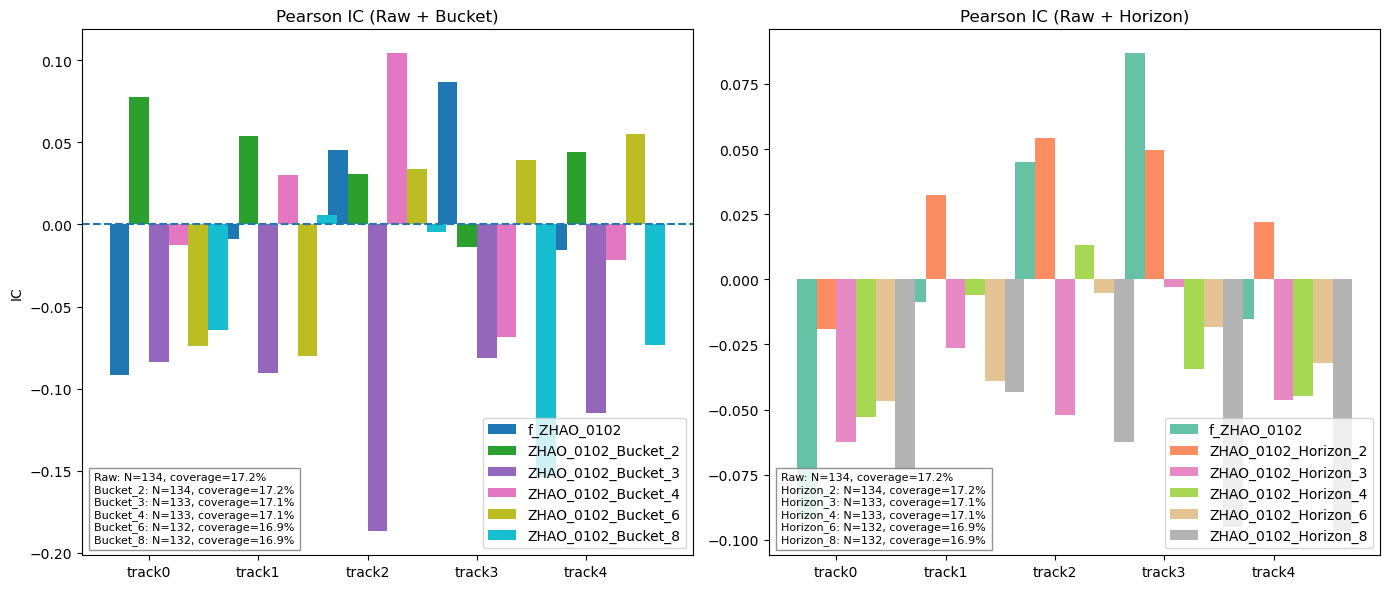

In [67]:
# 对Pearson IC值结果的可视化展示

# 1. 基本设置
x = np.arange(len(track_list))
width = 0.18  # 稍微加宽一点

# 分组（手动控制顺序）
group1 = [f"f_{FACTOR_COL}"] + [f"{FACTOR_COL}_Bucket_{i}" for i in Config.BUCKET_WEEKS]
group2 = [f"f_{FACTOR_COL}"] + [f"{FACTOR_COL}_Horizon_{i}" for i in Config.HORIZON_WEEKS]

colors1 = plt.cm.tab10(np.linspace(0, 1, len(group1)))
colors2 = plt.cm.Set2(np.linspace(0, 1, len(group2)))   

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ========= 左图：Bucket =========
ax = axes[0]

for i, factor in enumerate(group1):
    values = []
    for t in track_list:
        col = f"pearson_ic_track{t}"
        values.append(basic_ic_df.loc[factor, col])
    
    ax.bar(
        x + i * width,
        values,
        width=width,
        label=factor,
        color=colors1[i]
    )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"track{t}" for t in track_list])
ax.axhline(0, linestyle='--')
ax.set_title("Pearson IC (Raw + Bucket)")
ax.set_ylabel("IC")
ax.text(
    0.02, 0.02,
    make_coverage_text(group1, track_list),
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=8,
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray")
)
ax.legend(loc = 'lower right')

# ========= 右图：Horizon =========
ax = axes[1]

for i, factor in enumerate(group2):
    values = []
    for t in track_list:
        col = f"pearson_ic_track{t}"
        values.append(basic_ic_df.loc[factor, col])
    
    ax.bar(
        x + i * width,
        values,
        width=width,
        label=factor,
        color=colors2[i]
    )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"track{t}" for t in track_list])
ax.set_title("Pearson IC (Raw + Horizon)")
ax.text(
    0.02, 0.02,
    make_coverage_text(group2, track_list),
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=8,
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray")
)

ax.legend(loc = 'lower right')

plt.tight_layout()

figure_path = OUTPUT_DIR / "Bucket_Horizon.png"
plt.savefig(figure_path, format="png", dpi=300, bbox_inches="tight")
print(f"图片已保存到: {figure_path}")

plt.show()

In [68]:
# 滚动 3 个月 IC —— 分轨计算与可视化

def calc_rolling_ic(x, y, window=12, min_n=10):
    """
    逐点滚动计算 Pearson IC。
    
    参数
    ----------
    x : 因子序列
    y : 目标收益序列
    window : int, default=12
        滚动窗口长度。
        这里按“每条轨道周频数据的 3 个月 ≈ 12 个观测点”处理。
    min_n : int, default=10
        每个滚动窗口内最少有效样本数。
        不足时返回 NaN。
    
    返回
    ----------
    rolling_ic : pd.Series
        与输入索引对齐的滚动 IC 序列
    """
    df = pd.DataFrame({
        "x": pd.Series(x),
        "y": pd.Series(y)
    })

    rolling_ic = []

    for i in range(len(df)):
        # 当前点及其之前 window-1 个点
        start_idx = max(0, i - window + 1)
        sub_df = df.iloc[start_idx:i+1].dropna()

        if len(sub_df) < min_n:
            rolling_ic.append(np.nan)
            continue

        if sub_df["x"].nunique() <= 1 or sub_df["y"].nunique() <= 1:
            rolling_ic.append(np.nan)
            continue

        ic = pearsonr(sub_df["x"], sub_df["y"])[0]
        rolling_ic.append(ic)

    rolling_ic = pd.Series(rolling_ic, index=df.index, name="ic")
    return rolling_ic

In [69]:
# 1. 逐轨计算滚动 IC，并整理成一个总表 rolling_ic_df
rolling_ic_list = []

for track_id in track_list:
    sub_df = market_df_all[market_df_all[TRACK_COL] == track_id].copy()
    sub_df = sub_df.sort_index(ascending=True)

    sub_df["ic"] = calc_rolling_ic(
        x=sub_df[FACTOR_COL],
        y=sub_df[TARGET_COL],
        window=12,
        min_n=10
    )

    # 对“ic 序列”再做一个 12 期移动平均
    sub_df["ic_ma"] = sub_df["ic"].rolling(window=12, min_periods=10).mean()

    sub_df["track_id"] = track_id

    rolling_ic_list.append(
        sub_df[[FACTOR_COL, TARGET_COL, "track_id", "ic", "ic_ma"]]
    )

rolling_ic_df = pd.concat(rolling_ic_list, axis=0)
rolling_ic_has_valid = rolling_ic_df["ic"].notna().any()

if rolling_ic_has_valid:
    print("滚动 IC 结果（前几行）：")
else:
    print("滚动 IC 提示：当前参数下没有可用的 rolling IC，后续 rolling IC 手动检验和画图将自动跳过。")

display(rolling_ic_df.head())

滚动 IC 提示：当前参数下没有可用的 rolling IC，后续 rolling IC 手动检验和画图将自动跳过。


,ZHAO_0102,target_return_diff,track_id,ic,ic_ma
date,,,,,
2010-03-01,NaN,-0.002661,0,NaN,NaN
2010-03-08,NaN,0.001212,0,NaN,NaN
2010-03-15,NaN,0.000149,0,NaN,NaN
2010-03-22,NaN,-0.003019,0,NaN,NaN
2010-03-29,NaN,0.005571,0,NaN,NaN


In [70]:
# 1.1 手动检验：第一个有效 rolling IC 用到了哪些数据
check_track_id = track_list[0]
check_window = 12
check_min_n = 10

check_track_df = (
    market_df_all[market_df_all[TRACK_COL] == check_track_id]
    .copy()
    .sort_index(ascending=True)
)

check_track_ic = calc_rolling_ic(
    x=check_track_df[FACTOR_COL],
    y=check_track_df[TARGET_COL],
    window=check_window,
    min_n=check_min_n
)

first_valid_date = check_track_ic.first_valid_index()

if first_valid_date is None:
    print("手动检验提示：当前参数下没有可用的 rolling IC（可能有效样本不足）。")
else:
    end_loc = check_track_df.index.get_loc(first_valid_date)
    start_loc = max(0, end_loc - check_window + 1)

    manual_window_df = (
        check_track_df
        .iloc[start_loc:end_loc + 1][[FACTOR_COL, TARGET_COL]]
        .dropna()
        .copy()
    )

    manual_ic = pearsonr(manual_window_df[FACTOR_COL], manual_window_df[TARGET_COL])[0]
    function_ic = check_track_ic.loc[first_valid_date]

    print("\n首个有效 rolling IC 手动检验：")
    print(f"track_id = {check_track_id}")
    print(f"计算日期 = {first_valid_date}")
    print(f"窗口参数: window={check_window}, min_n={check_min_n}")
    print(f"该窗口有效样本数 = {len(manual_window_df)}")
    print(f"函数输出 IC = {function_ic:.10f}")
    print(f"手工计算 IC = {manual_ic:.10f}")
    print(f"差值(函数-手工) = {function_ic - manual_ic:.12e}")

    print("\n该次 rolling IC 实际使用的数据窗口：")
    display(manual_window_df)

手动检验提示：当前参数下没有可用的 rolling IC（可能有效样本不足）。


In [71]:
# 2. 画图：默认先画一个轨道
if not rolling_ic_has_valid:
    print("Rolling IC 画图提示：当前参数下没有可用的 rolling IC，跳过画图，继续执行后续信号检验法单元格。")
else:
    for track_id in track_list:
        plot_df = rolling_ic_df[rolling_ic_df["track_id"] == track_id].copy()
        plot_df = plot_df.sort_index(ascending=True)

        if plot_df["ic"].notna().sum() == 0:
            print(f"Rolling IC 画图提示：Track {track_id} 当前参数下没有可用的 rolling IC，跳过该轨道。")
            continue

    ic_mean = plot_df["ic"].mean()
    ic_std = plot_df["ic"].std()

    plt.figure(figsize=(14, 6))

    # 蓝线：每期 IC
    plt.plot(
        plot_df.index,
        plot_df["ic"],
        label="IC",
        alpha=0.35,
        linewidth=1.2
    )

    # 绿线：1 month moving avg
    plt.plot(
        plot_df.index,
        plot_df["ic_ma"],
        label="1 month moving avg",
        linewidth=2
    )

    # 0 轴
    plt.axhline(0, linewidth=1)

    # 标题和坐标轴
    plt.title(f"1 Period Forward Return Information Coefficient (IC) - Track {track_id}", fontsize=18)
    plt.ylabel("IC", fontsize=13)

    # 左上角统计框
    text_x = plot_df.index[int(len(plot_df) * 0.03)] if len(plot_df) > 0 else None
    if text_x is not None:
        plt.text(
            text_x,
            0.85 * plot_df["ic"].max() if plot_df["ic"].notna().sum() > 0 else 0,
            f"Mean {ic_mean:.3f}\nStd.  {ic_std:.3f}",
            fontsize=11,
            bbox=dict(facecolor="white", alpha=0.9)
        )

    plt.legend()
    plt.grid(True, alpha=0.3)

    figure_path = OUTPUT_DIR / f"RollingIC_{track_id}.png"
    plt.savefig(figure_path, format="png", dpi=300, bbox_inches="tight")
    print(f"图片已保存到: {figure_path}")

    plt.show()

Rolling IC 画图提示：当前参数下没有可用的 rolling IC，跳过画图，继续执行后续信号检验法单元格。


## 信号检验法

In [72]:
# Cell 41: 参数定义
benchmark_mode = "rebalance_50"
benchmark_rebalance_months = 2 # 每n个月调回一次50%+50%
# "buy_and_hold_50"  : 期初买入 50% 成长 + 50% 价值，之后完全不调仓
# "rebalance_50"     : 按 benchmark_rebalance_months 设定的频率，定期调回 50% 成长 + 50% 价值

# 交易参数设置
trans_fee = 0.002          # 单边手续费（买入或卖出均按此费率收取）
charge_initial_trade = True  # True = 期初建仓也收手续费；False = 期初建仓免费
rf = 0.015          # 无风险利率（年化），用于计算夏普比率等
annual_days = Config.ANNUAL_TRADING_DAYS  # 一年按多少天折算，用于年化收益率和年化波动率，这里仍然使用交易日（而非自然日）
weight_tol = 1e-10 # 两个浮点数权重之差小于 weight_tol，就认为它们相等，不触发调仓

# factor_available_date = "2010-02-28" #组合的时候知道组合的信号是哪天先发出的，如果是单因子的话把这行注释掉

# 输出目录
if benchmark_mode == "rebalance_50":
    strat_suffix = f"{benchmark_mode}_{benchmark_rebalance_months}m"
else:
    strat_suffix = benchmark_mode

STRAT_OUTPUT_DIR = OUTPUT_DIR / f"strategy_{strat_suffix}"
STRAT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [73]:
# Cell 42: 定义策略绩效计算函数

# 为计算绩效指标做准备：把 future return 统一转换成 simple return
def to_simple_return(ret_series, return_type=Config.RETURN_TYPE):
    """
    把底层收益率统一转换成 simple return，便于后面计算净值、回撤、夏普等指标。
    """
    ret_series = pd.Series(ret_series).astype(float)

    if return_type == "log":
        return np.expm1(ret_series)
    elif return_type == "simple":
        return ret_series

In [74]:
# Cell 43: 生成策略用底表
cols_to_keep = [
    "track_id",
    FACTOR_COL,
    "fwd_ret_g",
    "fwd_ret_v",
    "holding_days",
    "target_return_diff",
    "next_date",
    "target_label",
    "close_g",
    "close_v"
]

work_df = market_df_all.copy().sort_index(ascending=True)
work_df = work_df[cols_to_keep].copy()
work_df["next_date"] = pd.to_datetime(work_df["next_date"])

# 把底层收益率统一转成 simple return，后面净值计算可以统一用"连乘 (1 + r)"

work_df["fwd_ret_g_simple"] = to_simple_return(
    work_df["fwd_ret_g"],
    return_type=Config.RETURN_TYPE
)

work_df["fwd_ret_v_simple"] = to_simple_return(
    work_df["fwd_ret_v"],
    return_type=Config.RETURN_TYPE
)

# 成长 - 价值的 simple return 差，方便后面直接用
work_df["fwd_ret_diff_simple"] = work_df["fwd_ret_g_simple"] - work_df["fwd_ret_v_simple"]

# 检查：work_df[["track_id", "holding_days", "next_date"]]，应该每一行都有 next_date，

display(
    work_df[
        [
            "track_id", FACTOR_COL,
            "fwd_ret_g", "fwd_ret_v",
            "fwd_ret_g_simple", "fwd_ret_v_simple",
            "holding_days", "next_date"
        ]
    ].head(10)
)

,track_id,ZHAO_0102,fwd_ret_g,fwd_ret_v,fwd_ret_g_simple,fwd_ret_v_simple,holding_days,next_date
date,,,,,,,,
2010-03-01,0.000000,NaN,-0.010968,-0.008307,-0.010908,-0.008273,5.000000,2010-03-08
2010-03-02,1.000000,NaN,-0.002234,-0.000310,-0.002232,-0.000310,5.000000,2010-03-09
2010-03-03,2.000000,NaN,-0.019333,-0.017006,-0.019148,-0.016863,5.000000,2010-03-10
2010-03-04,3.000000,NaN,0.005921,0.009750,0.005939,0.009798,5.000000,2010-03-11
2010-03-05,4.000000,NaN,-0.010521,-0.007837,-0.010466,-0.007807,5.000000,2010-03-12
2010-03-08,0.000000,NaN,-0.033151,-0.034363,-0.032608,-0.033780,5.000000,2010-03-15
2010-03-09,1.000000,NaN,-0.030142,-0.029663,-0.029692,-0.029228,5.000000,2010-03-16
2010-03-10,2.000000,NaN,0.001701,0.000514,0.001703,0.000514,5.000000,2010-03-17
2010-03-11,3.000000,NaN,0.002637,-0.002481,0.002640,-0.002478,5.000000,2010-03-18


In [75]:
# Cell 44：定义权重漂移函数

def calc_pre_trade_actual_weight(
    prev_post_weight_g, prev_post_weight_v, prev_ret_g_simple, prev_ret_v_simple
):
    """
    把“上一期调仓后权重”根据上一期真实资产涨跌，
    推到“本期调仓前的实际权重”。

    输入：
    prev_post_weight_g : float
        上一期调仓后，成长资产权重
    prev_post_weight_v : float
        上一期调仓后，价值资产权重
    prev_ret_g_simple : float
        上一期持有区间内，成长资产 simple return
    prev_ret_v_simple : float
        上一期持有区间内，价值资产 simple return

    输出：
    pre_trade_weight_g : float
        本期调仓前，成长资产的实际权重
    pre_trade_weight_v : float
        本期调仓前，价值资产的实际权重
    """

    end_value_g = prev_post_weight_g * (1 + prev_ret_g_simple)
    end_value_v = prev_post_weight_v * (1 + prev_ret_v_simple)

    total_value = end_value_g + end_value_v

    pre_trade_weight_g = end_value_g / total_value
    pre_trade_weight_v = end_value_v / total_value

    return pre_trade_weight_g, pre_trade_weight_v

In [76]:
# 判断两组权重是否在容忍度下不同
def weights_are_different(weight_g_a, weight_v_a, weight_g_b, weight_v_b, tol = weight_tol):
    diff_g = abs(weight_g_a - weight_g_b)
    diff_v = abs(weight_v_a - weight_v_b)

    if (diff_g > tol) or (diff_v > tol):
        return True
    else:
        return False

In [77]:
# Cell 45：定义“本期是否交易、交易后仓位是多少”的决策函数

def decide_post_trade_weight(
    pre_trade_weight_g,
    pre_trade_weight_v,
    signal_ls,
    target_weight_g,
    target_weight_v,
    signal_update_flag,
    prev_effective_signal_ls,
    benchmark_mode,
    weight_tol = weight_tol,
    receiver = "benchmark",  #根据计算对象是策略还是基准，选用"strategy"或"benchmark"
    benchmark_ref_row = None #如果receiver是"strategy"，则需要提供一个benchmark_ref_row，包含该轨道对应日期的benchmark仓位信息，以便在signal_ls=0时直接取用benchmark仓位
):
    """
    根据当前目标仓位、上一期有效仓位、本期是否有新信号，
    决定本期是否交易，以及交易后的仓位。

    输入：
    pre_trade_weight_g / pre_trade_weight_v
        本期调仓前的实际权重

    signal_ls
        本期原始目标方向：
        1  = 全仓成长
        -1 = 全仓价值
        0  = 50/50 中性
        NaN = 本期没有新事件（只会在 event 模式下出现）

    target_weight_g / target_weight_v
        本期原始目标权重

    signal_update_flag
        1 = 本期有新状态 / 新事件
        0 = 本期没有新事件，沿用上一期

    prev_effective_signal_ls
        上一期真正生效的信号方向
        第一行没有上一期，用 NaN 表示

    benchmark_mode
        "buy_and_hold_50" 或 "rebalance_50"

    weight_tol
        权重比较容忍度

    输出：
    ----------
    effective_signal_ls
    post_trade_weight_g
    post_trade_weight_v
    trade_flag
    signal_count
    """

    # =========================================================
    # 情况 A：第一期建仓
    # 判断标准：上一期有效仓位不存在
    # =========================================================
    is_first_row = pd.isna(prev_effective_signal_ls)

    if receiver == "benchmark":
        effective_signal_ls = 0

        # ---- 第一行：期初建仓到 50/50 ----
        if is_first_row:
            post_trade_weight_g = 0.5
            post_trade_weight_v = 0.5
            trade_flag = 1
            signal_count = 1

            return(
                effective_signal_ls,
                post_trade_weight_g,
                post_trade_weight_v,
                trade_flag,
                signal_count
            )

        if benchmark_mode == "buy_and_hold_50":
            post_trade_weight_g = float(pre_trade_weight_g)
            post_trade_weight_v = float(pre_trade_weight_v)

            trade_flag = 0
            signal_count = 1
        
        elif benchmark_mode == "rebalance_50":
            if signal_update_flag == 0:
                post_trade_weight_g = float(pre_trade_weight_g)
                post_trade_weight_v = float(pre_trade_weight_v)
                trade_flag = 0
                signal_count = 1

                return(
                    effective_signal_ls,
                    post_trade_weight_g,
                    post_trade_weight_v,
                    trade_flag,
                    signal_count
                )

            else:
                post_trade_weight_g = 0.5
                post_trade_weight_v = 0.5

                need_trade = weights_are_different(
                    pre_trade_weight_g,
                    pre_trade_weight_v,
                    post_trade_weight_g,
                    post_trade_weight_v,
                    weight_tol
                )

                trade_flag = int(need_trade)
                signal_count = 1

                return(
                    effective_signal_ls,
                    post_trade_weight_g,
                    post_trade_weight_v,
                    trade_flag,
                    signal_count
                )

        else:
            raise ValueError(
                f"benchmark_mode 只能是 'buy_and_hold_50' 或 'rebalance_50'，当前值为：{benchmark_mode}"
            )

    elif receiver == "strategy":

        # -----------------------------------------------------
        # 情况 A：本期没有新信号（event 模式下常见）
        # 规则：维持上期 hold，不调仓
        # -----------------------------------------------------

        if signal_update_flag == 0:

            # 首期如果没有信号，无法维持上期
            if is_first_row:
                effective_signal_ls = 0

                if benchmark_ref_row is not None:
                    post_trade_weight_g = float(benchmark_ref_row["post_trade_weight_g"])
                    post_trade_weight_v = float(benchmark_ref_row["post_trade_weight_v"])
                else:
                    post_trade_weight_g = 0.5
                    post_trade_weight_v = 0.5

                need_trade = weights_are_different(
                    pre_trade_weight_g,
                    pre_trade_weight_v,
                    post_trade_weight_g,
                    post_trade_weight_v,
                    weight_tol
                )
                trade_flag = int(need_trade)
                signal_count = 0

                return(
                    effective_signal_ls,
                    post_trade_weight_g,
                    post_trade_weight_v,
                    trade_flag,
                    signal_count
                )

            # 正常无信号
            effective_signal_ls = int(prev_effective_signal_ls)
            
            # 如果上一期已经是中性状态，后续无新事件期间继续跟随基准仓位
            if effective_signal_ls == 0:
                if benchmark_ref_row is None:
                    raise ValueError(
                        "strategy在中性状态延续时需要benchmark_ref_row提供基准仓位信息"
                    )

                post_trade_weight_g = float(benchmark_ref_row["post_trade_weight_g"])
                post_trade_weight_v = float(benchmark_ref_row["post_trade_weight_v"])

                need_trade = weights_are_different(
                    pre_trade_weight_g,
                    pre_trade_weight_v,
                    post_trade_weight_g,
                    post_trade_weight_v,
                    weight_tol
                )

                trade_flag = int(need_trade)
                signal_count = 0

                return (
                    effective_signal_ls,
                    post_trade_weight_g,
                    post_trade_weight_v,
                    trade_flag,
                    signal_count
                )

            # 上一期是成长/价值信号时，才维持漂移仓位
            post_trade_weight_g = float(pre_trade_weight_g)
            post_trade_weight_v = float(pre_trade_weight_v)
            trade_flag = 0
            signal_count = 0

            return (
                effective_signal_ls,
                post_trade_weight_g,
                post_trade_weight_v,
                trade_flag,
                signal_count
            )
        
        # -----------------------------------------------------
        # 情况 B：本期有新信号，但signal_ls = 0
        # 规则：引用基准曲线的仓位
        # -----------------------------------------------------
        if signal_ls == 0:
            if benchmark_ref_row is None:
                raise ValueError(
                    "strategy在signal_ls=0时需要benchmark_ref_row提供基准仓位信息，但当前值为None"
                )
            
            effective_signal_ls = 0
            post_trade_weight_g = float(benchmark_ref_row["post_trade_weight_g"])
            post_trade_weight_v = float(benchmark_ref_row["post_trade_weight_v"])
            signal_count = 1

            need_trade = weights_are_different(
                pre_trade_weight_g,
                pre_trade_weight_v,
                post_trade_weight_g,
                post_trade_weight_v,
                weight_tol
            )
            trade_flag = int(need_trade)

            return(
                effective_signal_ls,
                post_trade_weight_g,
                post_trade_weight_v,
                trade_flag,
                signal_count
            )

        # -----------------------------------------------------
        # 情况 C：本期有新信号，且signal_ls ∈ {-1,1}
        # 规则：按照signal_ls进行调仓
        # -----------------------------------------------------

        effective_signal_ls = int(signal_ls)
        post_trade_weight_g = float(target_weight_g)
        post_trade_weight_v = float(target_weight_v)

        need_trade = weights_are_different(
            pre_trade_weight_g,
            pre_trade_weight_v,
            post_trade_weight_g,
            post_trade_weight_v,
            weight_tol
        )
        trade_flag = int(need_trade)
        signal_count = 1

        return(
            effective_signal_ls,
            post_trade_weight_g,
            post_trade_weight_v,
            trade_flag,
            signal_count
        )
        
    else:
        raise ValueError(
            f"receiver 参数只能是 'strategy' 或 'benchmark'，当前值为：{receiver}"
        )

In [78]:
# Cell 46：状态型信号函数定义

# 状态型信号：每一个调仓点都重新看一次因子值，然后判断目标仓位。
# 无论因子是什么值，每一行都必须有一个明确的目标仓位，不允许出现空仓。
#
# 输入：
#   track_df   - 单条轨道的 DataFrame（已经是某一条轨道的子集）
#   factor_col - 因子列的列名（字符串），例如 "factor_mom_1m_diff"
#
# 输出：
#   在 track_df 的副本上新增以下 5 列，并返回这个副本：
#     target_weight_g   : 成长指数的目标权重，取值只能是 0.0 / 0.5 / 1.0
#     target_weight_v   : 价值指数的目标权重，取值只能是 0.0 / 0.5 / 1.0
#     signal_ls         : 多空方向信号，目标方向，+1=全仓成长，-1=全仓价值，0=50/50中性
#     signal_update_flag: 状态型信号每期都重新判断，所以恒为 1

def build_state_target_position(track_df, factor_col, bar = 0):
    """
    状态型信号函数：把每一行的因子值映射成目标仓位。

    规则：
        factor > 0          -> 全仓成长  (signal_ls =  1)
        factor < 0          -> 全仓价值  (signal_ls = -1)
        factor == 0 或 NaN  -> 跟随基准曲线

    注意：
        - 这里绝对不能再做 shift，因子在挂载时已经做过 shift(1) 了。
        - NaN 和 0 都按同期基准仓位处理，引用benchmark的持仓情况，不做任何再计算。
        - signal_ls = 0 的含义是模型未发出价值/成长信号，因此也参照基准。
    """

    # 先做一个副本，避免修改传进来的原始 DataFrame
    signal_df = track_df.copy()

    # ---- 第一步：先把所有行都初始化成"中性 50/50" ----
    # 这样 NaN 和 0 就自动被兜底处理了，不用再单独写 elif
    signal_df["target_weight_g"] = 0.5
    signal_df["target_weight_v"] = 0.5
    signal_df["signal_ls"]       = 0

    # ---- 第二步：覆盖"看好成长"的行（因子值严格大于 0） ----
    mask_growth = signal_df[factor_col] > bar
    signal_df.loc[mask_growth, "target_weight_g"] = 1.0
    signal_df.loc[mask_growth, "target_weight_v"] = 0.0
    signal_df.loc[mask_growth, "signal_ls"]       = 1

    # ---- 第三步：覆盖"看好价值"的行（因子值严格小于 0） ----
    mask_value = signal_df[factor_col] < -1 * bar
    signal_df.loc[mask_value, "target_weight_g"] = 0.0
    signal_df.loc[mask_value, "target_weight_v"] = 1.0
    signal_df.loc[mask_value, "signal_ls"]       = -1

    # ---- 第四步：状态型信号每期都重新判断，所以 signal_update_flag 恒为 1 ----
    signal_df["signal_update_flag"] = 1

    return signal_df

In [79]:
# Cell 47：触发型事件信号函数定义

# 触发型事件信号：只有在"本期发生了新事件"时，才更新目标仓位。
# 没有新事件的行，目标仓位全部用 NaN 表示"维持上期仓位不变"。
#
# 这和状态型信号的关键区别是：
#   状态型：每一期都重新判断，signal_update_flag 恒为 1
#   事件型：只有事件触发时才更新，没有事件时 signal_update_flag = 0，
#           目标仓位列全部为 NaN（不是 0！）
#
# 输入：
#   track_df       - 单条轨道的 DataFrame
#   event_col      - 事件列的列名（字符串）
#                    该列的取值含义：
#                      > 0  -> 看好成长事件
#                      < 0  -> 看好价值事件
#                      == 0 -> 未触发看好价值或成长，但是有数据输入
#                      NaN  -> 本期没有新事件
#   event_time_col - 可选参数，事件发生的具体时间列（字符串或 None）
#                    当前版本暂不使用，保留接口供未来扩展
#
# 输出：
#   在 track_df 的副本上新增以下 5 列，并返回这个副本：
#     target_weight_g   : 有新事件时为 0.0/0.5/1.0；无新事件时为 NaN
#     target_weight_v   : 有新事件时为 0.0/0.5/1.0；无新事件时为 NaN
#     signal_ls         : 有新事件时为 +1/0/-1；无新事件时为 NaN
#     signal_update_flag: 有新事件时为 1；无新事件时为 0

def build_event_target_position(track_df, event_col, event_time_col=None, bar = 0):
    """
    触发型事件信号函数：只有本期发生了新事件才更新目标仓位。

    规则：
        本期有新事件，且事件方向 > 0  -> 全仓成长  (signal_ls =  1)
        本期有新事件，且事件方向 < 0  -> 全仓价值  (signal_ls = -1)
        本期有新事件，且事件方向 == 0 -> 引用基准曲线仓位
        本期没有新事件（event_col 为 NaN） -> 延续上一期信号

    重要：
        - 没有新事件时，signal_ls 必须是 NaN，不能是 0。
          因为 signal_ls = 0 已经被定义为"明确触发了中性事件"，
          如果没有事件时也写 0，后面代码就无法区分这两种情况。
        - event_time_col 参数当前版本暂不使用，接口保留供未来扩展。
    """

    # 先做一个副本，避免修改传进来的原始 DataFrame
    signal_df = track_df.copy()

    # ---- 第一步：把所有行都初始化成"无新事件"状态 ----
    # 用 NaN 表示"本期没有新事件，维持上期仓位"
    signal_df["target_weight_g"]   = np.nan
    signal_df["target_weight_v"]   = np.nan
    signal_df["signal_ls"]         = np.nan
    signal_df["signal_update_flag"] = 0       # 没有事件 -> 不更新 -> 0

    # ---- 第二步：识别"本期有新事件"的行 ----
    # 判断标准：event_col 不是 NaN 就算有新事件
    has_event_mask = signal_df[event_col].notna()

    # ---- 第三步：在有新事件的行里，再区分方向 ----

    # 情况 A：新事件看好成长（event_col > bar）
    mask_growth = has_event_mask & (signal_df[event_col] > bar)
    signal_df.loc[mask_growth, "target_weight_g"]    = 1.0
    signal_df.loc[mask_growth, "target_weight_v"]    = 0.0
    signal_df.loc[mask_growth, "signal_ls"]          = 1
    signal_df.loc[mask_growth, "signal_update_flag"] = 1

    # 情况 B：新事件看好价值（event_col < -1 * bar）
    mask_value = has_event_mask & (signal_df[event_col] < -1 * bar)
    signal_df.loc[mask_value, "target_weight_g"]    = 0.0
    signal_df.loc[mask_value, "target_weight_v"]    = 1.0
    signal_df.loc[mask_value, "signal_ls"]          = -1
    signal_df.loc[mask_value, "signal_update_flag"] = 1

    # 情况 C：新事件为中性（event_col 在 [-1*bar, bar]之间，不是 NaN）
    # 注意：这里要用 has_event_mask 做前置过滤，
    # 不能直接写 signal_df[event_col] == 0，
    # 因为 NaN == 0 在 pandas 里会返回 False（而不是 NaN），
    # 单独依赖 == 0 判断有逻辑歧义，加上 has_event_mask 更安全、更清晰
    mask_neutral = has_event_mask & (signal_df[event_col].between(-1 * bar, bar))
    signal_df.loc[mask_neutral, "target_weight_g"]    = 0.5
    signal_df.loc[mask_neutral, "target_weight_v"]    = 0.5
    signal_df.loc[mask_neutral, "signal_ls"]          = 0
    signal_df.loc[mask_neutral, "signal_update_flag"] = 1

    # ---- 第四步：event_time_col 接口预留（当前版本不做任何操作） ----
    # 如果未来需要按照事件发生的具体时间对信号做延迟处理，在这里扩展
    if event_time_col is not None:
        pass  # 当前版本暂不实现，接口保留

    return signal_df


# ------ 快速验证：用 work_df 里的 FACTOR_COL 列模拟一个事件列跑一下 ------
# 因为当前阶段还没有正式的事件列，
# 这里用 FACTOR_COL 列来模拟事件（直接复用因子值当事件列），
# 只是为了验证函数输出的列结构是否正确，不代表真实的事件型策略逻辑

_test_track_id_ev  = work_df["track_id"].dropna().unique()[0]
_test_track_df_ev  = work_df[work_df["track_id"] == _test_track_id_ev].copy()
_test_result_ev    = build_event_target_position(_test_track_df_ev, event_col=FACTOR_COL)

print("===== Cell 47 验证：触发型事件信号函数输出结构 =====")
print(f"  测试轨道 track_id = {_test_track_id_ev}")
print(f"  输出列名          : {list(_test_result_ev.columns)}")
print()

# 检查 signal_update_flag 只有 0 和 1 两种值
_flag_values = _test_result_ev["signal_update_flag"].unique()
print(f"  signal_update_flag 出现的所有取值 : {sorted(_flag_values)}")
assert set(_flag_values).issubset({0, 1}), \
    "signal_update_flag 出现了预期之外的值，只允许 0 或 1"

# 检查：有新事件的行，signal_ls 不能是 NaN
_triggered_rows = _test_result_ev[_test_result_ev["signal_update_flag"] == 1]
assert _triggered_rows["signal_ls"].notna().all(), \
    "有新事件的行（signal_update_flag=1）里出现了 NaN 的 signal_ls，请检查函数逻辑"

# 检查：没有新事件的行，signal_ls 必须全部是 NaN
_no_event_rows = _test_result_ev[_test_result_ev["signal_update_flag"] == 0]
assert _no_event_rows["signal_ls"].isna().all(), \
    "没有新事件的行（signal_update_flag=0）里出现了非 NaN 的 signal_ls，请检查函数逻辑"

# 打印触发事件 / 无事件的行数分布
print()
print("  signal_update_flag 各取值的行数分布：")
display(_test_result_ev["signal_update_flag"].value_counts().sort_index(ascending=True).to_frame("行数"))

print()
print("  前 10 行预览（含信号列）：")
_preview_cols_ev = [FACTOR_COL, "target_weight_g", "target_weight_v",
                    "signal_ls", "signal_update_flag"]
display(_test_result_ev[_preview_cols_ev].head(10))

print()
print("注意：以上验证是用 FACTOR_COL 列模拟事件列跑的，")
print("仅用于检查函数输出结构是否正确，不代表真实的事件型策略逻辑。")

===== Cell 47 验证：触发型事件信号函数输出结构 =====
  测试轨道 track_id = 0.0
  输出列名          : ['track_id', 'ZHAO_0102', 'fwd_ret_g', 'fwd_ret_v', 'holding_days', 'target_return_diff', 'next_date', 'target_label', 'close_g', 'close_v', 'fwd_ret_g_simple', 'fwd_ret_v_simple', 'fwd_ret_diff_simple', 'target_weight_g', 'target_weight_v', 'signal_ls', 'signal_update_flag']

  signal_update_flag 出现的所有取值 : [0, 1]

  signal_update_flag 各取值的行数分布：


,行数
signal_update_flag,
0,624
1,134



  前 10 行预览（含信号列）：


,ZHAO_0102,target_weight_g,target_weight_v,signal_ls,signal_update_flag
date,,,,,
2010-03-01,NaN,NaN,NaN,NaN,0
2010-03-08,NaN,NaN,NaN,NaN,0
2010-03-15,NaN,NaN,NaN,NaN,0
2010-03-22,NaN,NaN,NaN,NaN,0
2010-03-29,NaN,NaN,NaN,NaN,0
2010-04-12,NaN,NaN,NaN,NaN,0
2010-04-19,NaN,NaN,NaN,NaN,0
2010-04-26,NaN,NaN,NaN,NaN,0
2010-05-10,NaN,NaN,NaN,NaN,0



注意：以上验证是用 FACTOR_COL 列模拟事件列跑的，
仅用于检查函数输出结构是否正确，不代表真实的事件型策略逻辑。


In [80]:
# Cell 48: 构造基准侧目标仓位表（benchmark_target_df），也就是成长-价值 50-50

# "连续两个 50/50 是否真的产生换手"，由后面的执行器根据 benchmark_mode 决定，
#  这张表里不做这个判断。
#
# 输入变量：
#   strategy_target_df - Cell 38 生成的策略侧目标仓位表
#
# 输出变量：
#   benchmark_target_df - 基准侧目标仓位表

# ------ 第一步：复制策略表的索引和公共列 ------
# 只复制"和底层收益有关"的列，目标仓位列之后重新赋值

cols_to_copy = [
    "track_id",
    FACTOR_COL,
    "fwd_ret_g_simple",
    "fwd_ret_v_simple",
    "holding_days",
    "next_date"
]

benchmark_target_df = work_df[cols_to_copy].copy()

# ------ 第二步：定义“每 n 个月再平衡一次”的日期标记函数 ------
def build_benchmark_rebalance_flag(track_index, rebalance_months):
    """
    给单条轨道生成再平衡标记：
    - 第一行一定标记为 1（期初建仓）
    - 之后当“当前日期 >= 上一次再平衡日期 + n个月”时，
      在该轨道上第一个满足条件的交易点标记为 1
    - 其他行标记为 0

    这样可以适配：
    - 周频轨道
    - 节假日导致的日期不整齐
    - “满 n 个月后的首个可交易点”再平衡
    """
    track_index = pd.DatetimeIndex(track_index).sort_values()

    rebalance_flag = pd.Series(0, index=track_index, dtype="int64")

    last_rebalance_dt = None

    for dt in track_index:
        if last_rebalance_dt is None:
            rebalance_flag.loc[dt] = 1 #期初第一次调仓
            last_rebalance_dt = dt
            continue

        next_due_dt = last_rebalance_dt + pd.DateOffset(months=rebalance_months)

        if dt >= next_due_dt:
            rebalance_flag.loc[dt] = 1
            last_rebalance_dt = dt

    return rebalance_flag

# ------ 第三步：把所有目标仓位列固定为 50/50 中性 ------
benchmark_target_df["target_weight_g"] = 0.5
benchmark_target_df["target_weight_v"] = 0.5
benchmark_target_df["signal_ls"] = 0

# 先初始化
benchmark_target_df["signal_update_flag"] = 0 #基准的signal_update_flag意为本期是否需要rebalance

# 逐轨生成“每 n 个月再平衡”的标记
for track_id in track_list:
    mask = benchmark_target_df["track_id"] == track_id
    track_index = benchmark_target_df.loc[mask].index

    if benchmark_mode == "buy_and_hold_50":
        rebalance_flag = pd.Series(0, index=track_index, dtype="int64")
        rebalance_flag.iloc[0] = 1  # 期初建仓一次
    
    elif benchmark_mode == "rebalance_50":
        rebalance_flag = build_benchmark_rebalance_flag(
            track_index=track_index,
            rebalance_months=benchmark_rebalance_months
        )
    else:
        raise ValueError(
            f"benchmark_mode 只能是 'buy_and_hold_50' 或 'rebalance_50'，当前值为：{benchmark_mode}"
        )

    benchmark_target_df.loc[mask, "signal_update_flag"] = rebalance_flag.values

benchmark_target_df["signal_update_flag"] = (
    benchmark_target_df["signal_update_flag"].astype(int)
)


display(
    benchmark_target_df.loc[
        benchmark_target_df["track_id"] == 1,
        [
            "track_id",
            "target_weight_g",
            "target_weight_v",
            "signal_ls",
            "signal_update_flag"
        ],
    ].head(20)
)

,track_id,target_weight_g,target_weight_v,signal_ls,signal_update_flag
date,,,,,
2010-03-02,1.000000,0.500000,0.500000,0,1
2010-03-09,1.000000,0.500000,0.500000,0,0
2010-03-16,1.000000,0.500000,0.500000,0,0
2010-03-23,1.000000,0.500000,0.500000,0,0
2010-03-30,1.000000,0.500000,0.500000,0,0
2010-04-06,1.000000,0.500000,0.500000,0,0
2010-04-13,1.000000,0.500000,0.500000,0,0
2010-04-20,1.000000,0.500000,0.500000,0,0
2010-04-27,1.000000,0.500000,0.500000,0,0


In [81]:
# Cell 49: 定义单轨回测器

def run_single_track_backtest(
    track_target_df,
    benchmark_mode,
    trans_fee,
    charge_initial_trade,
    receiver = "Undefined",
    benchmark_ref_track_df = None
):
    """
    按日期逐行执行单条轨道的回测。

    输入：
    track_target_df : DataFrame，单条轨道的目标仓位表
    benchmark_mode : str，"buy_and_hold_50" 或 "rebalance_50"
    trans_fee : float，单边手续费率
    charge_initial_trade : bool，True  = 第一期建仓收费，False = 第一期建仓免费
    benchmark_rebalance_months: int or None，benchmark_mode = "rebalance_50" 时需要
    receiver : str，"strategy" 或 "benchmark"，
    benchmark_ref_track_df: DataFrame or None, 仅strategy使用

    输出：
    track_result_df : DataFrame，单轨结果表，每一行代表："从当前调仓日持有到下一次同轨道调仓日"的一个完整持有区间
    """

    # ------ 第一步：初始化 ------
    track_df = track_target_df.copy().sort_index(ascending=True)

    if receiver not in {"strategy", "benchmark"}:
        raise ValueError(
            f"receiver 参数只能是 'strategy' 或 'benchmark'，当前值为：{receiver}"
        )
    
    if benchmark_ref_track_df is not None:
        benchmark_ref_track_df = benchmark_ref_track_df.copy().sort_index(ascending=True)

    # ------ 第二步：逐行循环执行 ------
    result_rows = []

    prev_post_weight_g = np.nan
    prev_post_weight_v = np.nan
    prev_ret_g_simple = np.nan
    prev_ret_v_simple = np.nan
    prev_effective_signal_ls = np.nan

    for dt, row in track_df.iterrows():
        # 第一步：确定本期调仓前实际仓位
        if pd.isna(prev_effective_signal_ls):
            # 第一行没有上一期，从“空仓现金状态”开始建仓
            pre_trade_weight_g = 0.0
            pre_trade_weight_v = 0.0
        else:
            pre_trade_weight_g, pre_trade_weight_v = calc_pre_trade_actual_weight(
                prev_post_weight_g=prev_post_weight_g,
                prev_post_weight_v=prev_post_weight_v,
                prev_ret_g_simple=prev_ret_g_simple,
                prev_ret_v_simple=prev_ret_v_simple
            )

        # 第二步：引用strategy需要的benchmark row
        benchmark_ref_row = None
        if (receiver == "strategy") and (benchmark_ref_track_df is not None):
            if dt not in benchmark_ref_track_df.index:
                raise ValueError(
                    f"receiver 是 'strategy'，且提供了 benchmark_ref_track_df，但在日期 {dt} 没有找到对应的基准数据行，请检查 benchmark_ref_track_df 的索引和日期覆盖情况"
                )
            benchmark_ref_row = benchmark_ref_track_df.loc[dt]

        # 第三步：决定本期调仓后仓位
        (
            effective_signal_ls,
            post_trade_weight_g,
            post_trade_weight_v,
            trade_flag,
            signal_count
        ) = decide_post_trade_weight(
            pre_trade_weight_g=pre_trade_weight_g,
            pre_trade_weight_v=pre_trade_weight_v,
            signal_ls=row["signal_ls"],
            target_weight_g=row["target_weight_g"],
            target_weight_v=row["target_weight_v"],
            signal_update_flag=row["signal_update_flag"],
            prev_effective_signal_ls=prev_effective_signal_ls,
            benchmark_mode=benchmark_mode,
            weight_tol=weight_tol,
            receiver = receiver,
            benchmark_ref_row = benchmark_ref_row
        )

        # 第四步：算本期换手率和费用
        if trade_flag == 1:
            turnover_2way = (
                abs(post_trade_weight_g - pre_trade_weight_g)
                + abs(post_trade_weight_v - pre_trade_weight_v)
            )
        else:
            turnover_2way = 0.0

        # 第一期建仓是否收费，由 charge_initial_trade 控制
        if pd.isna(prev_effective_signal_ls) and (charge_initial_trade is False):
            cost_rate = 0.0
        else:
            cost_rate = turnover_2way * trans_fee

        # 第五步：算本期多头组合收益
        fwd_ret_g_simple = float(row["fwd_ret_g_simple"])
        fwd_ret_v_simple = float(row["fwd_ret_v_simple"])

        period_ret_long_gross = (
            post_trade_weight_g * fwd_ret_g_simple
            + post_trade_weight_v * fwd_ret_v_simple
        )

        period_ret_long_net = (1 - cost_rate) * (1 + period_ret_long_gross) - 1

        # 第六步：算本期多空收益
        period_ret_ls = effective_signal_ls * (fwd_ret_g_simple - fwd_ret_v_simple)

        # 第七步：把所有中间量都存下来
        row_result_1 = {
            "track_id": row["track_id"],
            "next_date": row["next_date"],
            "signal_ls_raw": row["signal_ls"],
            "effective_signal_ls": effective_signal_ls,
            "signal_update_flag": row["signal_update_flag"],
            "pre_trade_weight_g": pre_trade_weight_g,
            "pre_trade_weight_v": pre_trade_weight_v,
            "post_trade_weight_g": post_trade_weight_g,
            "post_trade_weight_v": post_trade_weight_v,
            "trade_flag": trade_flag,
            "signal_count": signal_count,
            "turnover_2way": turnover_2way,
            "cost_rate": cost_rate,
            "fwd_ret_g_simple": fwd_ret_g_simple,
            "fwd_ret_v_simple": fwd_ret_v_simple,
            "holding_days": row["holding_days"],
            "period_ret_long_gross": period_ret_long_gross,
            "period_ret_long_net": period_ret_long_net,
            "period_ret_ls": period_ret_ls,
        }

        result_rows.append(row_result_1)

        # 为下一行更新“上一期状态”
        prev_post_weight_g = post_trade_weight_g
        prev_post_weight_v = post_trade_weight_v
        prev_ret_g_simple = fwd_ret_g_simple
        prev_ret_v_simple = fwd_ret_v_simple
        prev_effective_signal_ls = effective_signal_ls

    # ------ 第三步：整理成结果表 ------
    track_result_df = pd.DataFrame(result_rows, index=track_df.index)
    return track_result_df

In [82]:
# Cell 50: 跑完整个基准的五轨回测

# 输入变量：
#   benchmark_target_df
#   track_list
#   run_single_track_backtest
#
# 输出变量：
#   benchmark_period_df

# ------ 第一步：逐轨执行单轨回测 ------
benchmark_result_list = []

for track_id in track_list:
    # 取出当前轨道的数据，并按日期排序
    track_target_df = (
        benchmark_target_df[benchmark_target_df["track_id"] == track_id]
        .copy()
        .sort_index(ascending=True)
    )

    # 调用单轨回测函数
    track_period_df = run_single_track_backtest(
        track_target_df=track_target_df,
        benchmark_mode=benchmark_mode,
        trans_fee=trans_fee,
        charge_initial_trade=charge_initial_trade,
        receiver = "benchmark",
        benchmark_ref_track_df = None
    )

    # 存入列表
    benchmark_result_list.append(track_period_df)

# ------ 第二步：拼接成总表 ------
benchmark_period_df = pd.concat(benchmark_result_list, axis=0)
benchmark_period_df = benchmark_period_df.sort_index(ascending=True)

print("===== Cell 50 验证：benchmark_period_df 构造完成 =====")
print(f"行数 / 列数   : {benchmark_period_df.shape}")
print(f"日期范围      : {benchmark_period_df.index.min().date()} ~ {benchmark_period_df.index.max().date()}")
print(f"轨道列表      : {sorted(benchmark_period_df['track_id'].dropna().astype(int).unique())}")
print()

print("各轨道行数：")
display(benchmark_period_df["track_id"].value_counts().sort_index(ascending=True).to_frame("行数"))

print()
print("前 5 行预览：")
display(benchmark_period_df.head(5))

===== Cell 50 验证：benchmark_period_df 构造完成 =====
行数 / 列数   : (3895, 19)
日期范围      : 2010-03-01 ~ 2026-03-13
轨道列表      : [0, 1, 2, 3, 4]

各轨道行数：


,行数
track_id,
0.000000,758
1.000000,785
2.000000,789
3.000000,787
4.000000,776



前 5 行预览：


,track_id,next_date,signal_ls_raw,effective_signal_ls,signal_update_flag,pre_trade_weight_g,pre_trade_weight_v,post_trade_weight_g,post_trade_weight_v,trade_flag,signal_count,turnover_2way,cost_rate,fwd_ret_g_simple,fwd_ret_v_simple,holding_days,period_ret_long_gross,period_ret_long_net,period_ret_ls
date,,,,,,,,,,,,,,,,,,,
2010-03-01,0.000000,2010-03-08,0,0,1,0.000000,0.000000,0.500000,0.500000,1,1,1.000000,0.002000,-0.010908,-0.008273,5.000000,-0.009590,-0.011571,-0.000000
2010-03-02,1.000000,2010-03-09,0,0,1,0.000000,0.000000,0.500000,0.500000,1,1,1.000000,0.002000,-0.002232,-0.000310,5.000000,-0.001271,-0.003268,-0.000000
2010-03-03,2.000000,2010-03-10,0,0,1,0.000000,0.000000,0.500000,0.500000,1,1,1.000000,0.002000,-0.019148,-0.016863,5.000000,-0.018005,-0.019969,-0.000000
2010-03-04,3.000000,2010-03-11,0,0,1,0.000000,0.000000,0.500000,0.500000,1,1,1.000000,0.002000,0.005939,0.009798,5.000000,0.007868,0.005852,-0.000000
2010-03-05,4.000000,2010-03-12,0,0,1,0.000000,0.000000,0.500000,0.500000,1,1,1.000000,0.002000,-0.010466,-0.007807,5.000000,-0.009136,-0.011118,-0.000000


In [83]:
# Cell 51：逐轨生成策略目标仓位表（strategy_target_df）

# 这个 cell 的作用：
#   对 work_df 中的每一条轨道（track_id），分别调用对应的信号函数，
#   得到该轨道的目标仓位，最后把所有轨道拼在一起，得到完整的策略目标表。
#
# 输入变量（来自前面的 cell）：
#   work_df                      - 包含所有轨道数据的底表
#   signal_type                  - "state" 或 "event"，决定调用哪个信号函数
#   FACTOR_COL                   - 因子列名，例如 "factor_mom_1m_diff"
#   build_state_target_position  - Cell 36 定义的状态型信号函数
#   build_event_target_position  - Cell 37 定义的触发型事件信号函数
#
# 输出变量：
#   strategy_target_df           - 所有轨道的目标仓位表（已排序）

all_track_results = []   # 用来收集每条轨道的结果，最后一次性 concat

for track_id in track_list:

    # 取出当前轨道的数据，并按日期排序
    track_df = work_df[work_df[TRACK_COL] == track_id].copy().sort_index(ascending=True)

    # 根据 signal_type 决定调用哪个信号函数
    if signal_type == "state":
        # 状态型：每期都重新判断，直接用 FACTOR_COL
        track_result = build_state_target_position(track_df, factor_col=FACTOR_COL, bar = FACTOR_BAR)

    elif signal_type == "event":
        # 事件型：只有事件触发时才更新
        # 注意：正式使用时，event_col 应该换成真正的事件列名
        # 这里暂时用 FACTOR_COL 占位，和 Cell 37 的验证逻辑保持一致
        track_result = build_event_target_position(track_df, event_col=FACTOR_COL, bar = FACTOR_BAR)

    else:
        raise ValueError(f"signal_type 只能是 'state' 或 'event'，当前值是: {signal_type}")

    # 把这条轨道的结果加入列表
    all_track_results.append(track_result)

# ------ 第三步：把所有轨道的结果拼在一起，按日期排序 ------
strategy_target_df = pd.concat(all_track_results, axis=0)
strategy_target_df = strategy_target_df.sort_index(ascending=True)
strategy_target_df["track_id"] = strategy_target_df["track_id"].astype("Int64")

# 仓位表

In [100]:
new_df = strategy_target_df[["signal_ls"]].copy()
new_df = new_df.rename(columns={"signal_ls": FACTOR_COL})

In [102]:
factor_config_list = [
    {
        "rank": "1",
        "concept": "估值回归",
        "code": "ZHAO_0102",
        "factor_col": "ZHAO_0102_raw",
        "factor_name": "ZHAO_0102",
        "signal_type": "event",
        "bar": 0,
        "module": "估值回归",
    },
    {
        "rank": "2",
        "concept": "风格广度",
        "code": "ZHAO04",
        "factor_col": "ZHAO04_raw",
        "factor_name": "ZHAO04",
        "signal_type": "state",
        "bar": 0,
        "module": "风格广度",
    },
    {
        "rank": "3",
        "concept": "短期动量",
        "code": "ZHAO_2526",
        "factor_col": "ZHAO_2526_raw",
        "factor_name": "ZHAO_2526",
        "signal_type": "state",
        "bar": 0,
        "module": "短期动量",
    },
    {
        "rank": "4",
        "concept": "风格拥挤",
        "code": "ZHAO_2728",
        "factor_col": "ZHAO_2728_raw",
        "factor_name": "ZHAO_2728",
        "signal_type": "state",
        "bar": 0,
        "module": "风格拥挤",
    }]

In [103]:
# 用来记录每个因子每天对应的持仓
new_df = pd.DataFrame()

for factor_config in factor_config_list:
    # ===== 1. 本轮循环输入 =====
    RAW_FACTOR_NAME = factor_config["factor_col"]
    FACTOR_BAR = factor_config["bar"]
    signal_type = factor_config["signal_type"]

    # 这里建议用 factor_col 作为最终记录持仓的列名
    FACTOR_COL = factor_config["factor_col"]
    # 如果你更想用 factor_name，例如 V79、ZHAO02，则改成：
    # FACTOR_COL = factor_config["factor_name"]

    # ===== 2. 跑你本地的一大段代码 =====
    # Cell 20：设置这次跑的因子
    if RAW_FACTOR_NAME.endswith("_raw"):
        FACTOR_NAME = RAW_FACTOR_NAME[:-4]
    else:
        raise ValueError(f"RAW_FACTOR_NAME {RAW_FACTOR_NAME} 不符合命名规范，应该以 '_raw' 结尾")

    data_df[RAW_FACTOR_NAME] = data_df[RAW_FACTOR_NAME].replace([np.inf, -np.inf], np.nan)

    # 1. 先获取你的基准日期
    factor_available_date = data_df[RAW_FACTOR_NAME].first_valid_index()

    if factor_available_date is not None:
        # 2. 找到这个日期在整个 Index 中的整数位置
        current_loc = data_df.index.get_loc(factor_available_date)
        
        # 3. 检查一下这是否已经是最后一天，防止加 1 后索引越界报错
        if current_loc + 1 < len(data_df.index):
            # 4. 获取下一个位置的日期
            factor_usable_date = data_df.index[current_loc + 1]
            print(f"当前有数据的日期是: {factor_available_date}")
            print(f"实际可操作的下一个日期是: {factor_usable_date}")
        else:
            print(f"当前日期 {factor_available_date} 已经是数据集的最后一天，没有下一个日期了。")
    else:
        print("该列全为空，没有有效日期。")

    # Cell 24: 信号滞后与周频挂载
    # 1）在 data_df 中生成正式因子列 factor_mom_1m_diff = factor_mom_1m_diff_raw.shift(1)
    # 2）把这个正式因子按日期索引挂载到 market_df 中
    market_df = merge_factor_to_market(
        data_df=data_df,
        market_df=market_df,
        raw_factor_col= RAW_FACTOR_NAME,
        factor_type = signal_type
    )

    print("因子挂载完成：")
    print("当前 FEATURE_LIST =", Config.FEATURE_LIST)

    # 1. Bucket IC 目标：未来第 k 周“单周收益差”
    for k in Config.BUCKET_WEEKS:
        col_name = f"{Config.BUCKET_PREFIX}{k}"
        market_df[col_name] = (
            market_df
            .groupby("track_id")["target_return_diff"]
            .shift(-(k - 1))
        )

    # 2. Horizon IC 目标：未来 h 周“累计收益差”
    for h in Config.HORIZON_WEEKS:
        g_col = f"horizon_ret_g_{h}"
        v_col = f"horizon_ret_v_{h}"
        target_col = f"{Config.HORIZON_PREFIX}{h}"

        market_df[g_col] = (
            market_df
            .groupby("track_id")["fwd_ret_g"]
            .transform(lambda s: calc_future_horizon_return(
                ret_series=s,
                horizon=h,
                return_type=Config.RETURN_TYPE
            ))
        )

        market_df[v_col] = (
            market_df
            .groupby("track_id")["fwd_ret_v"]
            .transform(lambda s: calc_future_horizon_return(
                ret_series=s,
                horizon=h,
                return_type=Config.RETURN_TYPE
            ))
        )

        market_df[target_col] = market_df[g_col] - market_df[v_col]

    # 3. 抽样检查
    check_cols = [
        "track_id",
        "target_return_diff",
        "fwd_ret_g",
        "fwd_ret_v",
    ]

    check_cols += [f"{Config.BUCKET_PREFIX}{k}" for k in Config.BUCKET_WEEKS]
    check_cols += [f"{Config.HORIZON_PREFIX}{h}" for h in Config.HORIZON_WEEKS]

    # Cell 29：切分样本内外
    ins_mask = (market_df.index >= Config.INS_START) & (market_df.index <= Config.INS_END)
    oos_mask = (market_df.index >= Config.OOS_START) & (market_df.index <= Config.OOS_END)
    all_mask = (market_df.index >= Config.ALL_START) & (market_df.index <= Config.ALL_END)
    market_df_ins = market_df.loc[ins_mask].copy()
    market_df_oos = market_df.loc[oos_mask].copy()
    market_df_all = market_df.loc[all_mask].copy()

    # Cell 30: 模块参数设定

    # 演示用 单因子列名
    FACTOR_COL = FACTOR_NAME #这里需要改
    TARGET_COL = "target_return_diff"
    TRACK_COL = "track_id"

    # 存因子相关性分析结果的数据框
    basic_ic_df = pd.DataFrame()

    # 展示参数
    pd.set_option("display.max_columns", 200)
    pd.set_option("display.width", 200)
    pd.set_option("display.max_rows", 50)
    pd.set_option("display.float_format", lambda x: f"{x:.6f}")

    # 文件保存路径
    # 这里先用临时目录；pass_count 和月度胜率要到初筛后才能确定，届时会统一重命名/迁移。
    OUTPUT_DIR = Path("Result") / f"N_{FACTOR_COL}"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # Cell 41: 参数定义
    benchmark_mode = "rebalance_50"
    benchmark_rebalance_months = 2 # 每n个月调回一次50%+50%
    # "buy_and_hold_50"  : 期初买入 50% 成长 + 50% 价值，之后完全不调仓
    # "rebalance_50"     : 按 benchmark_rebalance_months 设定的频率，定期调回 50% 成长 + 50% 价值

    # 交易参数设置
    trans_fee = 0.002          # 单边手续费（买入或卖出均按此费率收取）
    charge_initial_trade = True  # True = 期初建仓也收手续费；False = 期初建仓免费
    rf = 0.015          # 无风险利率（年化），用于计算夏普比率等
    annual_days = Config.ANNUAL_TRADING_DAYS  # 一年按多少天折算，用于年化收益率和年化波动率，这里仍然使用交易日（而非自然日）
    weight_tol = 1e-10 # 两个浮点数权重之差小于 weight_tol，就认为它们相等，不触发调仓

    # 输出目录
    if benchmark_mode == "rebalance_50":
        strat_suffix = f"{benchmark_mode}_{benchmark_rebalance_months}m"
    else:
        strat_suffix = benchmark_mode

    STRAT_OUTPUT_DIR = OUTPUT_DIR / f"strategy_{strat_suffix}"
    STRAT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # Cell 43: 生成策略用底表
    cols_to_keep = [
        "track_id",
        FACTOR_COL,
        "fwd_ret_g",
        "fwd_ret_v",
        "holding_days",
        "target_return_diff",
        "next_date",
        "target_label",
        "close_g",
        "close_v"
    ]

    work_df = market_df_all.copy().sort_index(ascending=True)
    work_df = work_df[cols_to_keep].copy()
    work_df["next_date"] = pd.to_datetime(work_df["next_date"])

    # 把底层收益率统一转成 simple return，后面净值计算可以统一用"连乘 (1 + r)"

    work_df["fwd_ret_g_simple"] = to_simple_return(
        work_df["fwd_ret_g"],
        return_type=Config.RETURN_TYPE
    )

    work_df["fwd_ret_v_simple"] = to_simple_return(
        work_df["fwd_ret_v"],
        return_type=Config.RETURN_TYPE
    )

    # 成长 - 价值的 simple return 差，方便后面直接用
    work_df["fwd_ret_diff_simple"] = work_df["fwd_ret_g_simple"] - work_df["fwd_ret_v_simple"]


    all_track_results = []   # 用来收集每条轨道的结果，最后一次性 concat

    for track_id in track_list:

        # 取出当前轨道的数据，并按日期排序
        track_df = work_df[work_df[TRACK_COL] == track_id].copy().sort_index(ascending=True)

        # 根据 signal_type 决定调用哪个信号函数
        if signal_type == "state":
            # 状态型：每期都重新判断，直接用 FACTOR_COL
            track_result = build_state_target_position(track_df, factor_col=FACTOR_COL, bar = FACTOR_BAR)

        elif signal_type == "event":
            # 事件型：只有事件触发时才更新
            # 注意：正式使用时，event_col 应该换成真正的事件列名
            # 这里暂时用 FACTOR_COL 占位，和 Cell 37 的验证逻辑保持一致
            track_result = build_event_target_position(track_df, event_col=FACTOR_COL, bar = FACTOR_BAR)

        else:
            raise ValueError(f"signal_type 只能是 'state' 或 'event'，当前值是: {signal_type}")

        # 把这条轨道的结果加入列表
        all_track_results.append(track_result)

    # ------ 第三步：把所有轨道的结果拼在一起，按日期排序 ------
    strategy_target_df = pd.concat(all_track_results, axis=0)
    strategy_target_df = strategy_target_df.sort_index(ascending=True)
    strategy_target_df["track_id"] = strategy_target_df["track_id"].astype("Int64")

    # ===== 3. 取出本因子的每日持仓 =====
    factor_position_df = strategy_target_df[["signal_ls"]].copy()
    factor_position_df = factor_position_df.rename(columns={"signal_ls": FACTOR_COL})

    # 确保日期索引规范，方便后续按日期并集对齐
    factor_position_df.index = pd.to_datetime(factor_position_df.index)

    # ===== 4. 合并到总表 new_df =====
    if new_df.empty:
        new_df = factor_position_df.copy()
    else:
        # outer join：日期取并集
        # 原来没有的日期 / 本因子没有的日期都会自动填 NaN
        new_df = new_df.join(factor_position_df, how="outer")

    # 可选：按日期排序
    new_df = new_df.sort_index()

当前有数据的日期是: 2015-01-30 00:00:00
实际可操作的下一个日期是: 2015-02-02 00:00:00
因子挂载完成：
当前 FEATURE_LIST = ['ZHAO_0102']
当前有数据的日期是: 2010-03-05 00:00:00
实际可操作的下一个日期是: 2010-03-08 00:00:00
因子挂载完成：
当前 FEATURE_LIST = ['ZHAO_0102', 'ZHAO04']
当前有数据的日期是: 2010-02-02 00:00:00
实际可操作的下一个日期是: 2010-02-03 00:00:00
因子挂载完成：
当前 FEATURE_LIST = ['ZHAO_0102', 'ZHAO04', 'ZHAO_2526']
当前有数据的日期是: 2010-04-09 00:00:00
实际可操作的下一个日期是: 2010-04-12 00:00:00
因子挂载完成：
当前 FEATURE_LIST = ['ZHAO_0102', 'ZHAO04', 'ZHAO_2526', 'ZHAO_2728']


## 起点

In [71]:
new_df = pd.read_excel("new_df.xlsx", index_col=0)
factor_config_df = pd.DataFrame(factor_config_list)
new_df.head()

,V79,ZHAO02,ZHAO07,ZHAO22,L40,L28,L07,L005,L23,L52,L02,L96,ZHAO11,L73,ZHAO15,L35_1,V33,L89
date,,,,,,,,,,,,,,,,,,
2010-03-01,1,NaN,-1.000000,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-02,1,NaN,-1.000000,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
2010-03-03,1,NaN,-1.000000,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
2010-03-04,1,NaN,-1.000000,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
2010-03-05,-1,NaN,-1.000000,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN


In [104]:
new_df.to_excel("new_df_ZHAO.xlsx")

In [ ]:
new_df = new_df.replace(0, np.nan)
new_df = new_df.ffill()
new_df["concept_signal_avg"] = new_df.mean(axis=1, skipna=True)

In [108]:
signal_col = "concept_signal_avg"

new_df["target_weight_g"] = (new_df[signal_col] + 1) / 2
new_df["target_weight_v"] = 1 - new_df["target_weight_g"]

In [109]:
new_df

,ZHAO_0102,ZHAO04,ZHAO_2526,ZHAO_2728,concept_signal_avg,target_weight_g,target_weight_v
date,,,,,,,
2010-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-02,NaN,NaN,-1.000000,NaN,-1.000000,0.000000,1.000000
2010-03-03,NaN,NaN,-1.000000,NaN,-1.000000,0.000000,1.000000
2010-03-04,NaN,NaN,-1.000000,NaN,-1.000000,0.000000,1.000000
2010-03-05,NaN,NaN,-1.000000,NaN,-1.000000,0.000000,1.000000
...,...,...,...,...,...,...,...
2026-03-09,1.000000,-1.000000,-1.000000,1.000000,0.000000,0.500000,0.500000
2026-03-10,1.000000,-1.000000,-1.000000,1.000000,0.000000,0.500000,0.500000
2026-03-11,1.000000,1.000000,-1.000000,1.000000,0.500000,0.750000,0.250000


In [110]:
if strategy_target_df.index.equals(new_df.index):
    strategy_target_df["target_weight_g"] = new_df["target_weight_g"]
    strategy_target_df["target_weight_v"] = new_df["target_weight_v"]
    strategy_target_df["signal_ls"] = new_df[signal_col]
    strategy_target_df["signal_update_flag"] = strategy_target_df["signal_ls"].notna().astype(int)
else:
    raise ValueError("strategy_target_df 和 new_df 的索引不匹配，无法直接赋值，请检查两者的索引是否完全一致")

In [111]:
strategy_target_df.head()

,track_id,ZHAO_2728,fwd_ret_g,fwd_ret_v,holding_days,target_return_diff,next_date,target_label,close_g,close_v,fwd_ret_g_simple,fwd_ret_v_simple,fwd_ret_diff_simple,target_weight_g,target_weight_v,signal_ls,signal_update_flag
date,,,,,,,,,,,,,,,,,
2010-03-01,0,NaN,-0.010968,-0.008307,5.000000,-0.002661,2010-03-08,0,3602.890000,4078.480000,-0.010908,-0.008273,-0.002635,NaN,NaN,NaN,0
2010-03-02,1,NaN,-0.002234,-0.000310,5.000000,-0.001924,2010-03-09,0,3593.780000,4065.910000,-0.002232,-0.000310,-0.001922,0.000000,1.000000,-1.000000,1
2010-03-03,2,NaN,-0.019333,-0.017006,5.000000,-0.002327,2010-03-10,0,3622.370000,4099.020000,-0.019148,-0.016863,-0.002285,0.000000,1.000000,-1.000000,1
2010-03-04,3,NaN,0.005921,0.009750,5.000000,-0.003829,2010-03-11,0,3524.320000,3992.790000,0.005939,0.009798,-0.003859,0.000000,1.000000,-1.000000,1
2010-03-05,4,NaN,-0.010521,-0.007837,5.000000,-0.002684,2010-03-12,0,3533.310000,4003.070000,-0.010466,-0.007807,-0.002660,0.000000,1.000000,-1.000000,1


In [112]:
FACTOR_COL = "COMB_ZHAO"

In [113]:
strategy_target_df = strategy_target_df.rename(
    columns={strategy_target_df.columns[1]: FACTOR_COL}
)

strategy_target_df.head()

,track_id,COMB_ZHAO,fwd_ret_g,fwd_ret_v,holding_days,target_return_diff,next_date,target_label,close_g,close_v,fwd_ret_g_simple,fwd_ret_v_simple,fwd_ret_diff_simple,target_weight_g,target_weight_v,signal_ls,signal_update_flag
date,,,,,,,,,,,,,,,,,
2010-03-01,0,NaN,-0.010968,-0.008307,5.000000,-0.002661,2010-03-08,0,3602.890000,4078.480000,-0.010908,-0.008273,-0.002635,NaN,NaN,NaN,0
2010-03-02,1,NaN,-0.002234,-0.000310,5.000000,-0.001924,2010-03-09,0,3593.780000,4065.910000,-0.002232,-0.000310,-0.001922,0.000000,1.000000,-1.000000,1
2010-03-03,2,NaN,-0.019333,-0.017006,5.000000,-0.002327,2010-03-10,0,3622.370000,4099.020000,-0.019148,-0.016863,-0.002285,0.000000,1.000000,-1.000000,1
2010-03-04,3,NaN,0.005921,0.009750,5.000000,-0.003829,2010-03-11,0,3524.320000,3992.790000,0.005939,0.009798,-0.003859,0.000000,1.000000,-1.000000,1
2010-03-05,4,NaN,-0.010521,-0.007837,5.000000,-0.002684,2010-03-12,0,3533.310000,4003.070000,-0.010466,-0.007807,-0.002660,0.000000,1.000000,-1.000000,1


# 继续原程序

In [114]:
# Cell 52：执行单轨策略回测


#   输入：
#   strategy_target_df
#   track_list
#   run_single_track_backtest
#
# 输出变量：
#   strategy_period_df

# ------ 第一步：逐轨执行单轨回测 ------
strategy_result_list = []

for track_id in track_list:
    # 取出当前轨道的数据，并按日期排序
    track_target_df = (
        strategy_target_df[strategy_target_df["track_id"] == track_id]
        .copy()
        .sort_index(ascending=True)
    )

    # 同轨benchmark结果表，供strategy的signal_ls == 0 时引用
    benchmark_ref_track_df = (
        benchmark_period_df[benchmark_period_df["track_id"] == track_id]
        .copy()
        .sort_index(ascending=True)
    )

    # 调用单轨回测函数
    track_period_df = run_single_track_backtest(
        track_target_df=track_target_df,
        benchmark_mode=benchmark_mode,
        trans_fee=trans_fee,
        charge_initial_trade=charge_initial_trade,
        receiver = "strategy",
        benchmark_ref_track_df = benchmark_ref_track_df
    )

    # 存入列表
    strategy_result_list.append(track_period_df)

# ------ 第二步：拼接成总表 ------
strategy_period_df = pd.concat(strategy_result_list, axis=0)
strategy_period_df = strategy_period_df.sort_index(ascending=True)

# ------ benchmark / strategy 对齐检查 ------
assert len(benchmark_period_df) == len(strategy_period_df), \
    "benchmark_period_df 与 strategy_period_df 行数不一致，请检查输入表是否对齐"

assert benchmark_period_df.index.equals(strategy_period_df.index), \
    "benchmark_period_df 与 strategy_period_df 的日期索引不一致，请检查输入表是否对齐"

assert (benchmark_period_df["track_id"].values == strategy_period_df["track_id"].values).all(), \
    "benchmark_period_df 与 strategy_period_df 的 track_id 结构不一致，请检查输入表是否对齐"

print("===== Cell 52 验证：strategy_period_df 构造完成 =====")
print(f"行数 / 列数   : {strategy_period_df.shape}")
print(f"日期范围      : {strategy_period_df.index.min().date()} ~ {strategy_period_df.index.max().date()}")
print(f"轨道列表      : {sorted(strategy_period_df['track_id'].dropna().astype(int).unique())}")
print()

print("各轨道行数：")
display(strategy_period_df["track_id"].value_counts().sort_index().to_frame("行数"))

print()
print("前 5 行预览：")
display(strategy_period_df.head(5))

===== Cell 52 验证：strategy_period_df 构造完成 =====
行数 / 列数   : (3895, 19)
日期范围      : 2010-03-01 ~ 2026-03-13
轨道列表      : [0, 1, 2, 3, 4]

各轨道行数：


,行数
track_id,
0,758
1,785
2,789
3,787
4,776



前 5 行预览：


,track_id,next_date,signal_ls_raw,effective_signal_ls,signal_update_flag,pre_trade_weight_g,pre_trade_weight_v,post_trade_weight_g,post_trade_weight_v,trade_flag,signal_count,turnover_2way,cost_rate,fwd_ret_g_simple,fwd_ret_v_simple,holding_days,period_ret_long_gross,period_ret_long_net,period_ret_ls
date,,,,,,,,,,,,,,,,,,,
2010-03-01,0,2010-03-08,NaN,0,0,0.000000,0.000000,0.500000,0.500000,1,0,1.000000,0.002000,-0.010908,-0.008273,5.000000,-0.009590,-0.011571,-0.000000
2010-03-02,1,2010-03-09,-1.000000,-1,1,0.000000,0.000000,0.000000,1.000000,1,1,1.000000,0.002000,-0.002232,-0.000310,5.000000,-0.000310,-0.002309,0.001922
2010-03-03,2,2010-03-10,-1.000000,-1,1,0.000000,0.000000,0.000000,1.000000,1,1,1.000000,0.002000,-0.019148,-0.016863,5.000000,-0.016863,-0.018829,0.002285
2010-03-04,3,2010-03-11,-1.000000,-1,1,0.000000,0.000000,0.000000,1.000000,1,1,1.000000,0.002000,0.005939,0.009798,5.000000,0.009798,0.007778,0.003859
2010-03-05,4,2010-03-12,-1.000000,-1,1,0.000000,0.000000,0.000000,1.000000,1,1,1.000000,0.002000,-0.010466,-0.007807,5.000000,-0.007807,-0.009791,0.002660


In [115]:
# Cell 53：构造日频资产收益表，并定义“单轨真实逐日净值重建函数”

n = 10 #允许最后几行的end_date是NaT

# 这里直接用价格算“日频 simple return”
# 注意：净值路径一定要用 simple return 来复利，
# 不要直接拿 log return 去做 (1 + r) 连乘
daily_asset_ret_df = data_df[["close_g", "close_v"]].copy().sort_index(ascending=True)

daily_asset_ret_df["ret_g_daily_simple"] = daily_asset_ret_df["close_g"].pct_change()
daily_asset_ret_df["ret_v_daily_simple"] = daily_asset_ret_df["close_v"].pct_change()

daily_asset_ret_df = daily_asset_ret_df[["ret_g_daily_simple", "ret_v_daily_simple"]]


def build_single_track_daily_nav(track_period_df, daily_asset_ret_df):
    """
    基于单轨“区间结果表”，重建该轨道的真实逐日净值路径。

    逻辑：
    1. 调仓日收盘后先扣当期 cost_rate；
    2. 再按 post_trade_weight_g / post_trade_weight_v 把资金分成两条资产腿；
    3. 区间内每天让两条腿分别按各自资产的日收益率复利滚动；
    4. 到下一个调仓日收盘后，如果下一期有交易费，再在该日扣下一期 cost_rate；
    5. 全过程不做日频再平衡，只做区间内 buy-and-hold。

    输入：
    track_period_df : DataFrame，单轨区间结果表（run_single_track_backtest 的输出子表）
    daily_asset_ret_df : DataFrame，包含 ret_g_daily_simple / ret_v_daily_simple 的日频收益表

    输出：
    nav_series : Series，该轨道的真实逐日净值路径
    """
    track_df = track_period_df.copy().sort_index(ascending=True)

    required_cols = [
        "next_date",
        "cost_rate",
        "post_trade_weight_g",
        "post_trade_weight_v",
        "period_ret_long_gross",
    ]

    missing_cols = [col for col in required_cols if col not in track_df.columns]
    if len(missing_cols) > 0:
        raise KeyError(f"track_period_df 缺少必要列：{missing_cols}")

    nav_records = []
    interval_check_list = []

    # 第一步：先处理第一天（首期调仓日）
    # 约定：净值从 1.0 开始，首期若收费，就在首期调仓日先扣费
    first_row = track_df.iloc[0]
    first_date = track_df.index[0]

    nav = 1.0 * (1 - float(first_row["cost_rate"]))

    leg_g = nav * float(first_row["post_trade_weight_g"])
    leg_v = nav * float(first_row["post_trade_weight_v"])

    # 记录首个调仓日“收盘后、已扣费、已完成调仓”的净值
    nav_records.append((first_date, nav))

    # 第二步：按区间滚动

    track_df = track_period_df.copy().sort_index()
    track_df["next_date"] = pd.to_datetime(track_df["next_date"])

    nat_mask = track_df["next_date"].isna()

    if nat_mask.any():
        nat_dates = track_df.index[nat_mask].tolist()
        print("这些日期的 next_date 是 NaT：", nat_dates)

        # 只允许最后10行(即n的数值)是 NaT；中间行出现 NaT 说明上游 next_date 逻辑有问题
        nat_pos = np.where(nat_mask)[0]
        if not np.all(nat_pos >= len(track_df) - n):
            raise ValueError("next_date 出现了中间缺失，不只是最后一行，请检查上游 next_date 的生成逻辑")

    last_price_date = daily_asset_ret_df.index.max()

    for i in range(len(track_df)):
        row = track_df.iloc[i]
        start_date = track_df.index[i]
        end_date = row["next_date"]
        need_interval_check = True

        is_open_interval = pd.isna(end_date)

        if is_open_interval:
            end_date = last_price_date
            need_interval_check = False

        if end_date not in daily_asset_ret_df.index:
            raise KeyError(
                f"end_date = {end_date} 不在 daily_asset_ret_df.index 中，"
                "请检查 data_df 是否覆盖了完整价格区间"
            )

        # 当前区间开始时（已经扣完本期费用、已经完成本期调仓）的净值
        nav_after_trade_start = leg_g + leg_v

        # 当前区间内的日频收益切片：用 (start_date, end_date]，因为 start_date 收盘已经调仓完成，
        # 因为在start_date这一天的收盘时刻才完成调仓，所以新仓位不吃start_date本身的日收益
        interval_daily_ret_df = daily_asset_ret_df.loc[
            (daily_asset_ret_df.index > start_date) &
            (daily_asset_ret_df.index <= end_date),
            ["ret_g_daily_simple", "ret_v_daily_simple"] #取这个持有区间里的日收益数据，start_date之后、end_date及之前
        ].copy()

        if len(interval_daily_ret_df) == 0:
            raise ValueError(
                f"区间 {start_date} -> {end_date} 没有取到日频收益，"
                "请检查价格表和 next_date 逻辑"
            ) #防御性检查

        nav_pre_next_trade = np.nan

        for dt, daily_row in interval_daily_ret_df.iterrows():
            # 两条资产腿各自滚动，不做日频再平衡
            leg_g = leg_g * (1 + float(daily_row["ret_g_daily_simple"])) #每天对两条腿，拿各自的实际日收益，分别更新
            leg_v = leg_v * (1 + float(daily_row["ret_v_daily_simple"]))

            # 这是“当日收盘、下一次调仓前”的净值
            nav_pre_next_trade = leg_g + leg_v

            # 如果今天正好是下一次调仓日，而且后面还有下一期，
            # 就在今天收盘后扣下一期的交易费，并切到下一期的目标仓位
            if (dt == end_date) and (i < len(track_df) - 1) and (not is_open_interval):
                next_row = track_df.iloc[i + 1]
                next_cost_rate = float(next_row["cost_rate"])

                nav = nav_pre_next_trade * (1 - next_cost_rate)

                leg_g = nav * float(next_row["post_trade_weight_g"])
                leg_v = nav * float(next_row["post_trade_weight_v"])
            else:
                nav = nav_pre_next_trade

            nav_records.append((dt, nav))

        # 第三步：区间一致性校验
        # 这里检查：
        #   用日频两条腿滚出来的“区间总收益”
        #   是否等于 track_period_df 里已经算好的 period_ret_long_gross
        if need_interval_check:
            interval_gross_from_daily = nav_pre_next_trade / nav_after_trade_start - 1

            interval_check_list.append({
                "start_date": start_date,
                "end_date": end_date,
                "interval_gross_from_daily": interval_gross_from_daily,
                "period_ret_long_gross": float(row["period_ret_long_gross"]),
            })

    # 第四步：整理成净值序列
    nav_series = pd.Series(
        data=[value for _, value in nav_records],
        index=pd.Index([dt for dt, _ in nav_records], name=track_df.index.name),
        dtype=float
    )

    # 理论上不应该有重复索引；即使有，也保留“当日收盘后最终状态”
    nav_series = nav_series[~nav_series.index.duplicated(keep="last")]
    nav_series = nav_series.sort_index()

    # 第五步：做一致性校验
    if len(interval_check_list) > 0:
        interval_check_df = pd.DataFrame(interval_check_list)
        interval_check_df["abs_diff"] = (
            interval_check_df["interval_gross_from_daily"] -
            interval_check_df["period_ret_long_gross"]
        ).abs()

        max_abs_diff = interval_check_df["abs_diff"].max()

        assert max_abs_diff < 1e-8, \
            f"逐日净值重建和区间收益不一致，最大误差为 {max_abs_diff}"

    return nav_series


print("===== 逐日净值重建函数已定义 =====")
display(daily_asset_ret_df.head(5))

===== 逐日净值重建函数已定义 =====


,ret_g_daily_simple,ret_v_daily_simple
date,,
2002-12-31,NaN,NaN
2003-01-02,-0.029840,-0.027680
2003-01-03,-0.002175,0.000134
2003-01-06,0.010609,0.012186
2003-01-07,-0.001635,-0.002184


In [116]:
# Cell 53：生成单轨净值曲线和五轨组合净值曲线

# 输入变量：
#   strategy_period_df
#   benchmark_period_df
#   track_list
#   daily_asset_ret_df
#   build_single_track_daily_nav

# 输出变量：
#   strategy_track_nav_dict
#   benchmark_track_nav_dict
#   strategy_combo_nav
#   benchmark_combo_nav

# =========================================================
# Part A：单轨真实逐日净值曲线
# =========================================================

strategy_track_nav_dict = {}
benchmark_track_nav_dict = {}

for track_id in track_list:
    print("strategy",track_id)
    # ---------- 策略侧单轨逐日净值 ----------
    strategy_track_df = (
        strategy_period_df[strategy_period_df["track_id"] == track_id]
        .copy()
        .sort_index()
    )

    strategy_track_nav = build_single_track_daily_nav(
        track_period_df=strategy_track_df,
        daily_asset_ret_df=daily_asset_ret_df
    )
    strategy_track_nav.name = f"track_{track_id}"

    strategy_track_nav_dict[track_id] = strategy_track_nav

    print("benchmark",track_id)
    # ---------- 基准侧单轨逐日净值 ----------
    benchmark_track_df = (
        benchmark_period_df[benchmark_period_df["track_id"] == track_id]
        .copy()
        .sort_index()
    )

    benchmark_track_nav = build_single_track_daily_nav(
        track_period_df=benchmark_track_df,
        daily_asset_ret_df=daily_asset_ret_df
    )
    benchmark_track_nav.name = f"track_{track_id}"

    benchmark_track_nav_dict[track_id] = benchmark_track_nav


# =========================================================
# Part B：五轨组合净值曲线
# 逻辑：五条子组合各占 20%，不做跨轨再平衡
# 所以组合 NAV = 五条子组合 NAV 的简单平均
# =========================================================

# ---------- 策略侧五轨组合净值 ----------
strategy_track_nav_df = pd.concat(
    [strategy_track_nav_dict[track_id] for track_id in track_list],
    axis=1,
    join="outer"
).sort_index()

# 只在五条轨道都已经有净值的日期开始算组合
strategy_track_nav_df = strategy_track_nav_df.dropna(how="any")

strategy_combo_nav = strategy_track_nav_df.mean(axis=1)
strategy_combo_nav.name = "strategy_combo_nav"


# ---------- 基准侧五轨组合净值 ----------
benchmark_track_nav_df = pd.concat(
    [benchmark_track_nav_dict[track_id] for track_id in track_list],
    axis=1,
    join="outer"
).sort_index()

benchmark_track_nav_df = benchmark_track_nav_df.dropna(how="any")

benchmark_combo_nav = benchmark_track_nav_df.mean(axis=1)
benchmark_combo_nav.name = "benchmark_combo_nav"


# =========================================================
# 检查
# =========================================================

# 1）每个轨道都应该有一条净值曲线
assert sorted(strategy_track_nav_dict.keys()) == track_list, \
    "strategy_track_nav_dict 的轨道不完整，请检查单轨净值构造逻辑"

assert sorted(benchmark_track_nav_dict.keys()) == track_list, \
    "benchmark_track_nav_dict 的轨道不完整，请检查单轨净值构造逻辑"

# 2）单轨净值索引必须单调递增，且不重复
for track_id in track_list:
    assert strategy_track_nav_dict[track_id].index.is_monotonic_increasing, \
        f"策略 track {track_id} 的净值索引不是升序"

    assert benchmark_track_nav_dict[track_id].index.is_monotonic_increasing, \
        f"基准 track {track_id} 的净值索引不是升序"

    assert strategy_track_nav_dict[track_id].index.duplicated().sum() == 0, \
        f"策略 track {track_id} 的净值索引有重复日期"

    assert benchmark_track_nav_dict[track_id].index.duplicated().sum() == 0, \
        f"基准 track {track_id} 的净值索引有重复日期"

# 3）组合净值序列不能为空
assert len(strategy_combo_nav) > 0, \
    "strategy_combo_nav 为空，请检查五轨日频净值拼接逻辑"

assert len(benchmark_combo_nav) > 0, \
    "benchmark_combo_nav 为空，请检查五轨日频净值拼接逻辑"

# 4）组合净值不能有缺失值
assert strategy_combo_nav.notna().all(), \
    "strategy_combo_nav 存在 NaN，请检查日频净值拼接逻辑"

assert benchmark_combo_nav.notna().all(), \
    "benchmark_combo_nav 存在 NaN，请检查日频净值拼接逻辑"

print("===== Cell 53 验证：真实日频净值曲线已生成 =====")

print(f"策略组合净值长度：{len(strategy_track_nav_df)}")
print(f"基准组合净值长度：{len(benchmark_track_nav_df)}")
print()

print("策略组合净值前 10 行：")
display(strategy_track_nav_df.head(10))

print("基准组合净值前 10 行：")
display(benchmark_track_nav_df.head(10))

strategy 0
这些日期的 next_date 是 NaT： [Timestamp('2026-03-09 00:00:00')]
benchmark 0
这些日期的 next_date 是 NaT： [Timestamp('2026-03-09 00:00:00')]
strategy 1
这些日期的 next_date 是 NaT： [Timestamp('2026-03-10 00:00:00')]
benchmark 1
这些日期的 next_date 是 NaT： [Timestamp('2026-03-10 00:00:00')]
strategy 2
这些日期的 next_date 是 NaT： [Timestamp('2026-03-11 00:00:00')]
benchmark 2
这些日期的 next_date 是 NaT： [Timestamp('2026-03-11 00:00:00')]
strategy 3
这些日期的 next_date 是 NaT： [Timestamp('2026-03-12 00:00:00')]
benchmark 3
这些日期的 next_date 是 NaT： [Timestamp('2026-03-12 00:00:00')]
strategy 4
这些日期的 next_date 是 NaT： [Timestamp('2026-03-13 00:00:00')]
benchmark 4
这些日期的 next_date 是 NaT： [Timestamp('2026-03-13 00:00:00')]
===== Cell 53 验证：真实日频净值曲线已生成 =====
策略组合净值长度：3896
基准组合净值长度：3896

策略组合净值前 10 行：


,track_0,track_1,track_2,track_3,track_4
date,,,,,
2010-03-05,0.979137,0.982576,0.974639,1.000569,0.998000
2010-03-08,0.988429,0.992804,0.984784,1.010985,1.008389
2010-03-09,0.993935,0.995697,0.989632,1.015961,1.013352
2010-03-10,0.985148,0.986894,0.979211,1.007276,1.004689
2010-03-11,0.984319,0.986064,0.978387,1.005766,1.005190
2010-03-12,0.970192,0.971912,0.964345,0.991331,0.988231
2010-03-15,0.955619,0.957313,0.949860,0.976441,0.973388
2010-03-16,0.964654,0.966364,0.958841,0.985674,0.982591
2010-03-17,0.986239,0.987987,0.980296,1.007729,1.004578


基准组合净值前 10 行：


,track_0,track_1,track_2,track_3,track_4
date,,,,,
2010-03-05,0.979137,0.981891,0.974051,1.000558,0.998000
2010-03-08,0.988429,0.991210,0.983295,1.010053,1.007471
2010-03-09,0.993935,0.996732,0.988773,1.015680,1.013084
2010-03-10,0.985148,0.987920,0.980031,1.006700,1.004127
2010-03-11,0.984319,0.987089,0.979207,1.005852,1.003281
2010-03-12,0.970192,0.972922,0.965152,0.991416,0.988882
2010-03-15,0.955619,0.958307,0.950655,0.976525,0.974029
2010-03-16,0.964654,0.967368,0.959644,0.985758,0.983238
2010-03-17,0.986239,0.989014,0.981116,1.007815,1.005239


In [117]:
# Cell 54：定义绩效指标函数库

def calc_annualized_return(ret_series, holding_days_series, annual_days=annual_days):
    """
    计算年化收益率。

    计算逻辑：
    1. 先把每期 simple return 复利成总收益
    2. 再按总持有天数换算成年化收益

    参数
    ret_series : Series
        每期收益率（simple return）
    holding_days_series : Series
        每期持有天数
    annual_days : float
        年化换算天数

    返回：float，年化收益率（数字单位，非%）
    """
    valid_mask = ret_series.notna() & holding_days_series.notna()

    ret_series = ret_series[valid_mask]
    holding_days_series = holding_days_series[valid_mask]

    if len(ret_series) == 0:
        return np.nan

    total_return = (1 + ret_series).prod() - 1
    total_holding_days = holding_days_series.sum()

    if total_holding_days <= 0:
        return np.nan

    annualized_return = (1 + total_return) ** (annual_days / total_holding_days) - 1
    return annualized_return


def calc_annualized_vol(ret_series, holding_days_series, annual_days=annual_days):
    """
    计算年化波动率。

    计算逻辑：
    1. 先把每期 simple return 转成 log return
    2. 再除以每期 holding_days，得到“日均 log return”
    3. 对日均 log return 求标准差
    4. 乘 sqrt(annual_days)

    参数：
    ret_series : Series
        每期收益率（simple return）
    holding_days_series : Series
        每期持有天数
    annual_days : float
        年化换算天数

    返回：
    float，年化波动率（数字单位，非%）
    """
    valid_mask = ret_series.notna() & holding_days_series.notna()

    ret_series = ret_series[valid_mask]
    holding_days_series = holding_days_series[valid_mask]

    if len(ret_series) < 2:
        return np.nan

    if (holding_days_series <= 0).any():
        return np.nan

    # simple return -> log return
    log_ret_series = np.log(1 + ret_series)

    # 每期 log return 换成“日均 log return”
    daily_log_ret_series = log_ret_series / holding_days_series

    annualized_vol = daily_log_ret_series.std(ddof=1) * np.sqrt(annual_days)
    return annualized_vol


def calc_max_drawdown(nav_series):
    """
    计算最大回撤。

    参数
    nav_series : Series
        净值序列

    返回
    float
        最大回撤（正数，例如 0.15 表示回撤 15%）
    """
    nav_series = nav_series.dropna()

    if len(nav_series) == 0:
        return np.nan

    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1
    max_drawdown = abs(drawdown.min())

    return max_drawdown


def calc_sharpe_ratio(ret_series, holding_days_series, rf, annual_days=annual_days):
    """
    计算夏普比率。

    计算逻辑：
    （年化收益 - 无风险利率） / 年化波动率
    """
    annualized_return = calc_annualized_return(
        ret_series=ret_series,
        holding_days_series=holding_days_series,
        annual_days=annual_days
    )

    annualized_vol = calc_annualized_vol(
        ret_series=ret_series,
        holding_days_series=holding_days_series,
        annual_days=annual_days
    )

    if pd.isna(annualized_return) or pd.isna(annualized_vol):
        return np.nan

    if annualized_vol == 0:
        return np.nan

    sharpe_ratio = (annualized_return - rf) / annualized_vol
    return sharpe_ratio


def calc_information_ratio(excess_ret_series, holding_days_series, annual_days=annual_days):
    """
    计算信息比率。

    计算逻辑：
    1. 用逐期超额收益序列算年化超额收益
    2. 用逐期超额收益序列算年化波动
    3. 年化超额收益 / 年化超额波动
    """
    annualized_excess_return = calc_annualized_return(
        ret_series=excess_ret_series,
        holding_days_series=holding_days_series,
        annual_days=annual_days
    )

    annualized_excess_vol = calc_annualized_vol(
        ret_series=excess_ret_series,
        holding_days_series=holding_days_series,
        annual_days=annual_days
    )

    if pd.isna(annualized_excess_return) or pd.isna(annualized_excess_vol):
        return np.nan

    if annualized_excess_vol == 0:
        return np.nan

    information_ratio = annualized_excess_return / annualized_excess_vol
    return information_ratio


def calc_monthly_win_rate(nav_series):
    """
    计算月度胜率。

    计算逻辑：
    1. 把 NAV 按月末重采样
    2. 计算月收益
    3. 统计月收益 > 0 的占比
    """
    nav_series = nav_series.dropna()

    if len(nav_series) == 0:
        return np.nan

    month_end_nav = nav_series.resample("M").last()
    monthly_ret = month_end_nav.pct_change().dropna()

    if len(monthly_ret) == 0:
        return np.nan

    monthly_win_rate = (monthly_ret > 0).mean()
    return monthly_win_rate


def calc_payoff_ratio(weekly_ret_series):
    """
    计算盈亏比率。

    计算逻辑：
    正收益期平均值 / 负收益期平均值绝对值
    """
    weekly_ret_series = weekly_ret_series.dropna()

    if len(weekly_ret_series) == 0:
        return np.nan

    positive_ret = weekly_ret_series[weekly_ret_series > 0]
    negative_ret = weekly_ret_series[weekly_ret_series < 0]

    if len(positive_ret) == 0 or len(negative_ret) == 0:
        return np.nan

    payoff_ratio = positive_ret.mean() / abs(negative_ret.mean())
    return payoff_ratio


def calc_calmar_ratio(annualized_return, max_drawdown):
    """
    计算卡玛比率。

    计算逻辑：
    年化收益 / 最大回撤
    """
    if pd.isna(annualized_return) or pd.isna(max_drawdown):
        return np.nan

    if max_drawdown == 0:
        return np.nan

    calmar_ratio = annualized_return / max_drawdown
    return calmar_ratio


def calc_market_regime_win_rate(track_result_df):
    """
    计算成长 / 价值波段胜率。

    成长波段胜率：
        在 fwd_ret_g_simple > fwd_ret_v_simple 的区间里，
        period_ret_long_net > 0 的占比

    价值波段胜率：
        在 fwd_ret_g_simple < fwd_ret_v_simple 的区间里，
        period_ret_long_net > 0 的占比

    返回
    ----------
    growth_regime_win_rate : float
    value_regime_win_rate : float
    """
    growth_mask = track_result_df["fwd_ret_g_simple"] > track_result_df["fwd_ret_v_simple"]
    value_mask = track_result_df["fwd_ret_g_simple"] < track_result_df["fwd_ret_v_simple"]

    growth_df = track_result_df[growth_mask]
    value_df = track_result_df[value_mask]

    if len(growth_df) == 0:
        growth_regime_win_rate = np.nan
    else:
        growth_regime_win_rate = (growth_df["period_ret_long_net"] > 0).mean()

    if len(value_df) == 0:
        value_regime_win_rate = np.nan
    else:
        value_regime_win_rate = (value_df["period_ret_long_net"] > 0).mean()

    return growth_regime_win_rate, value_regime_win_rate

In [118]:
# Cell 55 为单个轨道生成“按年份 + 全区间”的统计表

def build_track_summary_table(
    strategy_track_result_df,
    benchmark_track_result_df,
    strategy_track_nav,
    benchmark_track_nav,
    rf=rf,
    annual_days=annual_days
):
    """
    为单条轨道生成“按年份 + 全区间”的绩效统计表。

    行：
        每个年份一行
        最后一行为“全区间”

    列：
        trade_count
        signal_count
        ann_ret_long_abs
        ann_ret_ls_abs
        ann_vol_abs
        max_dd_abs
        sharpe_abs
        ann_ret_long_excess
        ann_vol_excess
        max_dd_excess
        sharpe_excess
        information_ratio
        monthly_win_rate
        payoff_ratio
        calmar_ratio
        turnover_2way_pct
        growth_regime_win_rate
        value_regime_win_rate
    """

    # -------------------------------------------------
    # 第一步：基础检查
    # -------------------------------------------------
    assert strategy_track_result_df.index.equals(benchmark_track_result_df.index), \
        "策略结果表和基准结果表的索引不一致，请先检查单轨结果是否对齐"

    # -------------------------------------------------
    # 第二步：定义“计算某一个区间统计值”的内部函数
    # -------------------------------------------------
    def build_one_period_row(
        strategy_sub_df,
        benchmark_sub_df,
        strategy_sub_nav,
        benchmark_sub_nav
    ):
        """
        对某一个时间区间（某一年或全区间）计算一行统计值。
        """

        # ===== 绝对收益部分（策略自身）=====
        trade_count = strategy_sub_df["trade_flag"].sum()
        signal_count = strategy_sub_df["signal_count"].sum()


        ann_ret_long_abs = calc_annualized_return(
            ret_series=strategy_sub_df["period_ret_long_net"],
            holding_days_series=strategy_sub_df["holding_days"],
            annual_days=annual_days
        )

        ann_ret_ls_abs = calc_annualized_return(
            ret_series=strategy_sub_df["period_ret_ls"],
            holding_days_series=strategy_sub_df["holding_days"],
            annual_days=annual_days
        )

        ann_vol_abs = calc_annualized_vol(
            ret_series=strategy_sub_df["period_ret_long_net"],
            holding_days_series=strategy_sub_df["holding_days"],
            annual_days=annual_days
        )

        max_dd_abs = calc_max_drawdown(strategy_sub_nav)

        sharpe_abs = calc_sharpe_ratio(
            ret_series=strategy_sub_df["period_ret_long_net"],
            holding_days_series=strategy_sub_df["holding_days"],
            rf=rf,
            annual_days=annual_days
        )

        # ===== 超额收益部分（策略 - 基准）=====
        period_ret_excess = (
            strategy_sub_df["period_ret_long_net"] -
            benchmark_sub_df["period_ret_long_net"]
        )

        excess_nav = (1 + period_ret_excess).cumprod()

        benchmark_ann_ret_long = calc_annualized_return(
            ret_series=benchmark_sub_df["period_ret_long_net"],
            holding_days_series=benchmark_sub_df["holding_days"],
            annual_days=annual_days
        )

        ann_ret_long_excess = ann_ret_long_abs - benchmark_ann_ret_long

        ann_vol_excess = calc_annualized_vol(
            ret_series=period_ret_excess,
            holding_days_series=strategy_sub_df["holding_days"],
            annual_days=annual_days
        )

        max_dd_excess = calc_max_drawdown(excess_nav)

        sharpe_excess = calc_sharpe_ratio(
            ret_series=period_ret_excess,
            holding_days_series=strategy_sub_df["holding_days"],
            rf=rf,
            annual_days=annual_days
        )

        information_ratio = calc_information_ratio(
            excess_ret_series=period_ret_excess,
            holding_days_series=strategy_sub_df["holding_days"],
            annual_days=annual_days
        )

        # ===== 总体比率 =====
        monthly_win_rate = calc_monthly_win_rate(strategy_sub_nav)

        payoff_ratio = calc_payoff_ratio(
            weekly_ret_series=strategy_sub_df["period_ret_long_net"]
        )

        calmar_ratio = calc_calmar_ratio(
            annualized_return=ann_ret_long_abs,
            max_drawdown=max_dd_abs
        )

        # 这里按“区间内双边换手率求和”统计，并转成百分数展示
        turnover_2way_pct = strategy_sub_df["turnover_2way"].sum() * 100

        # ===== 分市场情况胜率 =====
        growth_regime_win_rate, value_regime_win_rate = calc_market_regime_win_rate(
            strategy_sub_df
        )

        row_dict = {
            "trade_count": trade_count,
            "signal_count": signal_count,
            "ann_ret_long_abs": ann_ret_long_abs,
            "ann_ret_ls_abs": ann_ret_ls_abs,
            "ann_vol_abs": ann_vol_abs,
            "max_dd_abs": max_dd_abs,
            "sharpe_abs": sharpe_abs,
            "ann_ret_long_excess": ann_ret_long_excess,
            "ann_vol_excess": ann_vol_excess,
            "max_dd_excess": max_dd_excess,
            "sharpe_excess": sharpe_excess,
            "information_ratio": information_ratio,
            "monthly_win_rate": monthly_win_rate,
            "payoff_ratio": payoff_ratio,
            "calmar_ratio": calmar_ratio,
            "turnover_2way_pct": turnover_2way_pct,
            "growth_regime_win_rate": growth_regime_win_rate,
            "value_regime_win_rate": value_regime_win_rate,
        }

        return row_dict

    # -------------------------------------------------
    # 第三步：按年份生成统计行
    # -------------------------------------------------
    summary_rows = []

    year_list = sorted(strategy_track_result_df.index.year.unique())

    for year in year_list:
        strategy_year_df = strategy_track_result_df[
            strategy_track_result_df.index.year == year
        ].copy()

        benchmark_year_df = benchmark_track_result_df[
            benchmark_track_result_df.index.year == year
        ].copy()

        strategy_year_nav = strategy_track_nav[
            strategy_track_nav.index.year == year
        ].copy()

        benchmark_year_nav = benchmark_track_nav[
            benchmark_track_nav.index.year == year
        ].copy()

        row_dict = build_one_period_row(
            strategy_sub_df=strategy_year_df,
            benchmark_sub_df=benchmark_year_df,
            strategy_sub_nav=strategy_year_nav,
            benchmark_sub_nav=benchmark_year_nav
        )

        row_dict["period"] = str(year)
        summary_rows.append(row_dict)

    # -------------------------------------------------
    # 第四步：补上“全区间”
    # -------------------------------------------------
    full_row_dict = build_one_period_row(
        strategy_sub_df=strategy_track_result_df,
        benchmark_sub_df=benchmark_track_result_df,
        strategy_sub_nav=strategy_track_nav,
        benchmark_sub_nav=benchmark_track_nav
    )
    full_row_dict["period"] = "全区间"
    summary_rows.append(full_row_dict)

    # -------------------------------------------------
    # 第五步：整理成表
    # -------------------------------------------------
    summary_table = pd.DataFrame(summary_rows)
    summary_table = summary_table.set_index("period")

    # 固定列顺序
    summary_table = summary_table[
        [
            "trade_count",
            "signal_count",
            "ann_ret_long_abs",
            "ann_ret_ls_abs",
            "ann_vol_abs",
            "max_dd_abs",
            "sharpe_abs",
            "ann_ret_long_excess",
            "ann_vol_excess",
            "max_dd_excess",
            "sharpe_excess",
            "information_ratio",
            "monthly_win_rate",
            "payoff_ratio",
            "calmar_ratio",
            "turnover_2way_pct",
            "growth_regime_win_rate",
            "value_regime_win_rate",
        ]
    ]

    return summary_table

In [119]:
# Cell 56：生成五个轨道的五张表

# 输入变量：
#   strategy_period_df
#   benchmark_period_df
#   strategy_track_nav_dict
#   benchmark_track_nav_dict
#   track_list
#   build_track_summary_table
#
# 输出变量：
#   track_summary_dict

track_summary_dict = {}

for track_id in track_list:
    # 取出该轨道的策略结果表
    strategy_track_result_df = (
        strategy_period_df[strategy_period_df["track_id"] == track_id]
        .copy()
        .sort_index(ascending=True)
    )

    # 取出该轨道的基准结果表
    benchmark_track_result_df = (
        benchmark_period_df[benchmark_period_df["track_id"] == track_id]
        .copy()
        .sort_index(ascending=True)
    )

    # 取出该轨道的净值曲线
    strategy_track_nav = strategy_track_nav_dict[track_id]
    benchmark_track_nav = benchmark_track_nav_dict[track_id]

    # 生成该轨道的年度 + 全区间统计表
    track_summary_df = build_track_summary_table(
        strategy_track_result_df=strategy_track_result_df,
        benchmark_track_result_df=benchmark_track_result_df,
        strategy_track_nav=strategy_track_nav,
        benchmark_track_nav=benchmark_track_nav
    )

    # 存进字典
    track_summary_dict[track_id] = track_summary_df


# ===== 检查 =====
assert len(track_summary_dict) == len(track_list), \
    "track_summary_dict 的表数量不正确，请检查循环生成逻辑"

first_cols = track_summary_dict[track_list[0]].columns.tolist()

for track_id in track_list:
    assert track_id in track_summary_dict, \
        f"track_summary_dict 缺少轨道 {track_id} 的表"

    assert track_summary_dict[track_id].columns.tolist() == first_cols, \
        f"轨道 {track_id} 的列名和其他轨道不一致，请检查汇总函数逻辑"

print("===== Cell 48 验证：track_summary_dict 构造完成 =====")
print(f"共生成 {len(track_summary_dict)} 张表")
print(f"列名：{first_cols}")
print()
print(f"track {track_list[0]} 的表预览：")
display(track_summary_dict[track_list[0]])

C:\Users\Galax\AppData\Local\Temp\ipykernel_4340\3563025931.py:179: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_end_nav = nav_series.resample("M").last()
C:\Users\Galax\AppData\Local\Temp\ipykernel_4340\3563025931.py:179: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_end_nav = nav_series.resample("M").last()
C:\Users\Galax\AppData\Local\Temp\ipykernel_4340\3563025931.py:179: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_end_nav = nav_series.resample("M").last()
C:\Users\Galax\AppData\Local\Temp\ipykernel_4340\3563025931.py:179: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_end_nav = nav_series.resample("M").last()


===== Cell 48 验证：track_summary_dict 构造完成 =====
共生成 5 张表
列名：['trade_count', 'signal_count', 'ann_ret_long_abs', 'ann_ret_ls_abs', 'ann_vol_abs', 'max_dd_abs', 'sharpe_abs', 'ann_ret_long_excess', 'ann_vol_excess', 'max_dd_excess', 'sharpe_excess', 'information_ratio', 'monthly_win_rate', 'payoff_ratio', 'calmar_ratio', 'turnover_2way_pct', 'growth_regime_win_rate', 'value_regime_win_rate']

track 0 的表预览：


C:\Users\Galax\AppData\Local\Temp\ipykernel_4340\3563025931.py:179: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_end_nav = nav_series.resample("M").last()


,trade_count,signal_count,ann_ret_long_abs,ann_ret_ls_abs,ann_vol_abs,max_dd_abs,sharpe_abs,ann_ret_long_excess,ann_vol_excess,max_dd_excess,sharpe_excess,information_ratio,monthly_win_rate,payoff_ratio,calmar_ratio,turnover_2way_pct,growth_regime_win_rate,value_regime_win_rate
period,,,,,,,,,,,,,,,,,,
2010,24,39,-0.099982,0.021052,0.122681,0.278241,-0.937238,-0.015234,0.012748,0.021746,-2.424633,-1.248019,0.444444,0.677215,-0.359335,1333.824663,0.692308,0.357143
2011,42,45,-0.224448,0.022371,0.093708,0.298521,-2.555272,0.005828,0.009034,0.021042,-0.980791,0.679564,0.272727,0.840703,-0.751869,1139.178046,0.571429,0.333333
2012,42,48,0.065154,-0.040443,0.089544,0.229848,0.560103,-0.069573,0.008680,0.066935,-8.852326,-7.124215,0.363636,0.900630,0.283464,2139.859880,0.727273,0.423077
2013,43,48,-0.121865,-0.010323,0.106987,0.219151,-1.279271,-0.053976,0.008330,0.050664,-8.653216,-6.852462,0.363636,0.928786,-0.556078,2069.386718,0.433333,0.555556
2014,39,47,0.638722,0.059227,0.108321,0.096096,5.758091,0.025947,0.016343,0.031581,0.298019,1.215862,0.636364,1.826594,6.646685,1205.043772,0.631579,0.535714
2015,41,48,-0.009887,-0.052848,0.182928,0.425472,-0.136047,-0.068466,0.013748,0.050837,-5.737905,-4.646875,0.636364,0.995173,-0.023237,1467.890607,0.466667,0.611111
2016,35,48,-0.070448,-0.038069,0.100762,0.202558,-0.848017,-0.030549,0.010584,0.053606,-4.547607,-3.130351,0.545455,1.175984,-0.347789,1051.794772,0.476190,0.407407
2017,36,46,0.152430,-0.000665,0.042572,0.063921,3.228211,-0.015152,0.008137,0.021751,-3.444178,-1.600760,0.636364,1.217199,2.384654,1190.924373,0.526316,0.629630
2018,37,46,-0.266907,0.124544,0.106354,0.310859,-2.650642,0.035691,0.015530,0.016993,2.258993,3.224852,0.181818,0.915572,-0.858612,1330.696401,0.526316,0.333333


In [120]:
# Cell 57：生成五轨均值表和全区间标准差行

# 输入变量：
#   track_summary_dict
#
# 输出变量：
#   avg_summary_df
#   std_summary_df


# =========================================================
# Part A：五轨均值表
# =========================================================

# 先把五张表按行索引拼起来
all_track_summary_df = pd.concat(
    [track_summary_dict[track_id] for track_id in track_list],
    axis=0,
    keys=track_list,
    names=["track_id", "period"]
)

# 对相同行标签、相同列名逐项取均值
avg_summary_df = all_track_summary_df.groupby(level="period", sort=False).mean()

# 为了确保行顺序和单轨表一致，这里按第一张表的索引顺序重排
avg_summary_df = avg_summary_df.reindex(track_summary_dict[track_list[0]].index)


# =========================================================
# Part B：五轨全区间标准差
# =========================================================

# 只取五张表的“全区间”这一行
full_period_rows = []

for track_id in track_list:
    full_row = track_summary_dict[track_id].loc["全区间"].copy()
    full_period_rows.append(full_row)

full_period_df = pd.DataFrame(full_period_rows, index=track_list)

# 对每一列在五轨上算标准差
std_summary_df = pd.DataFrame(full_period_df.std(axis=0, ddof=1)).T
std_summary_df.index = ["五轨标准差"]


# ===== 检查 =====
assert avg_summary_df.index.tolist() == track_summary_dict[track_list[0]].index.tolist(), \
    "avg_summary_df 的行索引和单轨表不一致，请检查均值表逻辑"

assert len(std_summary_df) == 1, \
    "std_summary_df 只能有一行，请检查标准差行逻辑"

assert std_summary_df.index.tolist() == ["五轨标准差"], \
    "std_summary_df 的行名应固定为“五轨标准差”"

print("===== Cell 49 验证：均值表和标准差行已生成 =====")
print("avg_summary_df：")
display(avg_summary_df)

print()
print("std_summary_df：")
display(std_summary_df)

===== Cell 49 验证：均值表和标准差行已生成 =====
avg_summary_df：


,trade_count,signal_count,ann_ret_long_abs,ann_ret_ls_abs,ann_vol_abs,max_dd_abs,sharpe_abs,ann_ret_long_excess,ann_vol_excess,max_dd_excess,sharpe_excess,information_ratio,monthly_win_rate,payoff_ratio,calmar_ratio,turnover_2way_pct,growth_regime_win_rate,value_regime_win_rate
period,,,,,,,,,,,,,,,,,,
2010,25.400000,41.200000,-0.084626,0.039240,0.123597,0.279941,-0.805125,-0.026190,0.013388,0.030177,-3.207764,-2.082518,0.444444,0.827213,-0.302614,1652.709903,0.662967,0.316734
2011,45.200000,48.800000,-0.243710,0.037835,0.085970,0.296277,-3.018956,0.009514,0.009072,0.021578,-0.409358,1.268550,0.272727,0.996348,-0.822471,1194.478857,0.449565,0.336373
2012,42.400000,48.600000,0.088276,-0.037294,0.088281,0.223078,0.830665,-0.057995,0.011427,0.055884,-5.828833,-4.469213,0.381818,1.051230,0.405482,1897.750149,0.686540,0.353425
2013,43.200000,47.600000,-0.108952,-0.016691,0.104924,0.221189,-1.183742,-0.057060,0.012373,0.053737,-6.189024,-4.924639,0.363636,0.878129,-0.492294,1791.384973,0.426869,0.588159
2014,39.600000,49.000000,0.600913,0.073933,0.095195,0.091658,6.185759,0.033238,0.013294,0.025660,0.717558,1.860905,0.672727,1.779410,6.549927,1299.937009,0.612105,0.577718
2015,38.800000,48.800000,0.016786,-0.008049,0.181169,0.416823,0.009006,-0.039176,0.015470,0.033013,-3.529425,-2.549156,0.636364,0.772740,0.040578,1376.527849,0.589595,0.587778
2016,35.800000,48.800000,-0.053065,-0.006494,0.085992,0.194001,-0.784904,-0.027403,0.011204,0.045191,-4.049766,-2.701851,0.545455,0.921224,-0.274348,1100.462567,0.646472,0.389550
2017,38.800000,48.800000,0.146631,-0.003726,0.044576,0.063387,2.955457,-0.009645,0.007747,0.020379,-3.019707,-1.080925,0.654545,1.233467,2.312370,1205.218331,0.575354,0.571428
2018,35.200000,48.600000,-0.265273,0.118380,0.093748,0.306100,-3.020538,0.039899,0.015383,0.018071,2.704458,3.691220,0.236364,0.759136,-0.866621,1073.815854,0.551697,0.376190



std_summary_df：


,trade_count,signal_count,ann_ret_long_abs,ann_ret_ls_abs,ann_vol_abs,max_dd_abs,sharpe_abs,ann_ret_long_excess,ann_vol_excess,max_dd_excess,sharpe_excess,information_ratio,monthly_win_rate,payoff_ratio,calmar_ratio,turnover_2way_pct,growth_regime_win_rate,value_regime_win_rate
五轨标准差,11.122050,13.160547,0.002342,0.004397,0.005114,0.007390,0.030686,0.002602,0.000371,0.025752,0.145608,0.162149,0.006791,0.038836,0.005704,375.706825,0.010616,0.014064


In [121]:
# 构造初筛结果表
# 取 avg_summary_df 最后一行（通常是“全区间”）
last_row = avg_summary_df.iloc[-1]

# 六个初筛条件
check_1 = last_row["trade_count"] > 15
check_2 = (last_row["ann_ret_ls_abs"] > 0) or (last_row["ann_ret_long_abs"] > 0)
check_3 = last_row["sharpe_excess"] > 0
check_4 = ( (last_row["growth_regime_win_rate"] > 0.5) and (last_row["value_regime_win_rate"] > 0.5) )
check_5 = last_row["monthly_win_rate"] > 0.55
check_6 = last_row["payoff_ratio"] > 1

# 最终按“六条规则”整理
screen_result_df = pd.DataFrame({
    "condition": [
        "全区间发生调仓次数 > 15",
        "超额年化收益或绝对年化收益 > 0",
        "超额夏普 > 0",
        "成长/价值波段胜率均 > 50%",
        "月度胜率 > 55%",
        "盈亏比 > 1"
    ],
    "is_pass": [
        check_1,
        check_2,
        check_3,
        check_4,
        check_5,
        check_6,
    ]
})

# 统计满足条件的个数
pass_count = int(screen_result_df["is_pass"].sum())

# 用全区间五轨月度胜率均值生成结果前缀，并把前面暂存到 N_xxx 的输出迁移到最终目录
import shutil

result_period_label = avg_summary_df.index[-1]
result_monthly_win_rate = float(
    all_track_summary_df.xs(result_period_label, level="period")["monthly_win_rate"].mean()
)
monthly_win_rate_tag = "MWnan" if pd.isna(result_monthly_win_rate) else f"mw{result_monthly_win_rate * 100:.2f}"
RESULT_PREFIX = f"{pass_count}_{monthly_win_rate_tag}_{FACTOR_COL}"

provisional_output_dir = Path("Result") / f"N_{FACTOR_COL}"
final_output_dir = Path("Result") / RESULT_PREFIX

def _merge_output_dir(src_dir, dst_dir):
    """把临时目录中的已生成结果迁移到最终目录；重复运行时用本轮结果覆盖同名文件。"""
    dst_dir.mkdir(parents=True, exist_ok=True)
    for src_path in src_dir.iterdir():
        dst_path = dst_dir / src_path.name
        if dst_path.exists():
            if src_path.is_dir() and dst_path.is_dir():
                _merge_output_dir(src_path, dst_path)
                if not any(src_path.iterdir()):
                    src_path.rmdir()
            elif src_path.is_file() and dst_path.is_file():
                src_path.replace(dst_path)
            else:
                if dst_path.is_dir():
                    shutil.rmtree(dst_path)
                else:
                    dst_path.unlink()
                shutil.move(str(src_path), str(dst_path))
        else:
            shutil.move(str(src_path), str(dst_path))
    if src_dir.exists() and not any(src_dir.iterdir()):
        src_dir.rmdir()

if OUTPUT_DIR == provisional_output_dir and OUTPUT_DIR != final_output_dir and OUTPUT_DIR.exists():
    _merge_output_dir(OUTPUT_DIR, final_output_dir)

OUTPUT_DIR = final_output_dir
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if "strat_suffix" in globals():
    STRAT_OUTPUT_DIR = OUTPUT_DIR / f"strategy_{strat_suffix}"
    STRAT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 若前面的 IC 表已经用 N_xxx 命名，迁移后顺手改成同一结果前缀
old_ic_path = OUTPUT_DIR / f"N_{FACTOR_COL}_check.xlsx"
new_ic_path = OUTPUT_DIR / f"{RESULT_PREFIX}_check.xlsx"
if old_ic_path.exists() and old_ic_path != new_ic_path:
    old_ic_path.replace(new_ic_path)

print("===== 初筛检查结果 =====")
print(screen_result_df)
print(f"满足条件个数：{pass_count}")
print(f"全区间五轨月度胜率均值：{result_monthly_win_rate:.2%}")
print(f"最终输出目录：{OUTPUT_DIR}")

===== 初筛检查结果 =====
           condition  is_pass
0     全区间发生调仓次数 > 15     True
1  超额年化收益或绝对年化收益 > 0     True
2           超额夏普 > 0    False
3   成长/价值波段胜率均 > 50%    False
4         月度胜率 > 55%    False
5            盈亏比 > 1     True
满足条件个数：3
全区间五轨月度胜率均值：50.10%
最终输出目录：Result\3_mw50.10_COMB_ZHAO


In [122]:
# Cell 58：导出 Excel

# 输入变量：
#   track_summary_dict
#   avg_summary_df
#   std_summary_df
#   screen_result_df
#   pass_count
#   RESULT_PREFIX
#   result_monthly_win_rate
#   STRAT_OUTPUT_DIR
#   FACTOR_COL
#   benchmark_mode
#
# 输出变量：
#   excel_path

excel_path = STRAT_OUTPUT_DIR / f"{RESULT_PREFIX}_{benchmark_mode}_summary.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    
    # sheet1：初筛结果screening

    screen_result_df.to_excel(writer, sheet_name="screening", startrow=0, startcol=0, index=False)
    pass_count_df = pd.DataFrame({
        "condition": ["pass_count", "monthly_win_rate"],
        "is_pass": [pass_count, result_monthly_win_rate]
    })
    pass_count_df.to_excel(writer, sheet_name="screening", startrow=len(screen_result_df) + 2, startcol=0, index=False)

    sheet_name = "summary"
    start_row = 0

    # sheet2：五轨统计summary
    for track_id in track_list:
        table_title = pd.DataFrame([[f"track_{track_id}_summary"]])

        # 写标题
        table_title.to_excel(
            writer,
            sheet_name=sheet_name,
            startrow=start_row,
            startcol=0,
            index=False,
            header=False
        )

        # 写表
        track_summary_dict[track_id].to_excel(
            writer,
            sheet_name=sheet_name,
            startrow=start_row + 1,
            startcol=0,
            index=True
        )

        # 更新起始行：标题 1 行 + 表头 1 行 + 数据行数 + 空 1 行
        start_row = start_row + 1 + 1 + len(track_summary_dict[track_id]) + 1

    # ---------- 再写五轨均值表 ----------
    avg_title = pd.DataFrame([["avg_summary"]])
    avg_title.to_excel(
        writer,
        sheet_name=sheet_name,
        startrow=start_row,
        startcol=0,
        index=False,
        header=False
    )

    avg_summary_df.to_excel(
        writer,
        sheet_name=sheet_name,
        startrow=start_row + 1,
        startcol=0,
        index=True
    )

    start_row = start_row + 1 + 1 + len(avg_summary_df) + 1

    # ---------- 最后写五轨标准差行 ----------
    std_title = pd.DataFrame([["std_summary"]])
    std_title.to_excel(
        writer,
        sheet_name=sheet_name,
        startrow=start_row,
        startcol=0,
        index=False,
        header=False
    )

    std_summary_df.to_excel(
        writer,
        sheet_name=sheet_name,
        startrow=start_row + 1,
        startcol=0,
        index=True
    )

print(f"===== Cell 58 验证：Excel 已导出 =====")
print(f"保存路径：{excel_path}")

===== Cell 58 验证：Excel 已导出 =====
保存路径：Result\3_mw50.10_COMB_ZHAO\strategy_rebalance_50_2m\3_mw50.10_COMB_ZHAO_rebalance_50_summary.xlsx


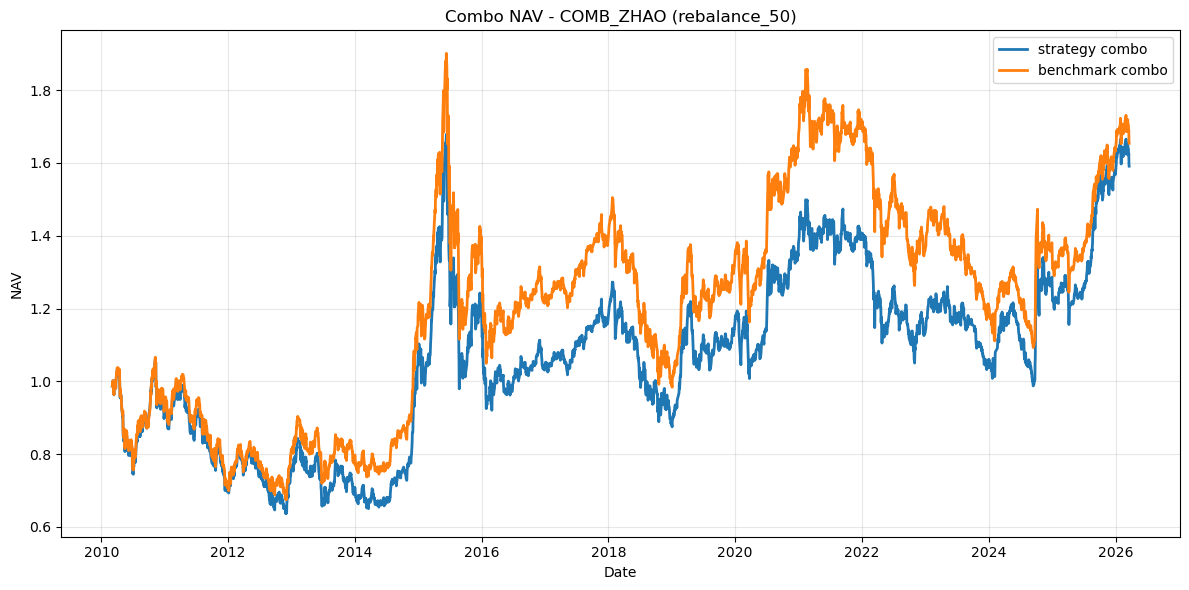

===== Cell 51 验证：五轨组合净值图已保存 =====
保存路径：Result\3_mw50.10_COMB_ZHAO\strategy_rebalance_50_2m\COMB_ZHAO_rebalance_50_combo_nav.png


In [123]:
# Cell 59：画五轨组合净值曲线

# 输入变量：
#   strategy_combo_nav
#   benchmark_combo_nav
#   STRAT_OUTPUT_DIR
#   FACTOR_COL
#   benchmark_mode
#
# 输出变量：
#   combo_nav_path

combo_nav_path = STRAT_OUTPUT_DIR / f"{FACTOR_COL}_{benchmark_mode}_combo_nav.png"

plt.figure(figsize=(12, 6))

plt.plot(
    strategy_combo_nav.index,
    strategy_combo_nav.values,
    label="strategy combo",
    linewidth=2
)

plt.plot(
    benchmark_combo_nav.index,
    benchmark_combo_nav.values,
    label="benchmark combo",
    linewidth=2
)

plt.title(f"Combo NAV - {FACTOR_COL} ({benchmark_mode})")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(combo_nav_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("===== Cell 51 验证：五轨组合净值图已保存 =====")
print(f"保存路径：{combo_nav_path}")

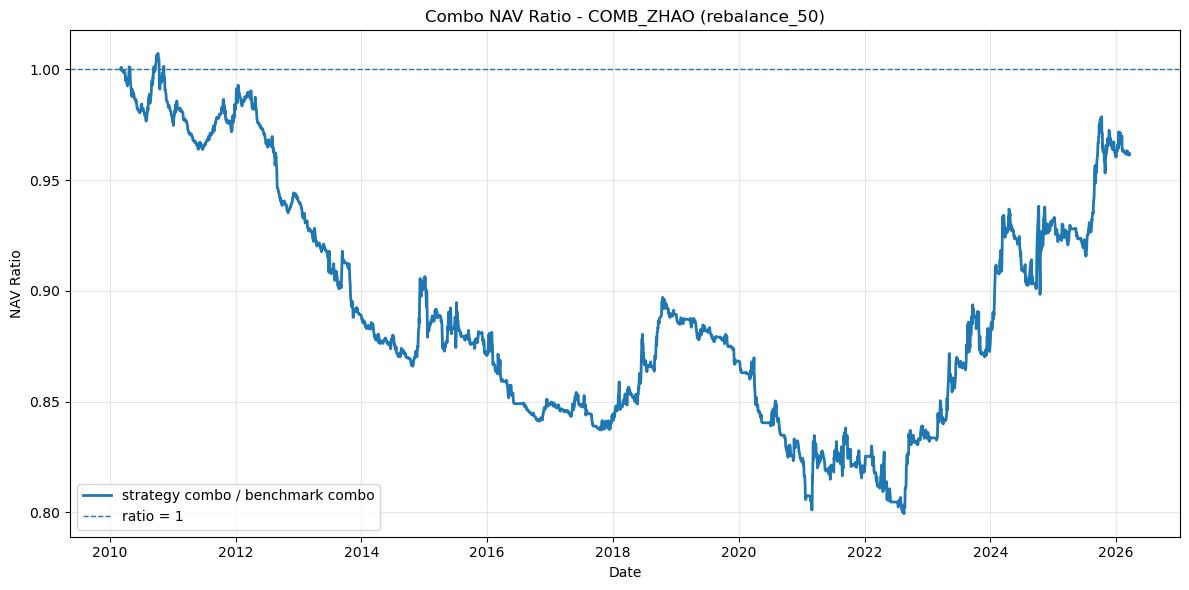

In [124]:
# Cell 60：画五轨组合 strategy_nav / benchmark_nav 比值曲线

# 输入变量：
#   strategy_combo_nav
#   benchmark_combo_nav
#   STRAT_OUTPUT_DIR
#   FACTOR_COL
#   benchmark_mode
#
# 输出变量：
#   combo_nav_ratio_path
#   combo_nav_ratio

combo_nav_ratio_path = STRAT_OUTPUT_DIR / f"{FACTOR_COL}_{benchmark_mode}_combo_nav_ratio.png"

combo_ratio_df = pd.concat(
    [strategy_combo_nav, benchmark_combo_nav],
    axis=1,
    join="inner"
).sort_index(ascending=True)

combo_ratio_df.columns = ["strategy_combo_nav", "benchmark_combo_nav"]

assert len(combo_ratio_df) > 0, "五轨组合净值对齐后为空，请检查 strategy_combo_nav / benchmark_combo_nav"
assert (combo_ratio_df["benchmark_combo_nav"] != 0).all(), "benchmark_combo_nav 存在 0，无法计算比值"

combo_nav_ratio = (
    combo_ratio_df["strategy_combo_nav"] / combo_ratio_df["benchmark_combo_nav"]
).copy()

combo_nav_ratio.name = "combo_nav_ratio"

plt.figure(figsize=(12, 6))

plt.plot(
    combo_nav_ratio.index,
    combo_nav_ratio.values,
    label="strategy combo / benchmark combo",
    linewidth=2
)

plt.axhline(1.0, linestyle="--", linewidth=1, label="ratio = 1")

plt.title(f"Combo NAV Ratio - {FACTOR_COL} ({benchmark_mode})")
plt.xlabel("Date")
plt.ylabel("NAV Ratio")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(combo_nav_ratio_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

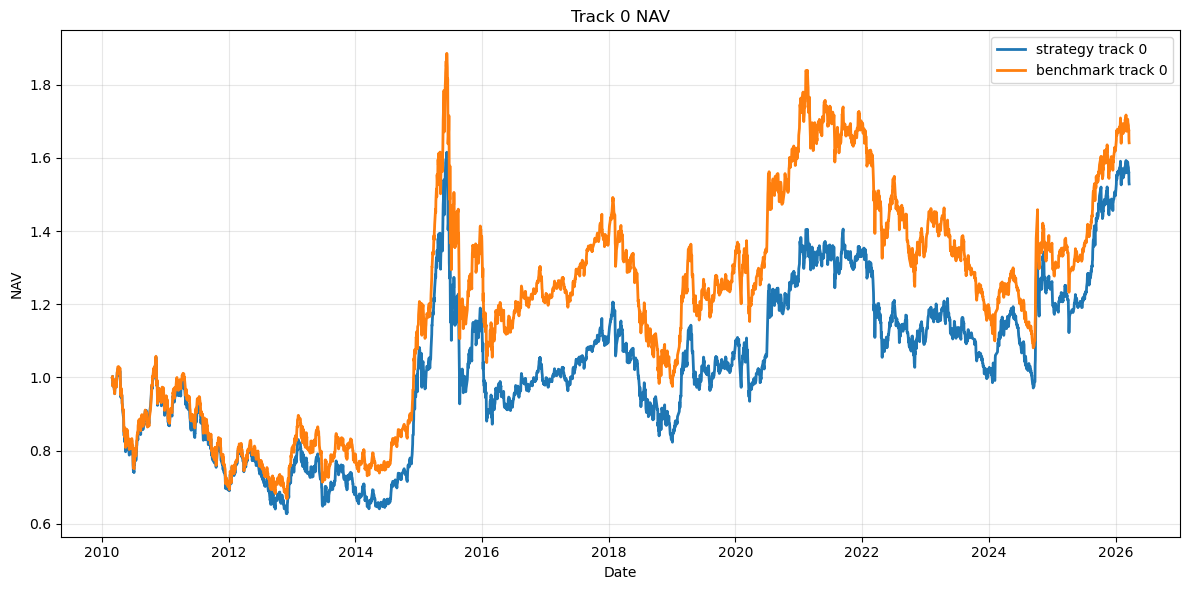

track 0 图片已保存到：Result\3_mw50.10_COMB_ZHAO\strategy_rebalance_50_2m\track_0_nav.png


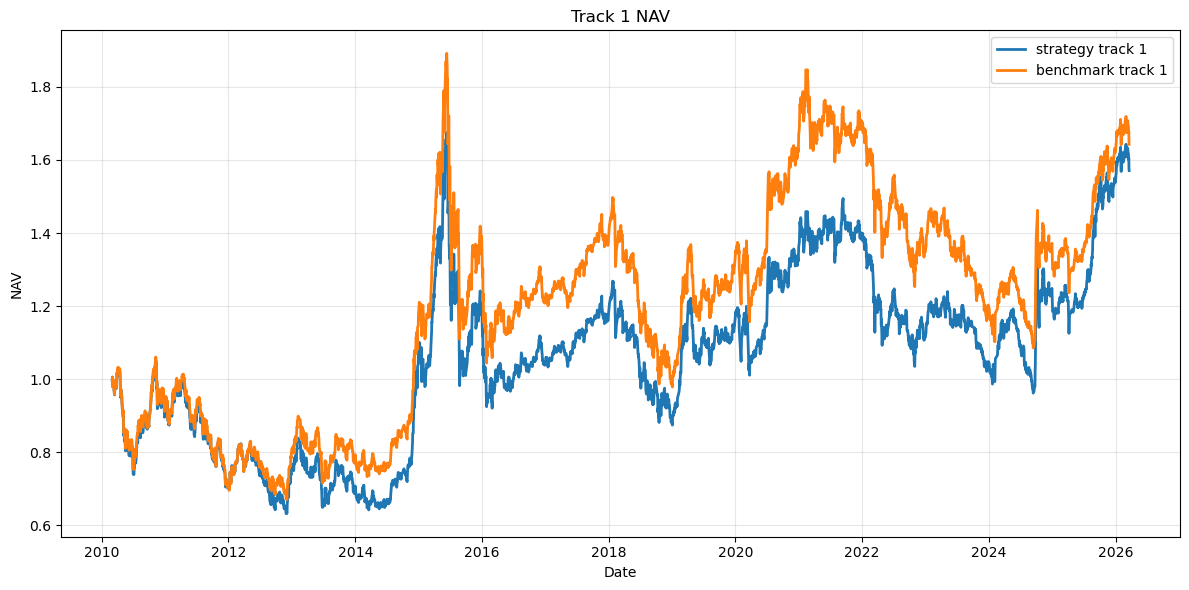

track 1 图片已保存到：Result\3_mw50.10_COMB_ZHAO\strategy_rebalance_50_2m\track_1_nav.png


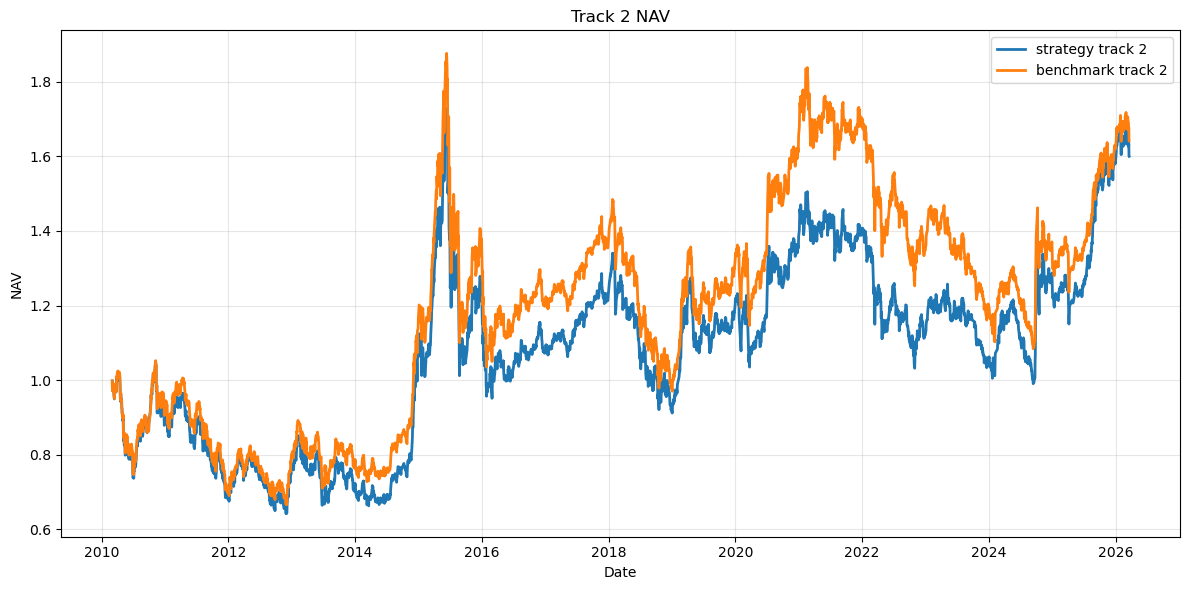

track 2 图片已保存到：Result\3_mw50.10_COMB_ZHAO\strategy_rebalance_50_2m\track_2_nav.png


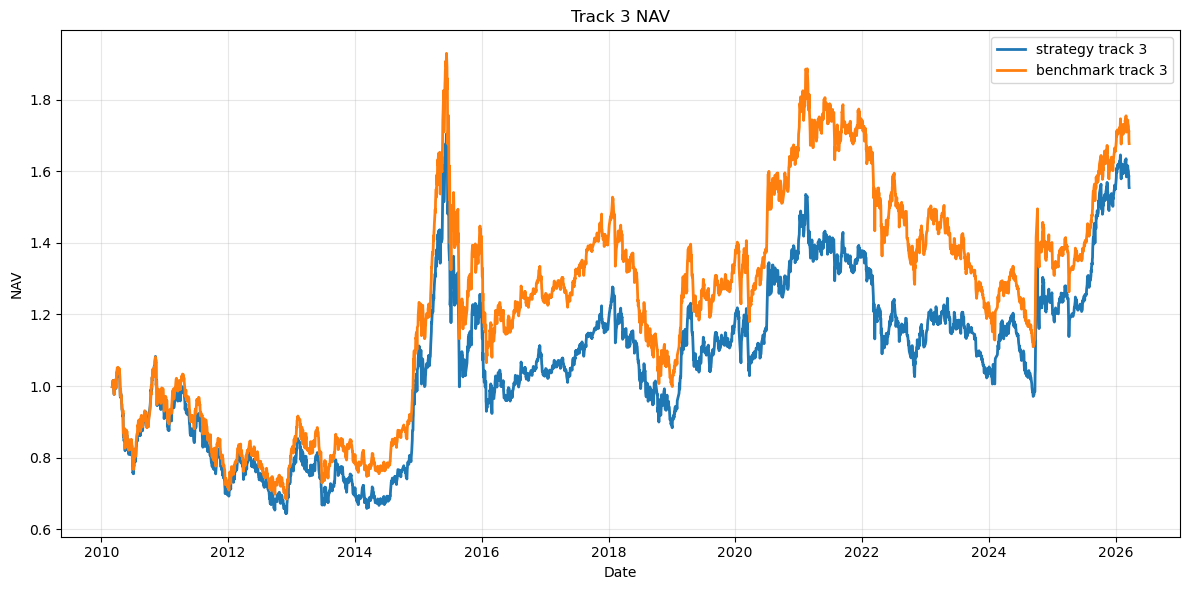

track 3 图片已保存到：Result\3_mw50.10_COMB_ZHAO\strategy_rebalance_50_2m\track_3_nav.png


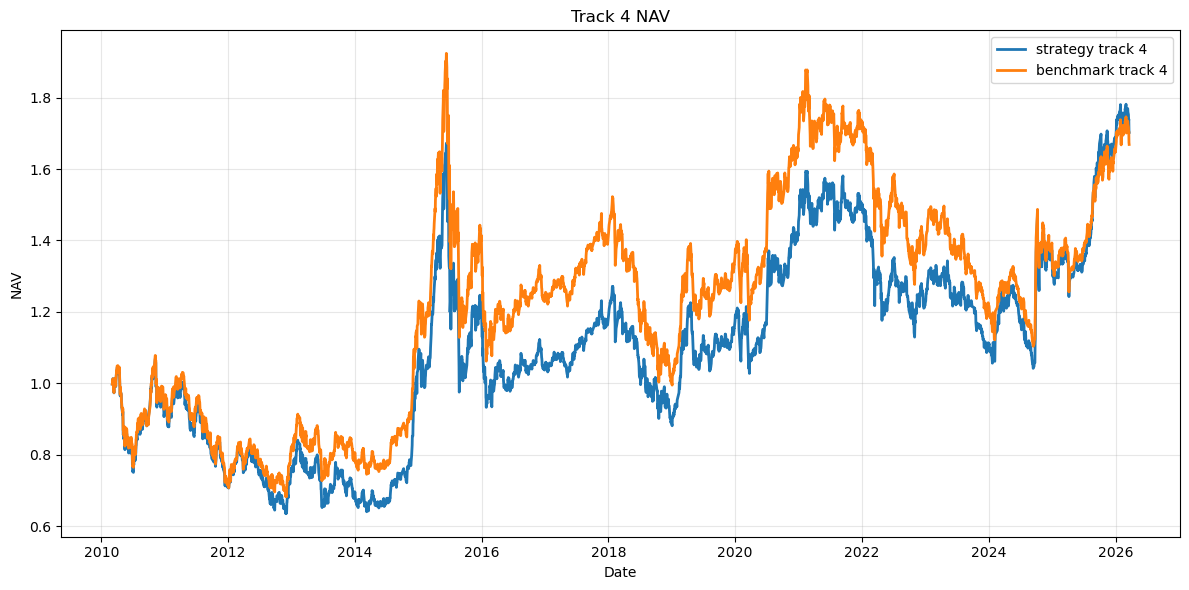

track 4 图片已保存到：Result\3_mw50.10_COMB_ZHAO\strategy_rebalance_50_2m\track_4_nav.png


In [125]:
# Cell 61：画五个轨道各自的净值曲线

# 输入变量：
#   strategy_track_nav_dict
#   benchmark_track_nav_dict
#   track_list
#   STRAT_OUTPUT_DIR
#
# 输出变量：
#   五张图片文件

for track_id in track_list:
    strategy_track_nav = strategy_track_nav_dict[track_id]
    benchmark_track_nav = benchmark_track_nav_dict[track_id]

    track_nav_path = STRAT_OUTPUT_DIR / f"track_{track_id}_nav.png"

    plt.figure(figsize=(12, 6))

    plt.plot(
        strategy_track_nav.index,
        strategy_track_nav.values,
        label=f"strategy track {track_id}",
        linewidth=2
    )

    plt.plot(
        benchmark_track_nav.index,
        benchmark_track_nav.values,
        label=f"benchmark track {track_id}",
        linewidth=2
    )

    plt.title(f"Track {track_id} NAV")
    plt.xlabel("Date")
    plt.ylabel("NAV")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(track_nav_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"track {track_id} 图片已保存到：{track_nav_path}")

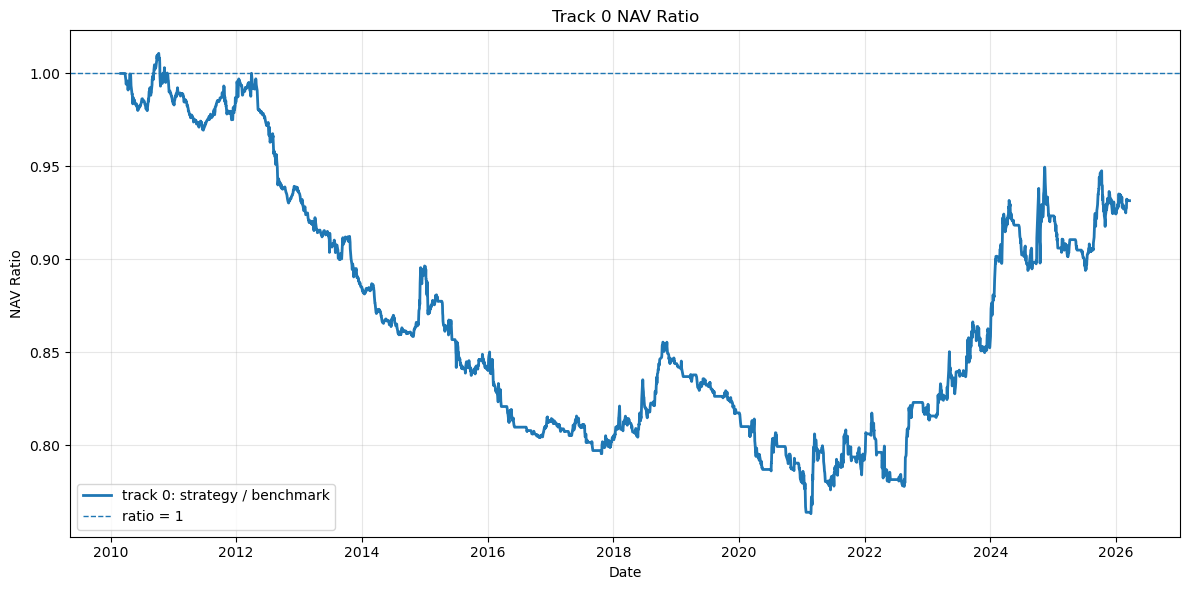

track 0 净值比值图已保存到：Result\3_mw50.10_COMB_ZHAO\strategy_rebalance_50_2m\track_0_nav_ratio.png


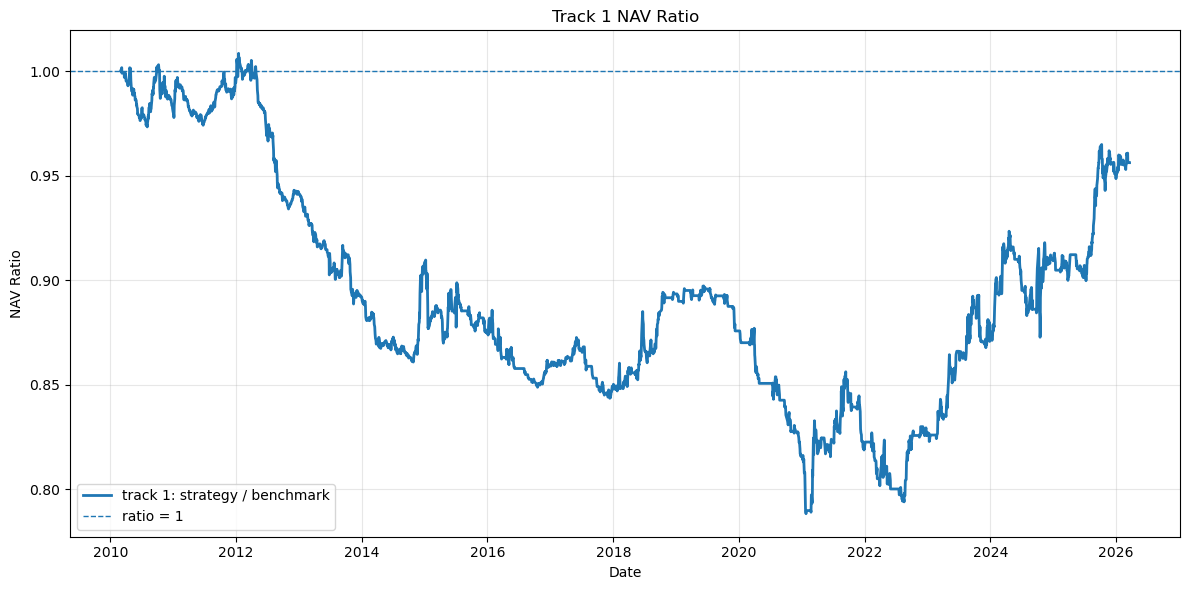

track 1 净值比值图已保存到：Result\3_mw50.10_COMB_ZHAO\strategy_rebalance_50_2m\track_1_nav_ratio.png


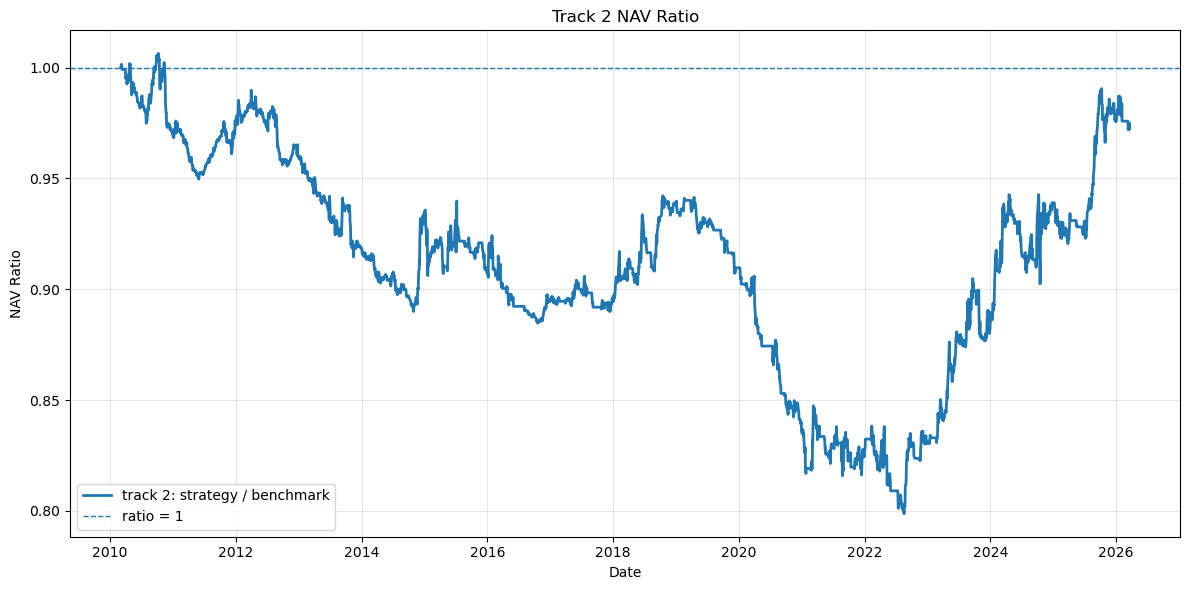

track 2 净值比值图已保存到：Result\3_mw50.10_COMB_ZHAO\strategy_rebalance_50_2m\track_2_nav_ratio.png


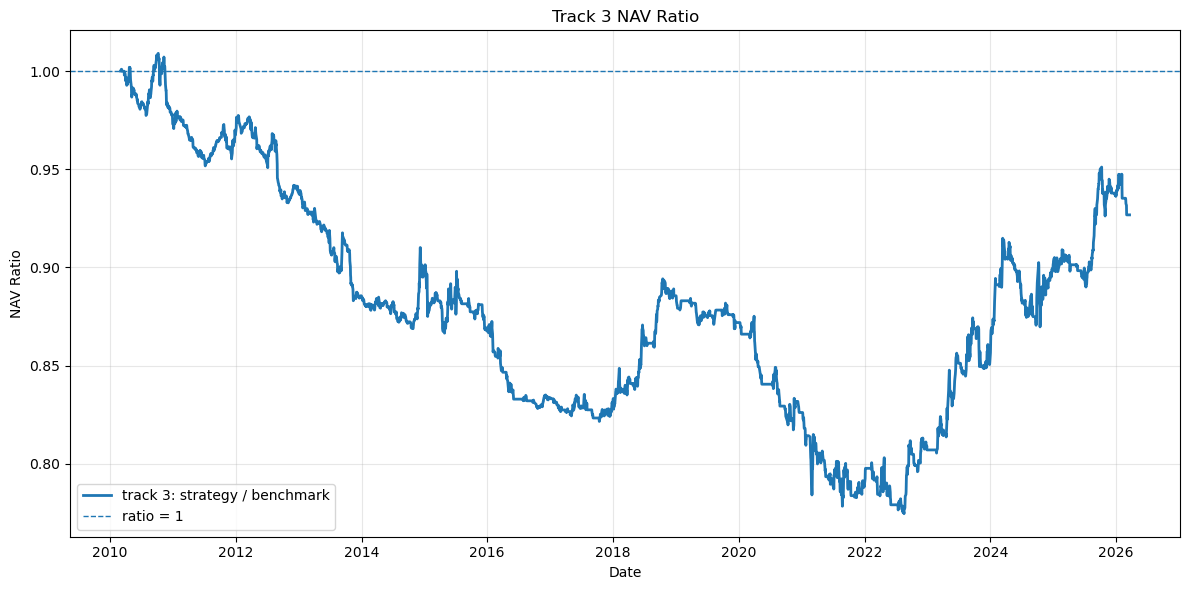

track 3 净值比值图已保存到：Result\3_mw50.10_COMB_ZHAO\strategy_rebalance_50_2m\track_3_nav_ratio.png


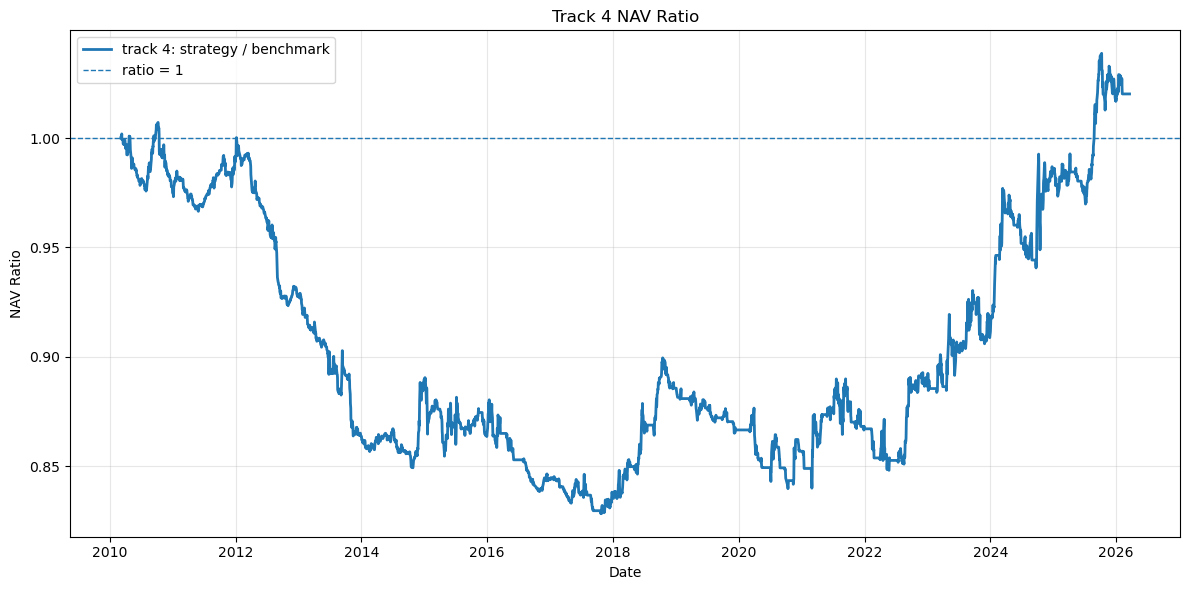

track 4 净值比值图已保存到：Result\3_mw50.10_COMB_ZHAO\strategy_rebalance_50_2m\track_4_nav_ratio.png


In [126]:
# Cell 62：画五个轨道各自的 strategy_nav / benchmark_nav 比值曲线

# 输入变量：
#   strategy_track_nav_dict
#   benchmark_track_nav_dict
#   track_list
#   STRAT_OUTPUT_DIR
#
# 输出变量：
#   五张图片文件

for track_id in track_list:
    strategy_track_nav = strategy_track_nav_dict[track_id]
    benchmark_track_nav = benchmark_track_nav_dict[track_id]

    track_ratio_df = pd.concat(
        [strategy_track_nav, benchmark_track_nav],
        axis=1,
        join="inner"
    ).sort_index(ascending=True)

    track_ratio_df.columns = ["strategy_nav", "benchmark_nav"]

    assert len(track_ratio_df) > 0, f"track {track_id} 对齐后为空，请检查净值序列"
    assert (track_ratio_df["benchmark_nav"] != 0).all(), \
        f"track {track_id} 的 benchmark_nav 存在 0，无法计算比值"

    track_nav_ratio = (
        track_ratio_df["strategy_nav"] / track_ratio_df["benchmark_nav"]
    ).copy()

    track_nav_ratio.name = f"track_{track_id}_nav_ratio"

    track_nav_ratio_path = STRAT_OUTPUT_DIR / f"track_{track_id}_nav_ratio.png"

    plt.figure(figsize=(12, 6))

    plt.plot(
        track_nav_ratio.index,
        track_nav_ratio.values,
        label=f"track {track_id}: strategy / benchmark",
        linewidth=2
    )

    plt.axhline(1.0, linestyle="--", linewidth=1, label="ratio = 1")

    plt.title(f"Track {track_id} NAV Ratio")
    plt.xlabel("Date")
    plt.ylabel("NAV Ratio")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(track_nav_ratio_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"track {track_id} 净值比值图已保存到：{track_nav_ratio_path}")